# IL-2 receptor expression in early human embryogenesis

Dataset: *A single-cell transcriptome atlas of human early embryogenesis* (GEO [GSE157329](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE157329)).
See `data/README.md` for download instructions.

In [ ]:
# Imports directs
import gc
import gzip
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Imports spécifiques
from scipy.io import mmread
from scipy.sparse import csc_matrix
from scipy.stats import f_oneway, ttest_ind
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import umap

# Import de la bibliothèque de fonctions (dossier src/)
import sys
sys.path.append("../src")
import bibli_immuno_ia
from bibli_immuno_ia import import_data
from bibli_immuno_ia import QC_violin
from bibli_immuno_ia import filter_cells 
from bibli_immuno_ia import normalize
from bibli_immuno_ia import apply_PCA , apply_umap
from bibli_immuno_ia import cluster_kmeans
from bibli_immuno_ia import plot_2D_projection
from bibli_immuno_ia import plot_umap
from bibli_immuno_ia import plot_umap_with_annotations
from bibli_immuno_ia import plot_umap_cluster_labels
from bibli_immuno_ia import plot_gene_umap
from bibli_immuno_ia import plot_violin
from bibli_immuno_ia import plot_violin_with_significance 
from bibli_immuno_ia import annotate_clusters
from bibli_immuno_ia import plot_expression_heatmap
from bibli_immuno_ia import t_test_gene_expression_with_pvalues
from bibli_immuno_ia import mann_whitney_gene_expression 

genes_of_interest = ["IL2RG", "IL2RA", "IL2RB"]  # Liste des gènes à tester

# Analyse du premier jeu de données : A single-cell transcriptome atlas of human early embryogenesis 

### Import et arrangement des données 

Ici, on redefinie la fonction laod data en raison de la spécificité de ce jeu. En effet, ce jeu contient un header et donc un nom pour chaque colonne, 
or la majorité des jeu ne contiennent pas de header et donc nous avioins crée la fonction en raison de ce paramètres.

In [2]:
# dire la specificité du jeu avec le nom des colonnes 
def load_data(matrix_path, genes_path, barcodes_path):
    """ Load sparse expression matrix and metadata (genes & barcodes). """
    
    # Load sparse matrix
    with gzip.open(matrix_path, 'rb') as f:
        matrix = mmread(f).tocsc()
    
    # Load genes and barcodes
    genes = pd.read_csv(genes_path, sep="\t")["gene_short_name"].values
    barcodes = pd.read_csv(barcodes_path, sep="\t")["cell_id"].values

    # Create DataFrame
    df = pd.DataFrame.sparse.from_spmatrix(matrix, index=genes, columns=barcodes)
    
    print(f"Data loaded: {df.shape}")
    return df, genes, barcodes, matrix

In [3]:
matrix_path = "../data/embryo/GSE157329_raw_counts.mtx.gz"
barcodes_path = "../data/embryo/GSE157329_cell_annotate.txt.gz"
genes_path = "../data/embryo/GSE157329_gene_annotate.txt.gz"      

df3,genes,cells,matrix = load_data(matrix_path, genes_path, barcodes_path)

Data loaded: (32351, 185140)


###  On effectue une operation de QC avant nettoyage de données 

Comptage des gènes exprimés par cellule...
Calcul du nombre de gènes exprimés par cellule terminé.
Calcul du nombre d'UMI par cellule...
Calcul du nombre d'UMI par cellule terminé.
Calcul du pourcentage de gènes mitochondriaux...
Calcul du pourcentage de gènes mitochondriaux terminé.


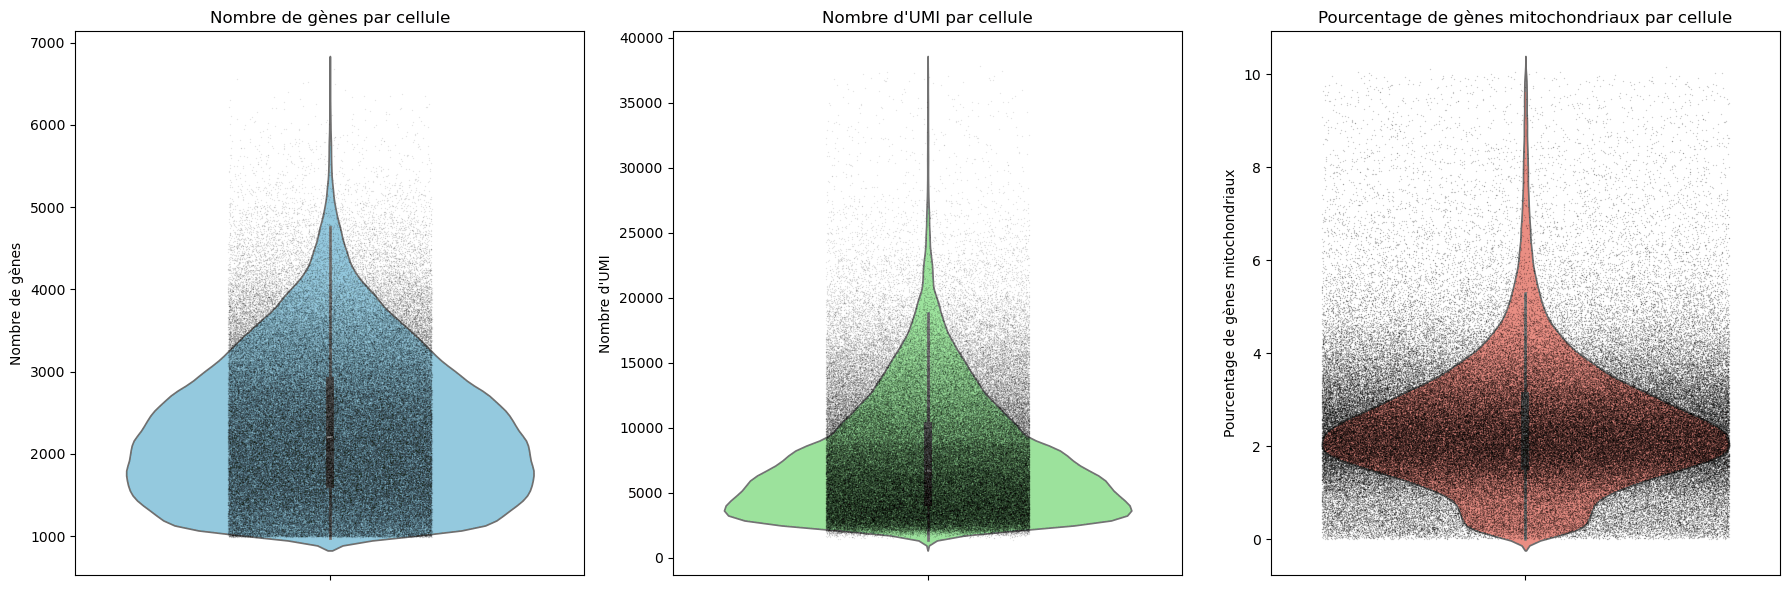

In [5]:
genes_per_cell, umi_per_cell, mitochondrial_percent = QC_violin(df3, genes)


### On filtre les données 

In [7]:
df3_filtered = filter_cells(df3, genes, min_gene =200, max_gene = 2000, max_mito = 10)

Nombre de cellules avant filtrage : 185140
Nombre de cellules après filtrage : 65063


### On effectue l'operation de QC apres nettoyage 

Comptage des gènes exprimés par cellule...
Calcul du nombre de gènes exprimés par cellule terminé.
Calcul du nombre d'UMI par cellule...
Calcul du nombre d'UMI par cellule terminé.
Calcul du pourcentage de gènes mitochondriaux...
Calcul du pourcentage de gènes mitochondriaux terminé.


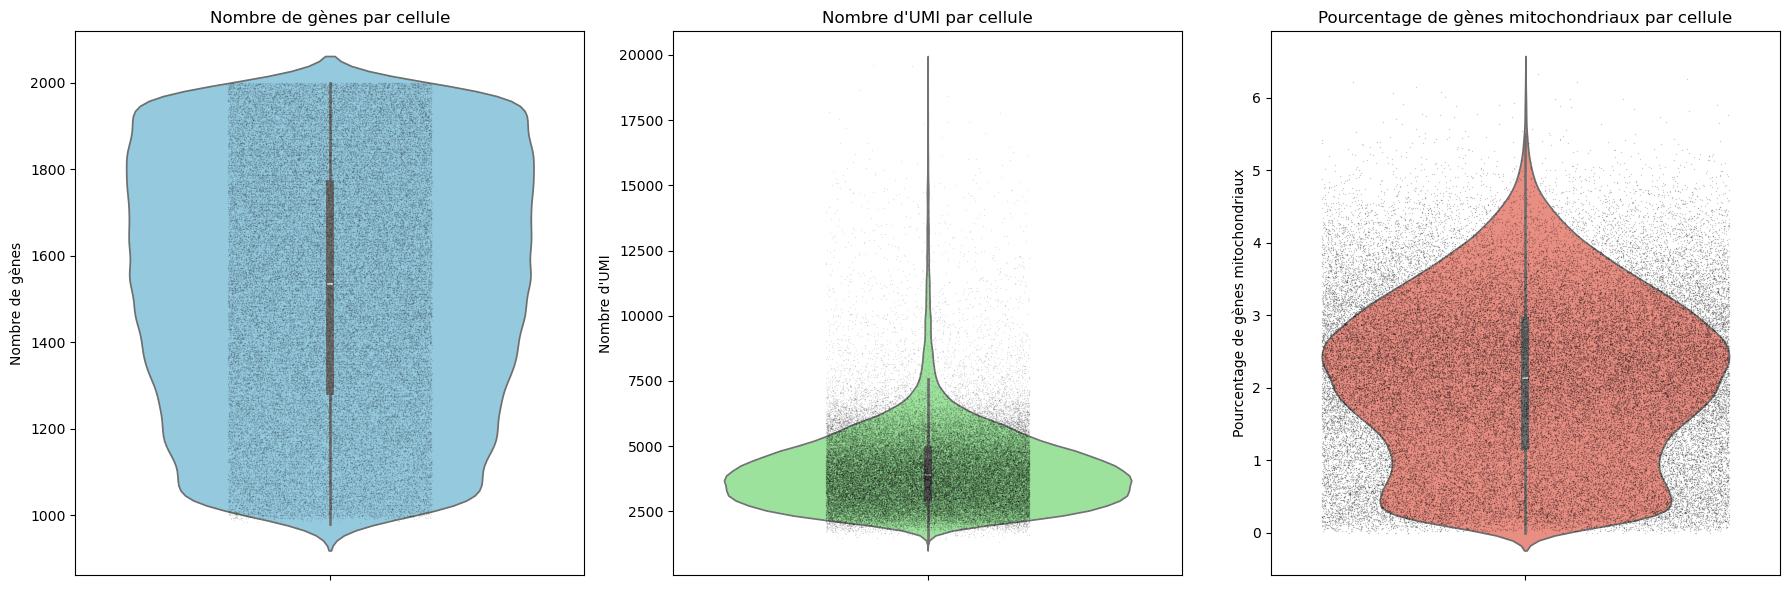

In [9]:
genes_per_cell, umi_per_cell, mitochondrial_percent = QC_violin(df3_filtered, genes)

### On normalise les données 

In [11]:
df3_normalized = normalize(df3_filtered)

In [12]:
print (df3_normalized.sum(axis=0).head(10))

h0_48     10000.0
h0_125    10000.0
h0_229    10000.0
h0_271    10000.0
h0_372    10000.0
h0_407    10000.0
h0_480    10000.0
h0_499    10000.0
h0_514    10000.0
h0_652    10000.0
dtype: Sparse[float64, 0.0]


### On effectue l'ACP 

In [14]:
pca_result3 =  apply_PCA(df3_normalized, n_components=20)

On applique la log transformation...
Log transformation complète.
Début de l'ACP
PCA complète, dimension = (65063, 20)


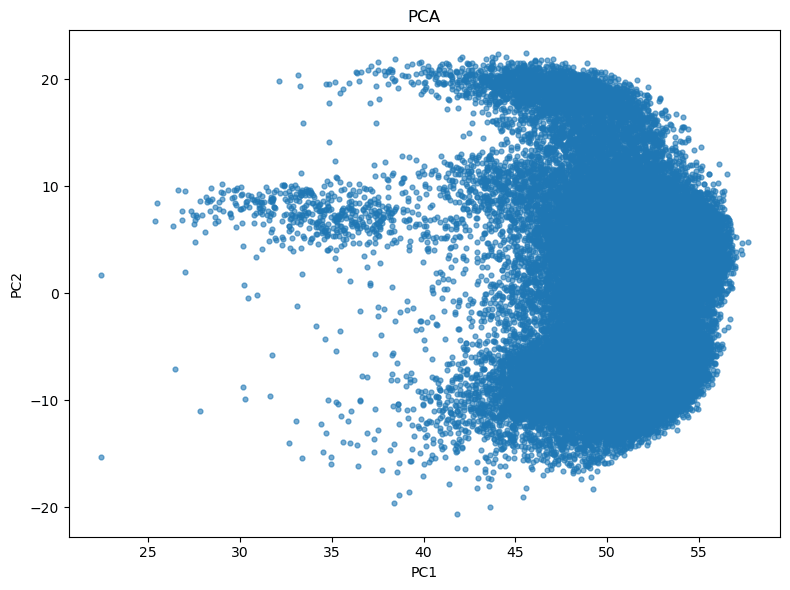

In [15]:
plot_2D_projection(pca_result3[:, :2], title="PCA", x_label="PC1", y_label="PC2")



### On effectue l'UMAP 

In [17]:
umap3 = apply_umap(pca_result3, n_neighbors=15, min_dist=0.4)

UMAP done: (65063, 2)


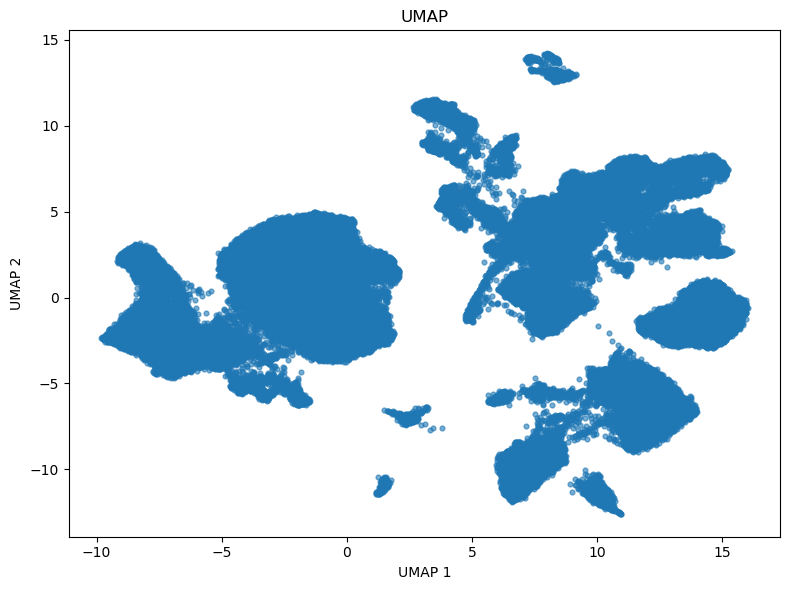

In [18]:
plot_2D_projection(umap3, title="UMAP", x_label="UMAP 1", y_label="UMAP 2")

## Etape de Clustering avec KMeans 

In [22]:
clusters3 = cluster_kmeans(umap3, n_clusters=50)

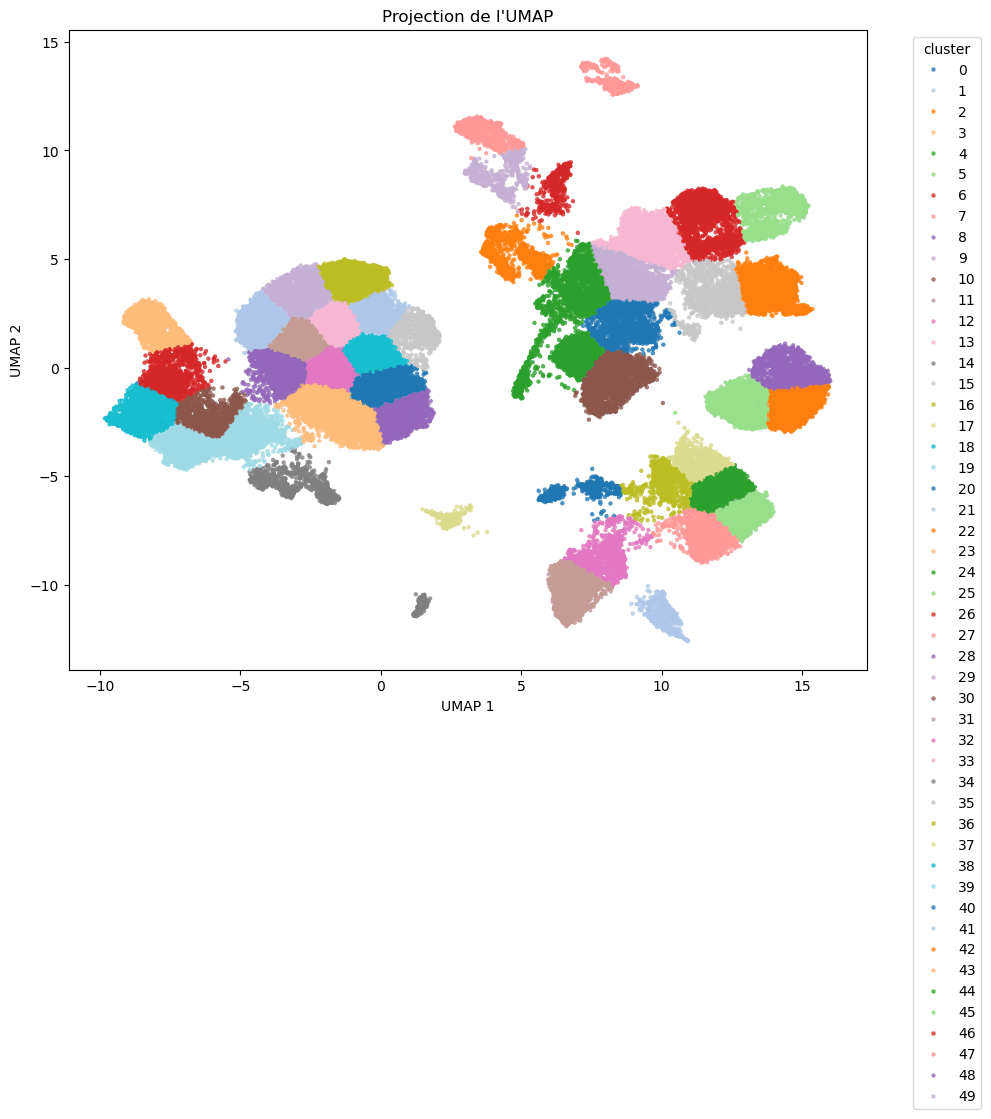

In [23]:
plot_umap(umap3, clusters3)

## Annotation des clusters 


🔎 Cluster 0 :
IL2RA        : 0.00
IL2RB        : 0.00
IL2RG        : 0.00
CD3E         : 0.00
CD4          : 0.01
CD8A         : 0.00
CD19         : 0.00
MS4A1        : 0.00
CD14         : 0.06
CD16         : ❌ Non trouvé
NCAM1        : 0.21
FCGR3A       : 0.03
IL7R         : 0.01
FOXP3        : 0.00
TNFRSF4      : 0.00
CTLA4        : 0.00
CXCR5        : 0.00
ICOS         : 0.00
CCR7         : 0.00
SELL         : 0.00
PRF1         : 0.00
GZMB         : 0.00
XBP1         : 0.32
MZB1         : 0.01
CD38         : 0.00
CLEC9A       : 0.00
CD209        : 0.00
ITGAX        : 0.00
CD68         : 0.03
CD163        : 0.02
MRC1         : 0.02
CD45         : ❌ Non trouvé

🔎 Cluster 1 :
IL2RA        : 0.00
IL2RB        : 0.00
IL2RG        : 0.01
CD3E         : 0.00
CD4          : 0.03
CD8A         : 0.00
CD19         : 0.00
MS4A1        : 0.00
CD14         : 0.02
CD16         : ❌ Non trouvé
NCAM1        : 0.62
FCGR3A       : 0.00
IL7R         : 0.00
FOXP3        : 0.00
TNFRSF4      : 0.00
CTLA4 

,Cluster,Cell Type
0,0,Autres/Indeterminé
1,1,Autres/Indeterminé
2,2,Autres/Indeterminé
3,3,Autres/Indeterminé
4,4,Autres/Indeterminé
5,5,Autres/Indeterminé
6,6,Autres/Indeterminé
7,7,Autres/Indeterminé
8,8,Autres/Indeterminé
9,9,Monocytes classiques


Cell Type
Autres/Indeterminé      60281
Monocytes classiques     2627
NK cells                 2155
Name: count, dtype: int64

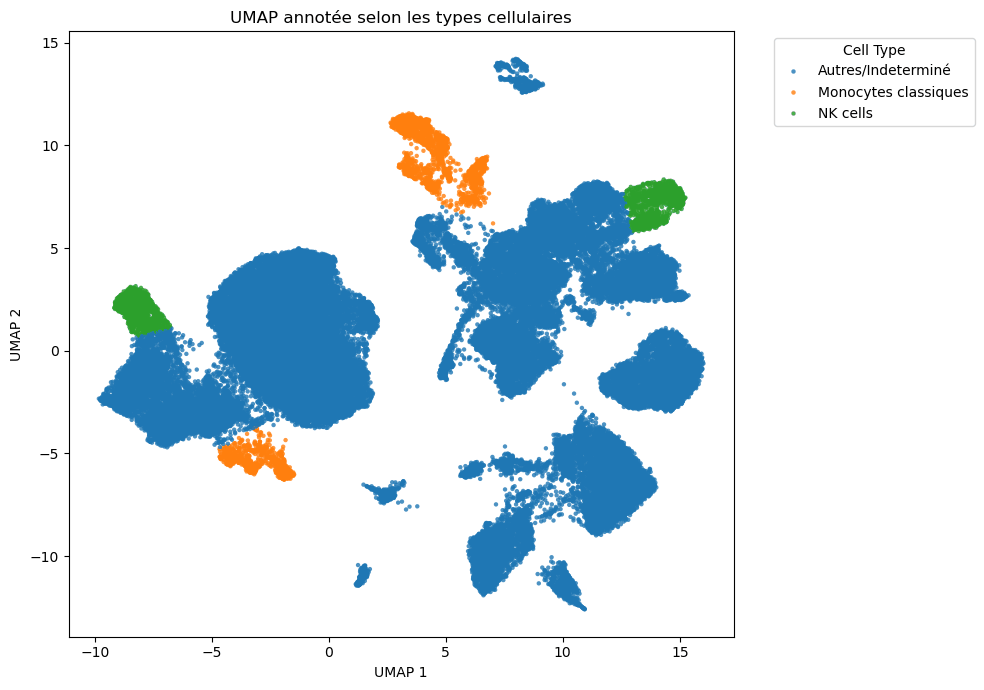

In [25]:
annotation_df, cell_type_per_cell, cluster_annotation = annotate_clusters(df3_normalized, clusters3, umap3)

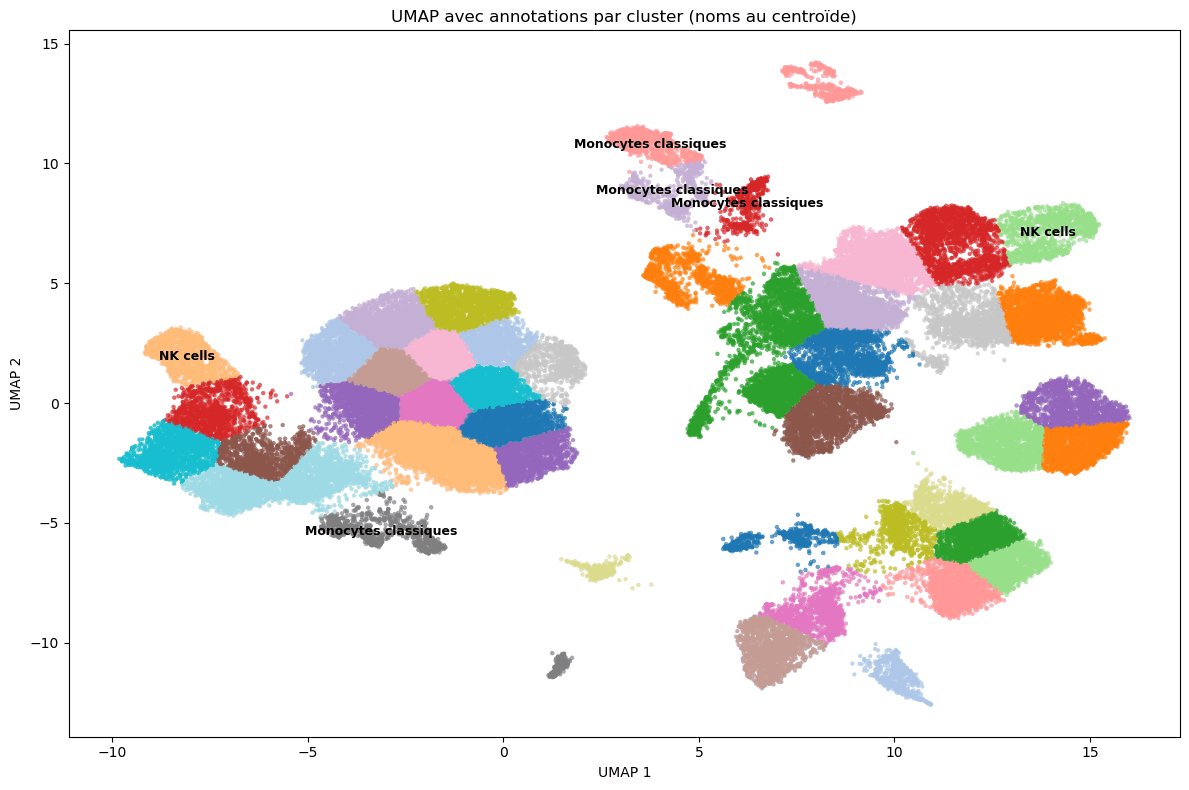

In [26]:
plot_umap_cluster_labels(umap3, clusters3, cluster_annotation)

## Visualisation de l'expression des gènes sur la UMAP 

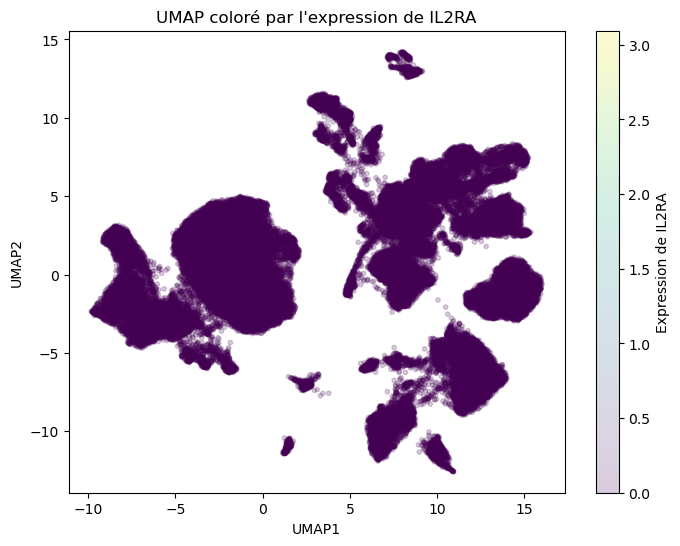

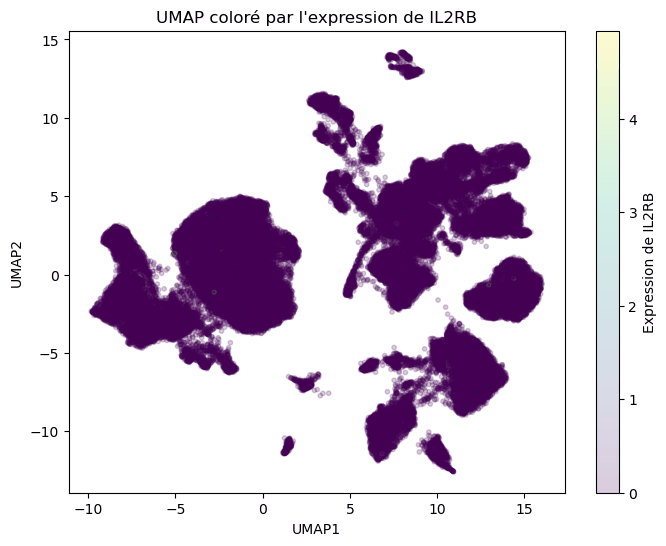

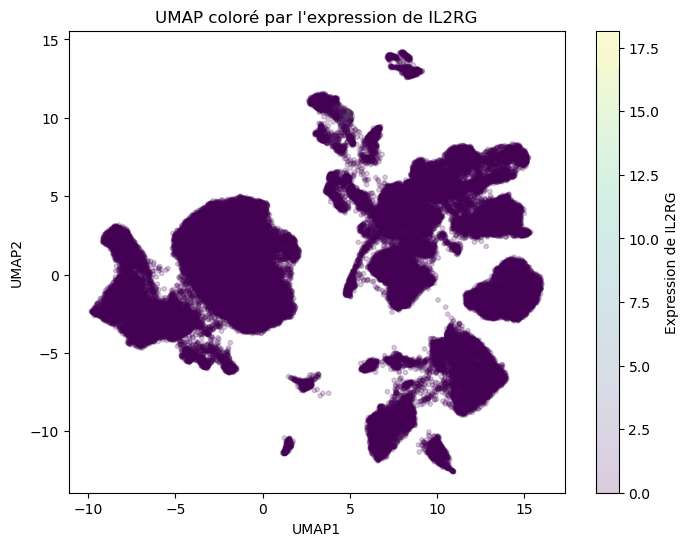

In [28]:
umap_coords = pd.DataFrame(umap3, columns=["UMAP1", "UMAP2"])

plot_gene_umap(umap_coords, df3_normalized, 'IL2RA')
plot_gene_umap(umap_coords, df3_normalized, 'IL2RB')
plot_gene_umap(umap_coords, df3_normalized, 'IL2RG')


## Premiere visualisation des Violin Plots 

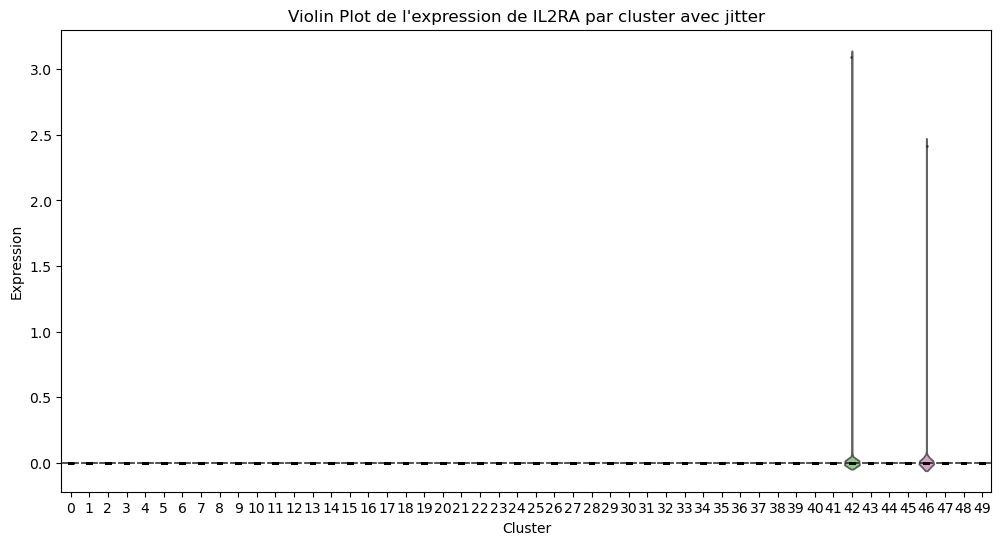

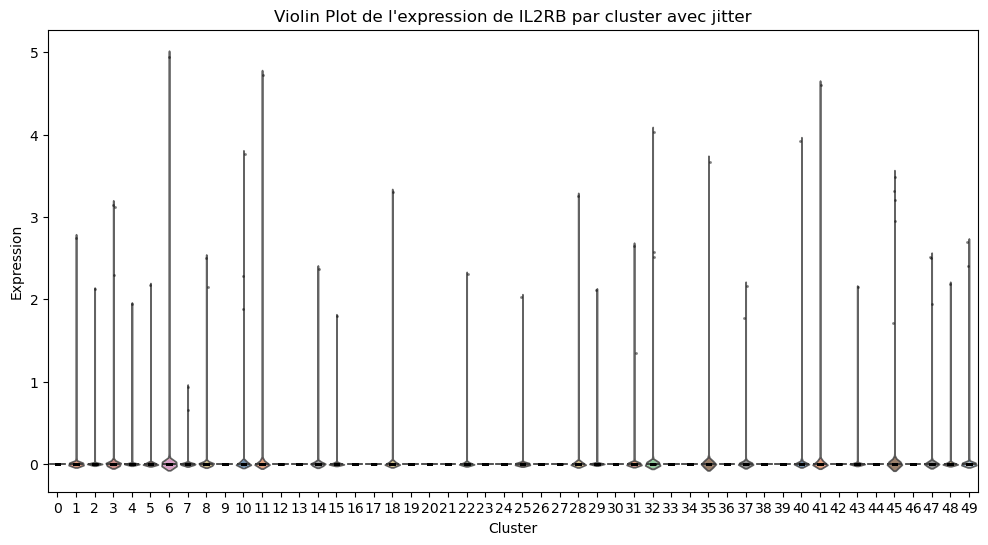

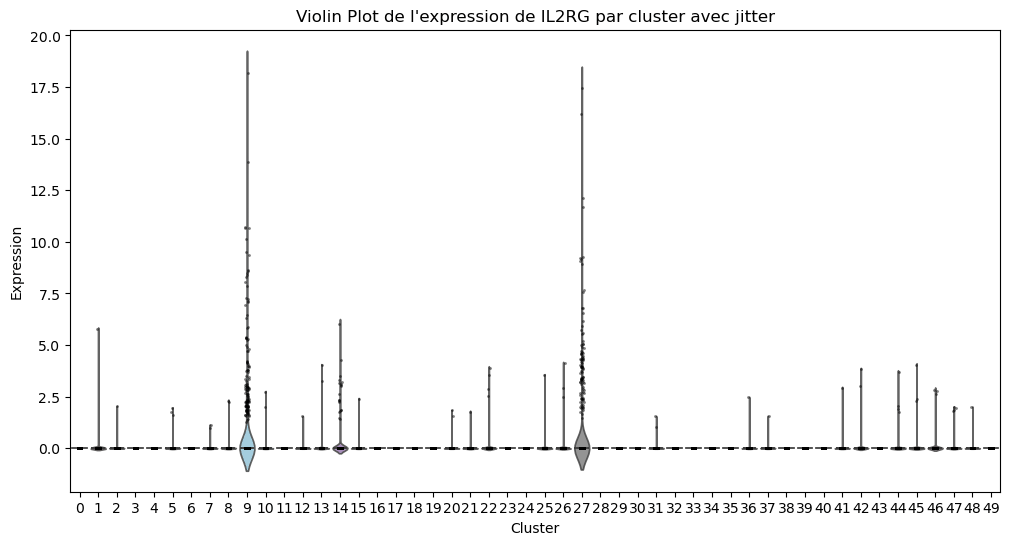

In [30]:
plot_violin(df3_normalized, ["IL2RA", "IL2RB", "IL2RG"], clusters3)

## On effectue les Test statistiques 

### T-test 

In [33]:
df3_cluster = pd.Series(clusters3, index= df3_normalized.columns)
print(type(df3_cluster))
genes_of_interest = ["IL2RG", "IL2RA", "IL2RB"] 

<class 'pandas.core.series.Series'>


In [34]:
p_values_df_t_test = t_test_gene_expression_with_pvalues(df3_normalized, df3_cluster, genes_of_interest)

In [35]:
print(p_values_df_t_test)

Gène        IL2RA         IL2RB         IL2RG
Cluster                                      
0        0.160450  2.250850e-10  3.049559e-45
1        0.160450  7.731296e-01  3.170362e-02
2        0.160450  3.961972e-01  2.420893e-26
3        0.160450  2.738800e-01  3.040463e-45
4        0.160450  4.482480e-01  3.039610e-45
5        0.160450  8.919381e-01  2.315645e-07
6        0.160450  5.372887e-01  3.045656e-45
7        0.160450  5.425446e-01  9.246833e-05
8        0.160450  4.851649e-01  7.019809e-07
9        0.160450  2.250823e-10  3.676113e-21
10       0.160450  3.581958e-01  8.172747e-13
11       0.160450  6.877602e-01  3.041914e-45
12       0.160450  2.250723e-10  5.798933e-18
13       0.160450  2.250481e-10  4.548375e-08
14       0.160450  6.870293e-01  1.297486e-03
15       0.160450  6.470779e-01  5.829712e-14
16       0.160450  2.250813e-10  3.048253e-45
17       0.160450  2.250896e-10  3.051153e-45
18       0.160450  8.434021e-01  3.042758e-45
19       0.160450  2.250661e-10  3

### Mann_whitney 

In [37]:
p_values_df_mann_whitney = mann_whitney_gene_expression(df3_normalized, df3_cluster, genes_of_interest)

In [38]:
print(p_values_df_mann_whitney)

Gène            IL2RA     IL2RB         IL2RG
Cluster                                      
0        8.988904e-01  0.546199  1.241583e-01
1        8.546259e-01  0.763962  7.949474e-02
2        7.934631e-01  0.681842  4.531898e-03
3        8.134717e-01  0.101880  4.327571e-03
4        8.074767e-01  0.790187  3.211841e-03
5        8.370818e-01  0.943711  2.099176e-01
6        8.556502e-01  0.752665  2.779117e-02
7        9.021532e-01  0.004145  8.939681e-01
8        8.397827e-01  0.242745  1.078241e-01
9        8.869403e-01  0.499598  0.000000e+00
10       8.017067e-01  0.159730  1.849140e-02
11       8.241825e-01  0.935036  7.216410e-03
12       8.509957e-01  0.372546  6.816992e-02
13       7.886744e-01  0.203345  9.372516e-03
14       8.765229e-01  0.525463  4.417163e-19
15       8.318068e-01  0.994921  3.007932e-02
16       8.825799e-01  0.483111  7.396538e-02
17       9.234468e-01  0.647896  2.445823e-01
18       8.307475e-01  0.995794  9.741862e-03
19       8.326352e-01  0.315831  1

## Violin Plots avec les étoiles significatives 

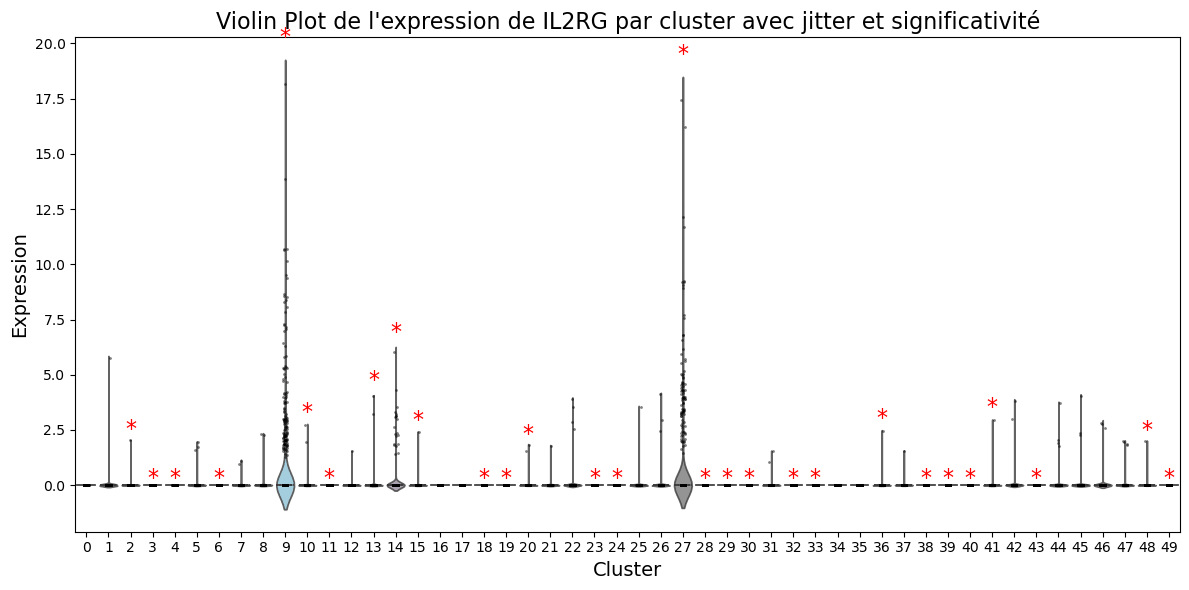

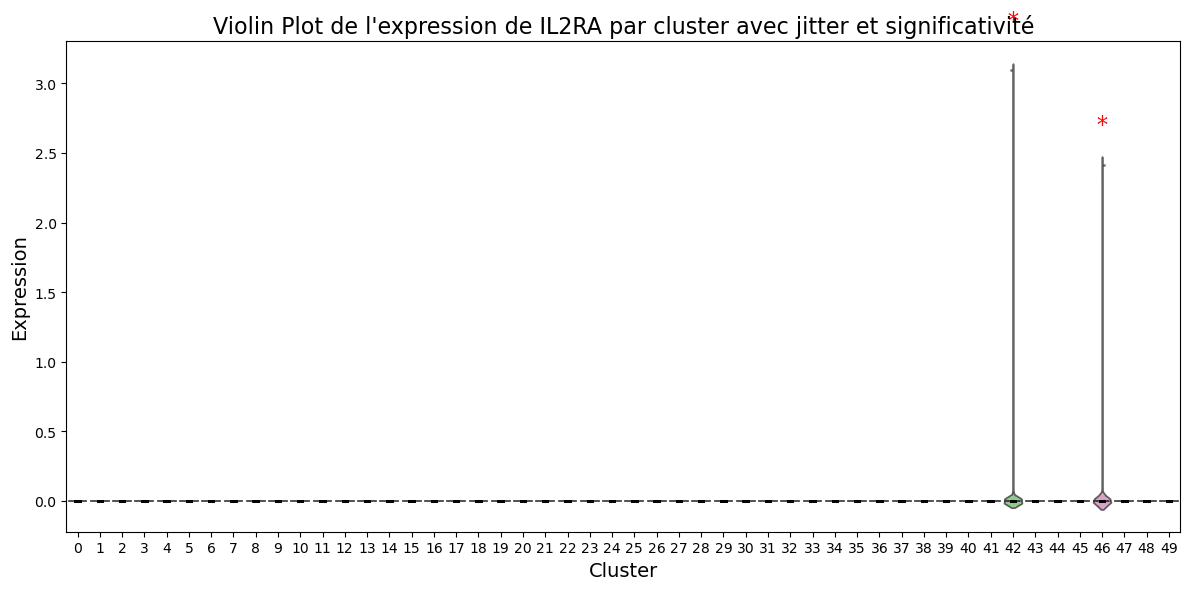

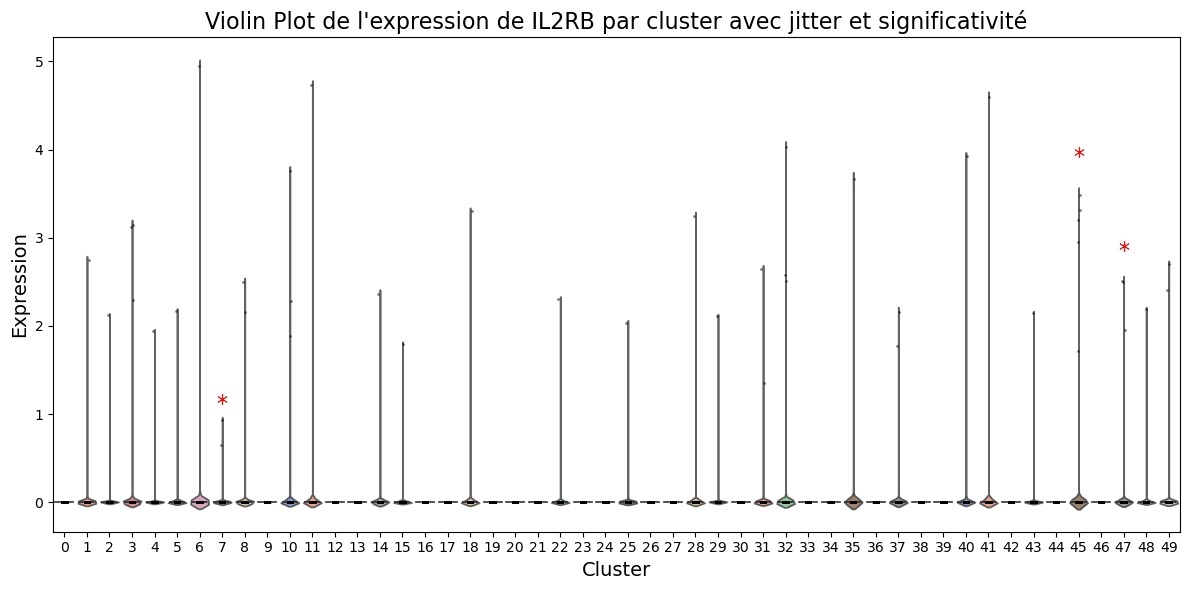

In [40]:
plot_violin_with_significance(df3_normalized, genes_of_interest, clusters3, p_values_df_mann_whitney, threshold=0.05)

# Analyse complémentaire en tenant compte des données sur l'origine tissulaire des cellules 

### Import des données 

In [3]:
def load_data(matrix_path, genes_path, barcodes_path):
    """ Load sparse expression matrix and metadata (genes & barcodes). """
    
    # Load sparse matrix
    with gzip.open(matrix_path, 'rb') as f:
        matrix = mmread(f).tocsc()
    
    # Load genes and barcodes
    genes = pd.read_csv(genes_path, sep="\t")["gene_short_name"].values
    barcodes = pd.read_csv(barcodes_path, sep="\t")["cell_id"].values

    # Create DataFrame
    df = pd.DataFrame.sparse.from_spmatrix(matrix, index=genes, columns=barcodes)
    
    print(f"Data loaded: {df.shape}")
    return df, genes, barcodes, matrix

In [5]:
matrix_path = "../data/embryo/GSE157329_raw_counts.mtx.gz"
barcodes_path = "../data/embryo/GSE157329_cell_annotate.txt.gz"
genes_path = "../data/embryo/GSE157329_gene_annotate.txt.gz"      

df3_tissu,genes,cells,matrix = load_data(matrix_path, genes_path, barcodes_path)

Data loaded: (32351, 185140)


In [6]:
tissus = pd.read_csv(barcodes_path, sep="\t")["developmental system"].values

In [7]:
print (tissus) 

['neural progenitor' 'head mesoderm' 'neural progenitor' ... 'blood' 'PGC'
 'PGC']


In [8]:
import pandas as pd

# Création du DataFrame
df_tissus = pd.DataFrame({'Cellule': cells, 'Tissu': tissus})

# On met les cellules en index
df_tissus.set_index('Cellule', inplace=True)

# Affichage
print(df_tissus.head())


                     Tissu
Cellule                   
h0_1     neural progenitor
h0_2         head mesoderm
h0_3     neural progenitor
h0_4     neural progenitor
h0_5     neural progenitor


In [9]:
print (df_tissus)

                       Tissu
Cellule                     
h0_1       neural progenitor
h0_2           head mesoderm
h0_3       neural progenitor
h0_4       neural progenitor
h0_5       neural progenitor
...                      ...
tv7_21017              blood
tv7_21064              blood
tv7_21472              blood
tv7_7625                 PGC
tv7_10119                PGC

[185140 rows x 1 columns]


#### Controle qualite 

In [11]:
tissus_unique = np.unique(df_tissus)
print(tissus_unique)

['IM' 'PGC' 'blood' 'craniofacial' 'endoderm' 'endothelium' 'epidermis'
 'epithelium' 'fibroblast' 'head mesoderm' 'limb' 'miscellaneous'
 'neural progenitor' 'neuron' 'schwann' 'sensory neuron' 'somatic LPM'
 'somite' 'splanchnic LPM']



Traitement du tissu : IM
Index(['t0_29', 't0_57', 't0_72', 't0_88', 't0_136', 't0_156', 't0_167',
       't0_169', 't0_364', 't0_494',
       ...
       't22_23514', 't22_23789', 'l21_1540', 'l21_2062', 'l21_5767',
       'l21_10696', 'l21_15001', 'l21_16012', 'l21_17256', 'l21_23127'],
      dtype='object', length=1010)
             t0_29  t0_57  t0_72  t0_88  t0_136  t0_156  t0_167  t0_169  \
MIR1302-2HG      0      0      0      0       0       0       0       0   
FAM138A          0      0      0      0       0       0       0       0   
OR4F5            0      0      0      0       0       0       0       0   
AL627309.1       0      0      0      0       0       0       0       0   
AL627309.3       0      0      0      0       0       0       0       0   
...            ...    ...    ...    ...     ...     ...     ...     ...   
AC233755.2       0      0      0      0       0       0       0       0   
AC233755.1       0      0      0      0       0       0       0       0   
A

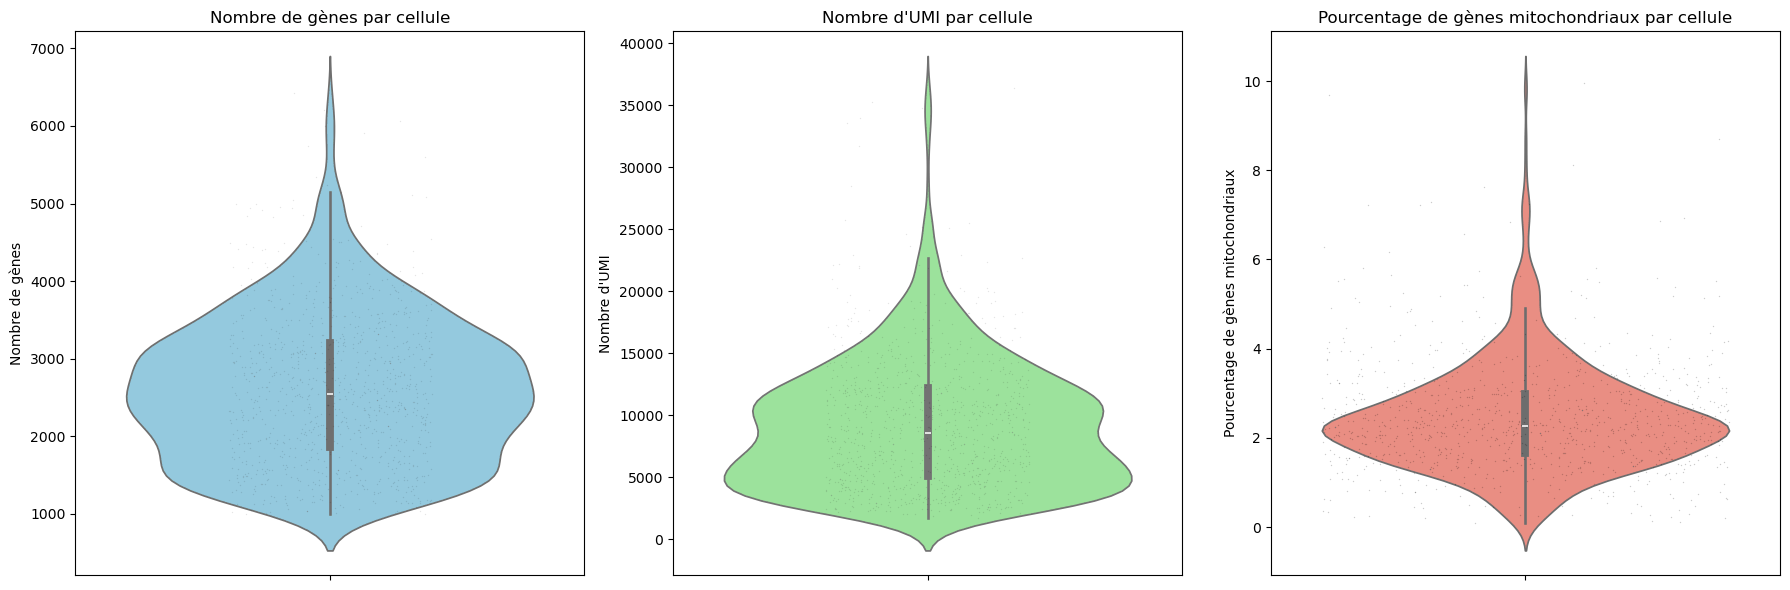


Traitement du tissu : PGC
Index(['t0_5090', 'tv7_2701', 't22_13246', 'tv7_7625', 'tv7_10119'], dtype='object')
             t0_5090  tv7_2701  t22_13246  tv7_7625  tv7_10119
MIR1302-2HG        0         0          0         0          0
FAM138A            0         0          0         0          0
OR4F5              0         0          0         0          0
AL627309.1         0         0          0         0          0
AL627309.3         0         0          0         0          0
...              ...       ...        ...       ...        ...
AC233755.2         0         0          0         0          0
AC233755.1         0         0          0         0          0
AC240274.1         1         0          0         0          0
AC213203.2         0         0          0         0          0
AC213203.1         0         0          0         0          0

[32351 rows x 5 columns]
Comptage des gènes exprimés par cellule...
Calcul du nombre de gènes exprimés par cellule terminé.
Calcul 

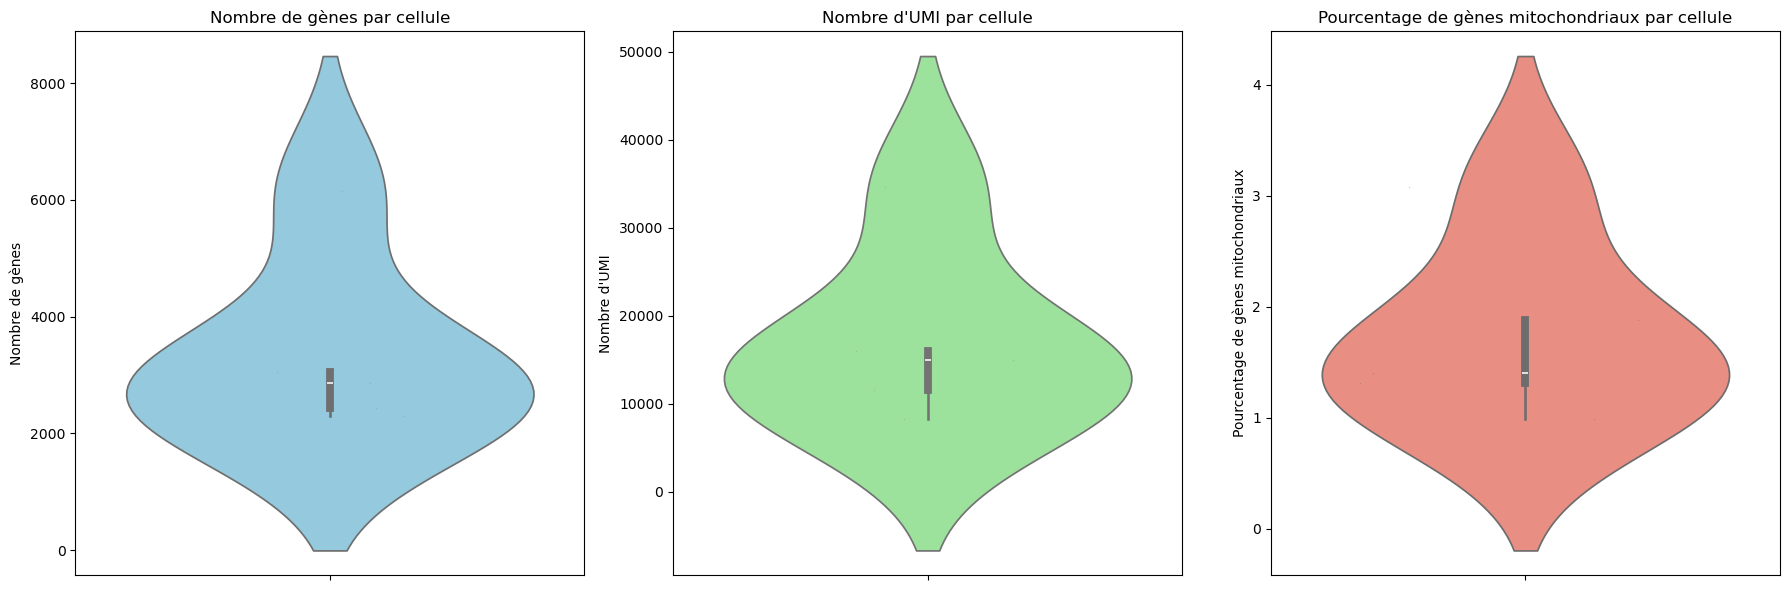


Traitement du tissu : blood
Index(['h0_104', 'h0_136', 'h0_152', 'h0_240', 'h0_373', 'h0_417', 'h0_493',
       'h0_504', 'h0_511', 'h0_596',
       ...
       'tv7_20525', 'tv7_20549', 'tv7_20644', 'tv7_20742', 'tv7_20824',
       'tv7_20857', 'tv7_20881', 'tv7_21017', 'tv7_21064', 'tv7_21472'],
      dtype='object', length=7121)
             h0_104  h0_136  h0_152  h0_240  h0_373  h0_417  h0_493  h0_504  \
MIR1302-2HG       0       0       0       0       0       0       0       0   
FAM138A           0       0       0       0       0       0       0       0   
OR4F5             0       0       0       0       0       0       0       0   
AL627309.1        0       0       0       0       0       0       0       0   
AL627309.3        0       0       0       0       0       0       0       0   
...             ...     ...     ...     ...     ...     ...     ...     ...   
AC233755.2        0       0       0       0       0       0       0       0   
AC233755.1        0       0       

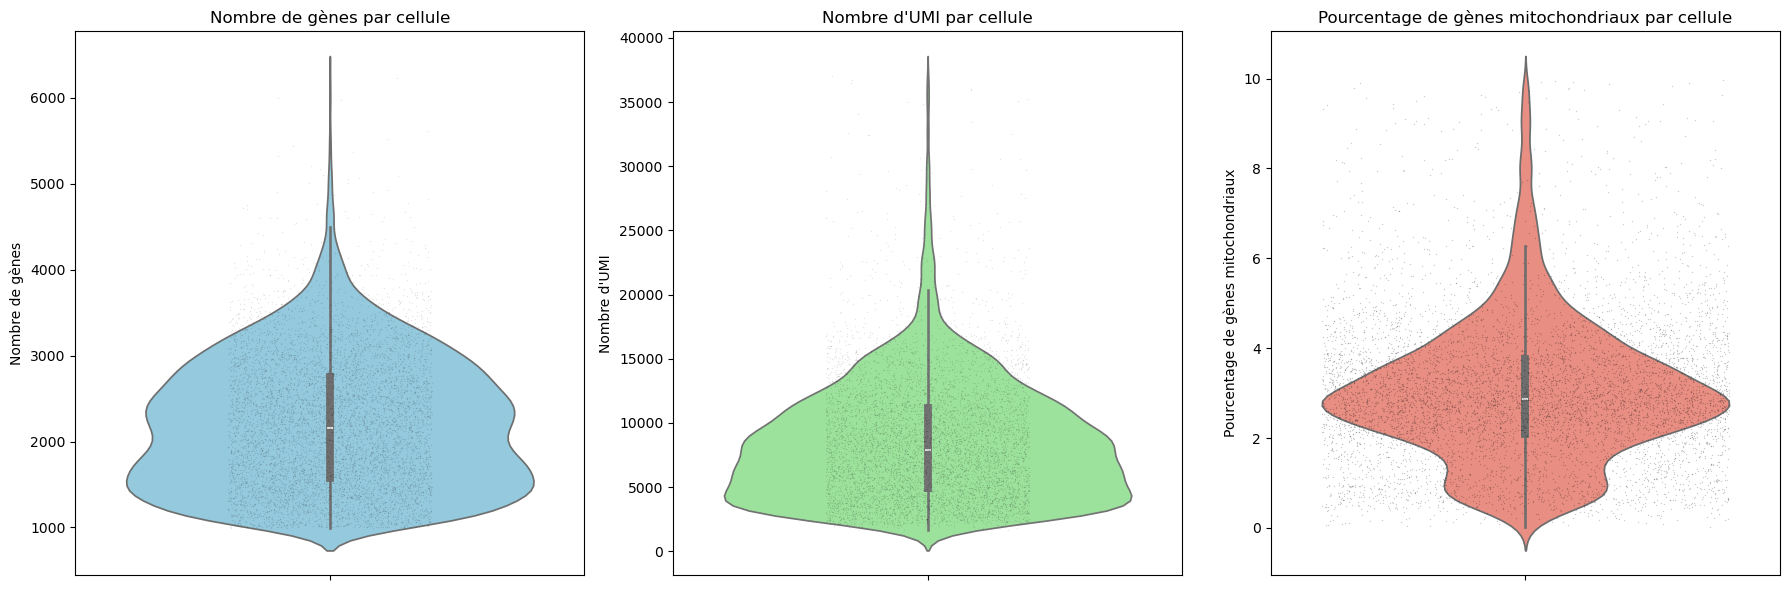


Traitement du tissu : craniofacial
Index(['h0_6', 'h0_9', 'h0_10', 'h0_17', 'h0_19', 'h0_22', 'h0_25', 'h0_28',
       'h0_30', 'h0_31',
       ...
       'l22_7792', 'l22_7807', 'l22_8863', 'l22_9305', 'l22_9805', 'l22_10432',
       'l22_11035', 'l22_11086', 'l22_11139', 'l22_11900'],
      dtype='object', length=21078)
             h0_6  h0_9  h0_10  h0_17  h0_19  h0_22  h0_25  h0_28  h0_30  \
MIR1302-2HG     0     0      0      0      0      0      0      0      0   
FAM138A         0     0      0      0      0      0      0      0      0   
OR4F5           0     0      0      0      0      0      0      0      0   
AL627309.1      0     0      0      0      0      0      0      0      0   
AL627309.3      0     0      0      0      0      0      0      0      0   
...           ...   ...    ...    ...    ...    ...    ...    ...    ...   
AC233755.2      0     0      0      0      0      0      0      0      0   
AC233755.1      0     0      0      0      0      0      0      0  

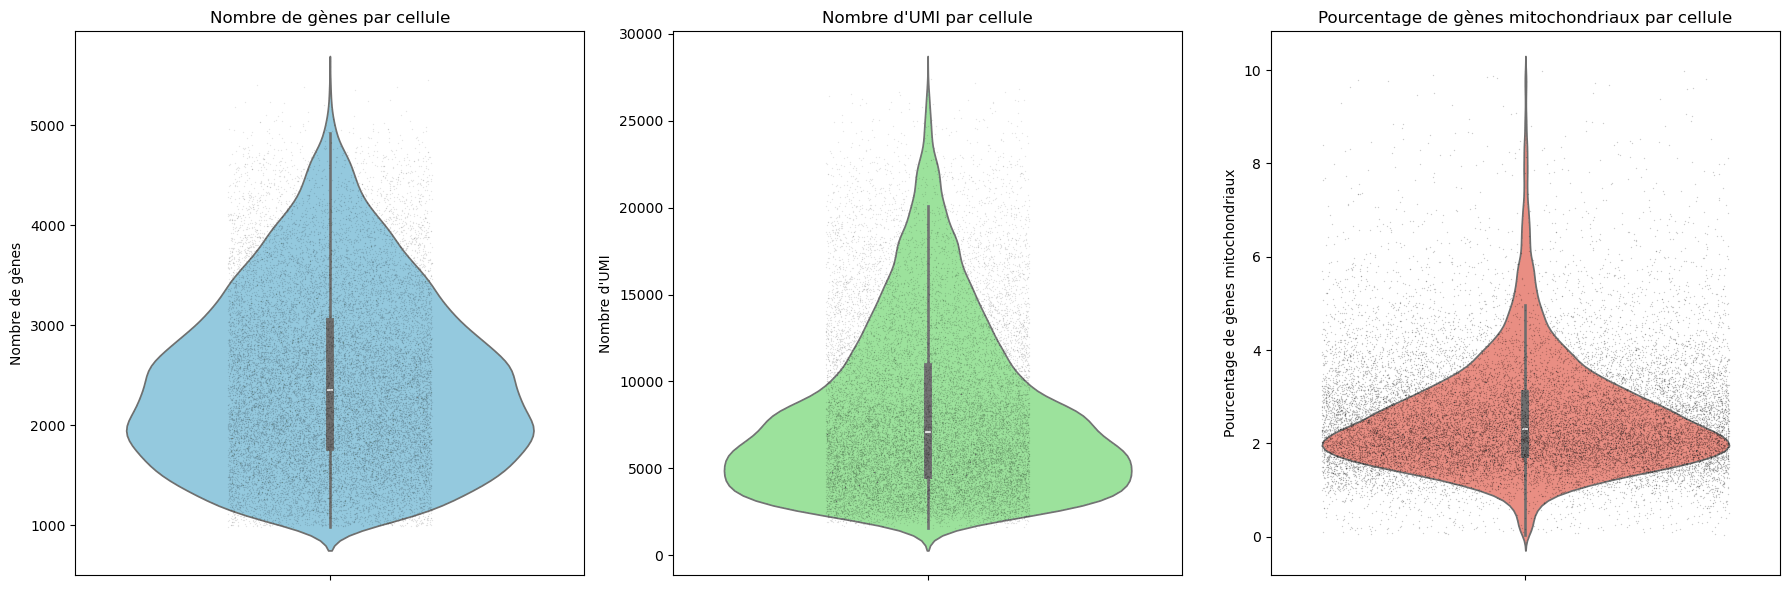


Traitement du tissu : endoderm
Index(['h0_26', 'h0_3916', 't0_1662', 't0_2012', 'v0_4', 'v0_44', 'v0_46',
       'v0_61', 'v0_71', 'v0_72',
       ...
       'l22_3289', 'l22_5572', 'l22_5663', 'l22_7302', 'l22_8878', 'l22_9568',
       'l22_10624', 'l22_10762', 'l22_11261', 'l22_11458'],
      dtype='object', length=4698)
             h0_26  h0_3916  t0_1662  t0_2012  v0_4  v0_44  v0_46  v0_61  \
MIR1302-2HG      0        0        0        0     0      0      0      0   
FAM138A          0        0        0        0     0      0      0      0   
OR4F5            0        0        0        0     0      0      0      0   
AL627309.1       0        0        0        0     0      0      0      0   
AL627309.3       0        0        0        0     0      0      0      0   
...            ...      ...      ...      ...   ...    ...    ...    ...   
AC233755.2       0        0        0        0     0      0      0      0   
AC233755.1       0        0        0        0     0      0      0 

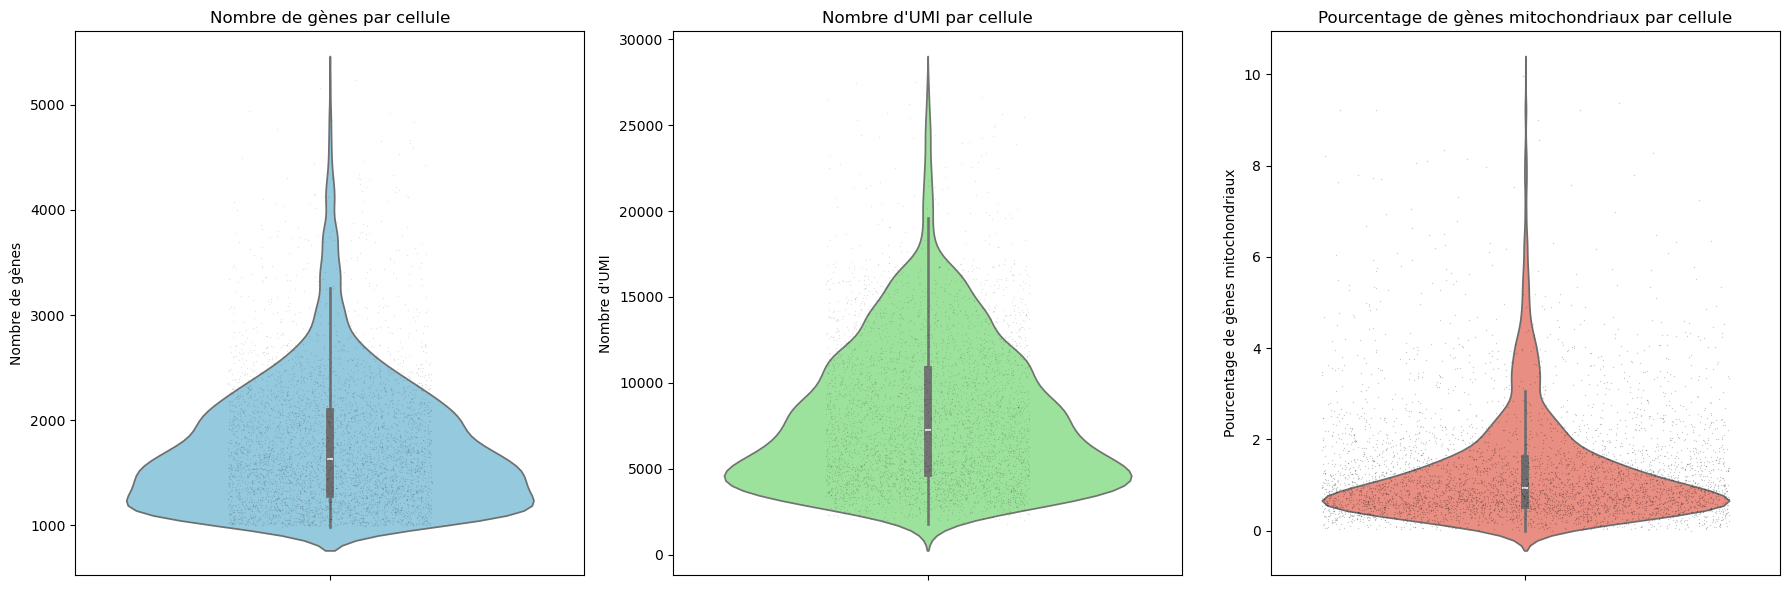


Traitement du tissu : endothelium
Index(['h0_84', 'h0_118', 'h0_177', 'h0_389', 'h0_397', 'h0_440', 'h0_512',
       'h0_580', 'h0_633', 'h0_641',
       ...
       'l22_9569', 'l22_9960', 'l22_10351', 'l22_10388', 'l22_10468',
       'l22_10531', 'l22_10807', 'l22_11011', 'l22_11387', 'l22_11886'],
      dtype='object', length=7357)
             h0_84  h0_118  h0_177  h0_389  h0_397  h0_440  h0_512  h0_580  \
MIR1302-2HG      0       0       0       0       0       0       0       0   
FAM138A          0       0       0       0       0       0       0       0   
OR4F5            0       0       0       0       0       0       0       0   
AL627309.1       0       0       0       0       0       0       0       0   
AL627309.3       0       0       0       0       0       0       0       0   
...            ...     ...     ...     ...     ...     ...     ...     ...   
AC233755.2       0       0       0       0       0       0       0       0   
AC233755.1       0       0       0     

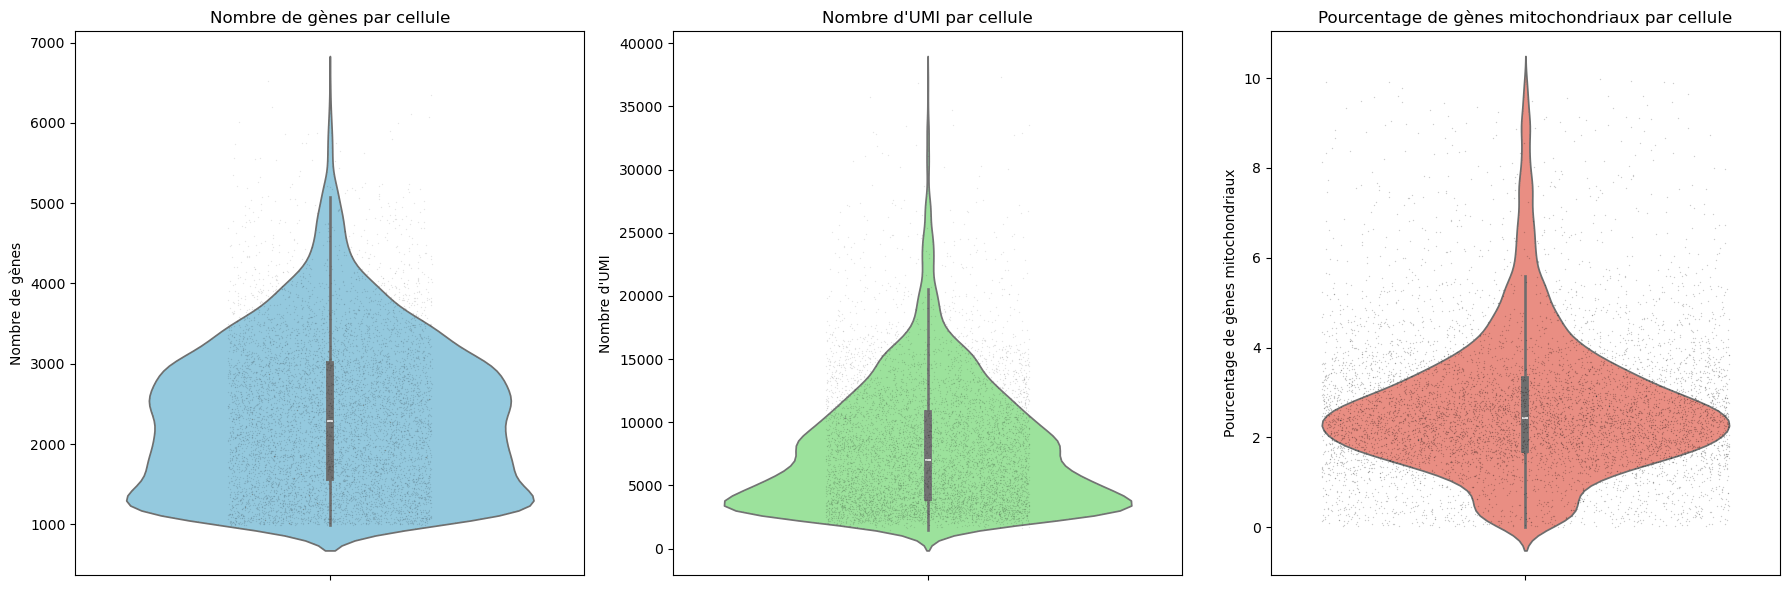


Traitement du tissu : epidermis
Index(['h0_29', 'h0_204', 'h0_348', 'h0_645', 'h0_851', 'h0_852', 'h0_985',
       'h0_1038', 'h0_1148', 'h0_1165',
       ...
       'l22_11406', 'l22_11529', 'l22_11581', 'l22_11602', 'l22_11642',
       'l22_11741', 'l22_11747', 'l22_11761', 'l22_11775', 'l22_11812'],
      dtype='object', length=1907)
             h0_29  h0_204  h0_348  h0_645  h0_851  h0_852  h0_985  h0_1038  \
MIR1302-2HG      0       0       0       0       0       0       0        0   
FAM138A          0       0       0       0       0       0       0        0   
OR4F5            0       0       0       0       0       0       0        0   
AL627309.1       0       0       0       0       0       0       0        0   
AL627309.3       0       0       0       0       0       0       0        0   
...            ...     ...     ...     ...     ...     ...     ...      ...   
AC233755.2       0       0       0       0       0       0       0        0   
AC233755.1       0       0  

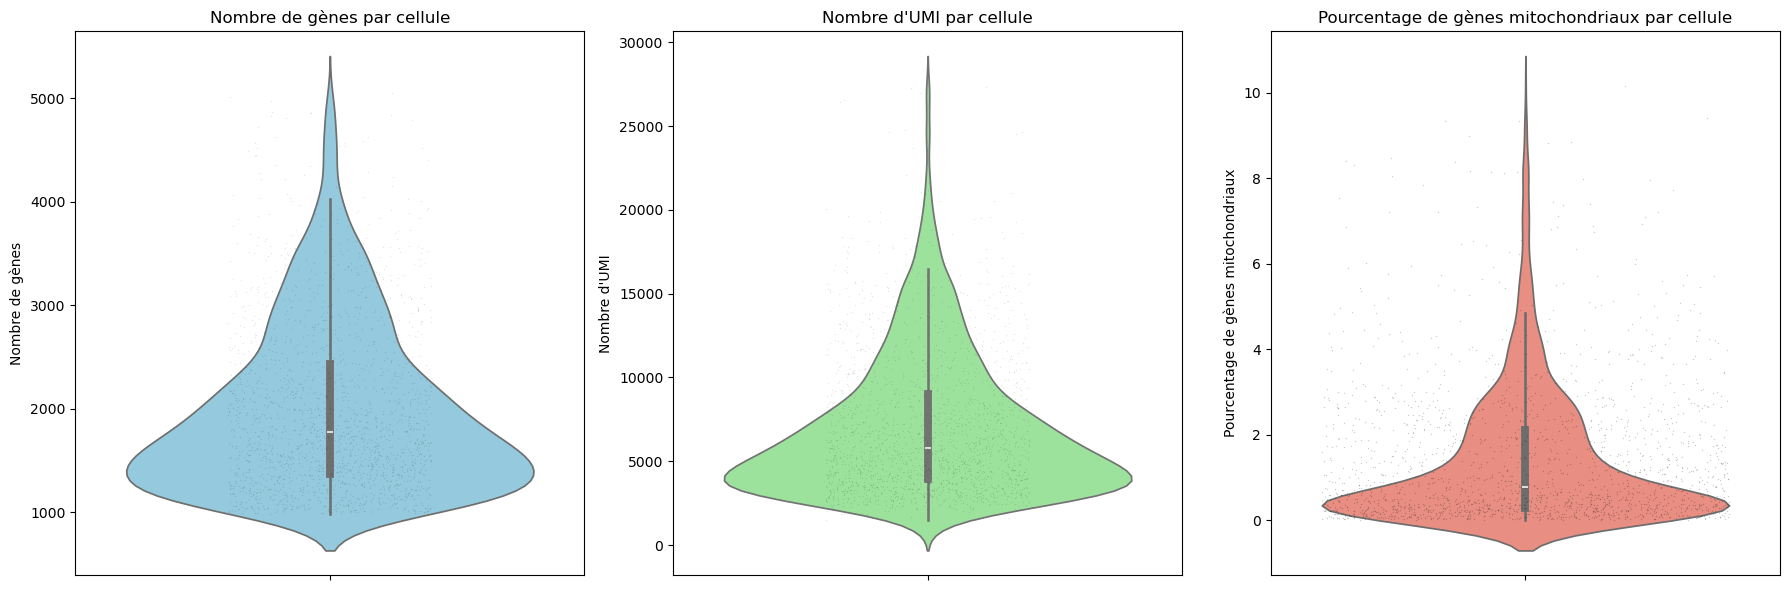


Traitement du tissu : epithelium
Index(['h0_60', 'h0_174', 'h0_203', 'h0_311', 'h0_313', 'h0_346', 'h0_469',
       'h0_483', 'h0_507', 'h0_685',
       ...
       'l21_21955', 'l21_21958', 'l21_22324', 'l21_22563', 'l21_23377',
       'l21_23645', 'l21_23899', 'l21_23902', 'l22_1502', 'l22_3695'],
      dtype='object', length=1795)
             h0_60  h0_174  h0_203  h0_311  h0_313  h0_346  h0_469  h0_483  \
MIR1302-2HG      0       0       0       0       0       0       0       0   
FAM138A          0       0       0       0       0       0       0       0   
OR4F5            0       0       0       0       0       0       0       0   
AL627309.1       0       0       0       0       0       0       0       0   
AL627309.3       0       0       0       0       0       0       0       0   
...            ...     ...     ...     ...     ...     ...     ...     ...   
AC233755.2       0       0       0       0       0       0       0       0   
AC233755.1       0       0       0      

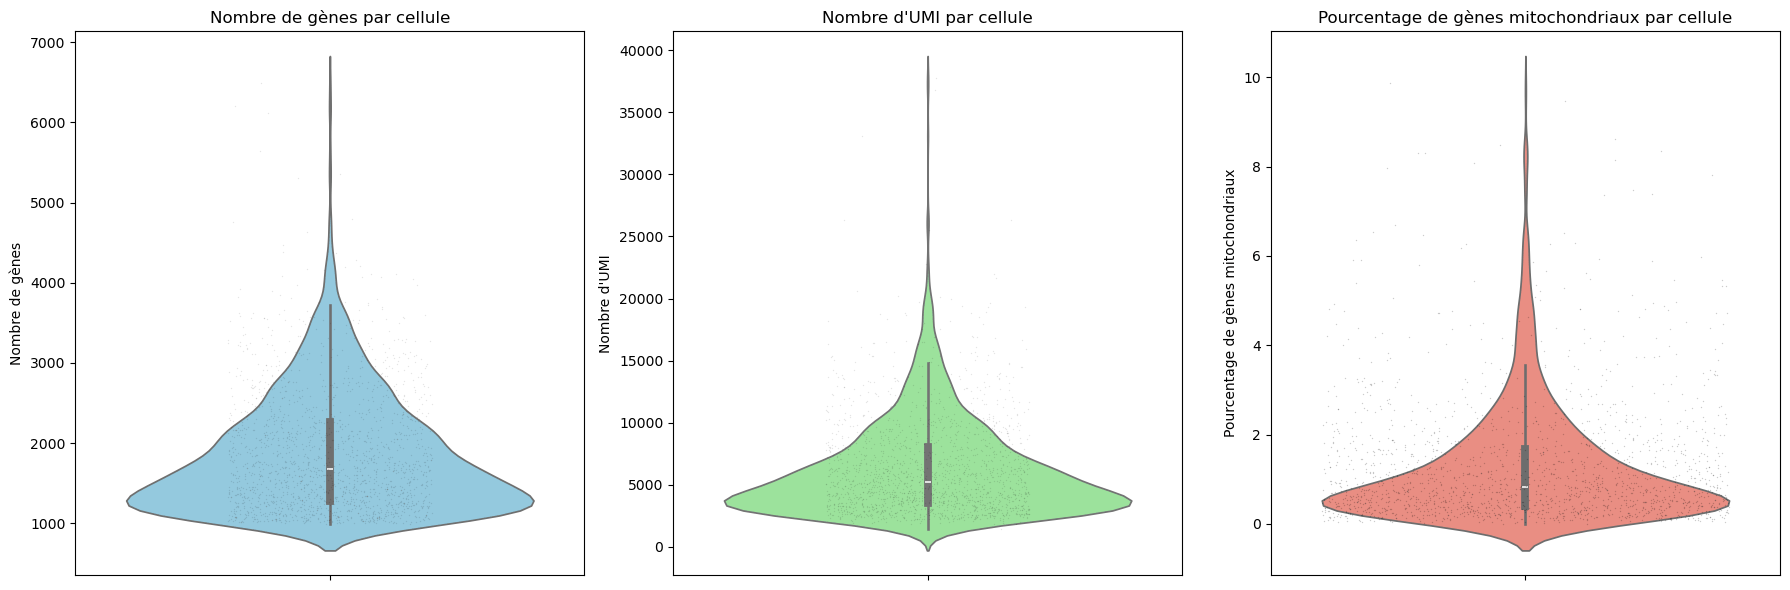


Traitement du tissu : fibroblast
Index(['h0_12', 'h0_282', 'h0_301', 'h0_314', 'h0_396', 'h0_560', 'h0_652',
       'h0_847', 'h0_848', 'h0_1349',
       ...
       'l21_23565', 'l21_23676', 'l22_911', 'l22_1550', 'l22_3976', 'l22_4461',
       'l22_5927', 'l22_6810', 'l22_8345', 'l22_11332'],
      dtype='object', length=4641)
             h0_12  h0_282  h0_301  h0_314  h0_396  h0_560  h0_652  h0_847  \
MIR1302-2HG      0       0       0       0       0       0       0       0   
FAM138A          0       0       0       0       0       0       0       0   
OR4F5            0       0       0       0       0       0       0       0   
AL627309.1       0       0       0       0       0       0       0       0   
AL627309.3       0       0       0       0       0       0       0       0   
...            ...     ...     ...     ...     ...     ...     ...     ...   
AC233755.2       0       0       0       0       0       0       0       0   
AC233755.1       0       0       0       0   

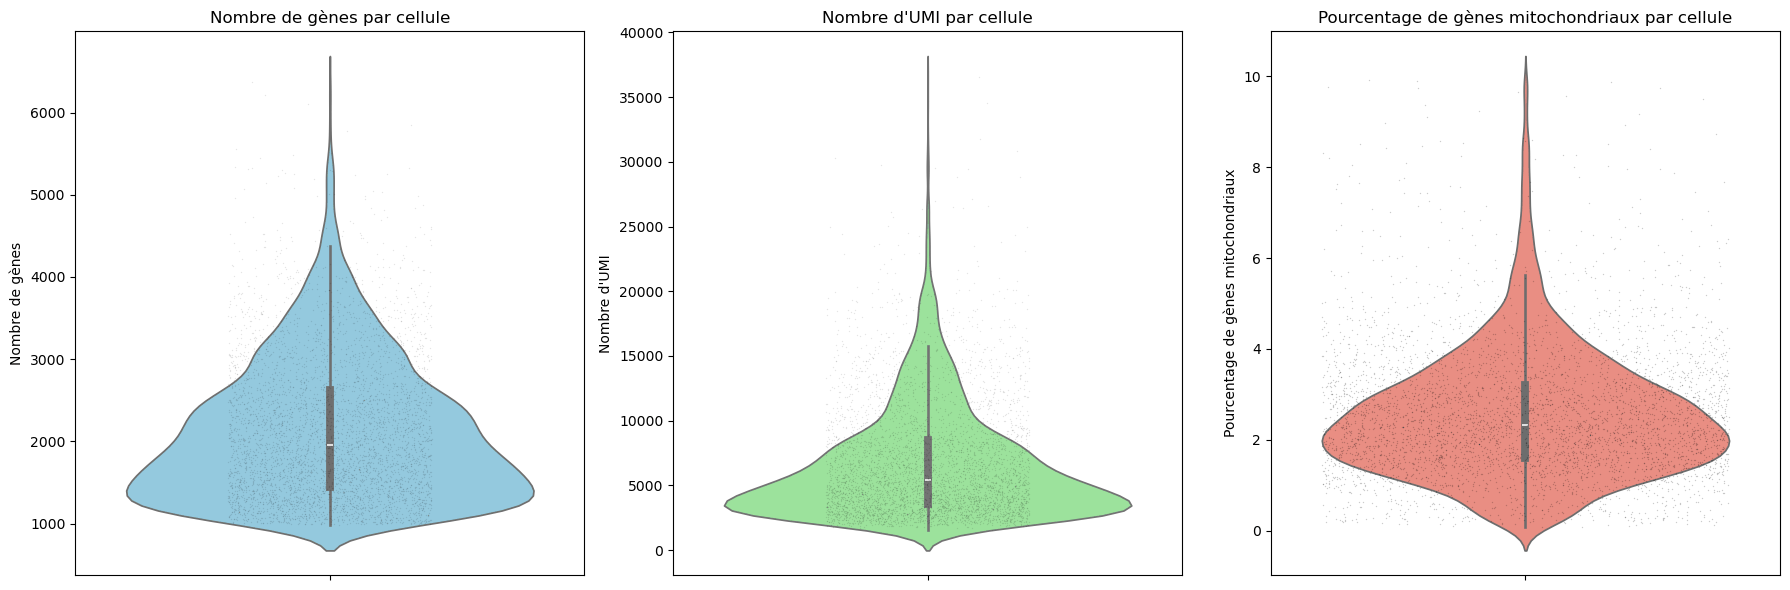


Traitement du tissu : head mesoderm
Index(['h0_2', 'h0_8', 'h0_11', 'h0_13', 'h0_21', 'h0_32', 'h0_36', 'h0_38',
       'h0_41', 'h0_42',
       ...
       'l22_5759', 'l22_6437', 'l22_7661', 'l22_8802', 'l22_8946', 'l22_9127',
       'l22_9977', 'l22_10008', 'l22_10049', 'l22_10748'],
      dtype='object', length=11581)
             h0_2  h0_8  h0_11  h0_13  h0_21  h0_32  h0_36  h0_38  h0_41  \
MIR1302-2HG     0     0      0      0      0      0      0      0      0   
FAM138A         0     0      0      0      0      0      0      0      0   
OR4F5           0     0      0      0      0      0      0      0      0   
AL627309.1      0     0      0      0      0      0      0      0      0   
AL627309.3      0     0      0      0      0      0      0      0      0   
...           ...   ...    ...    ...    ...    ...    ...    ...    ...   
AC233755.2      0     0      0      0      0      0      0      0      0   
AC233755.1      0     0      0      0      0      0      0      0   

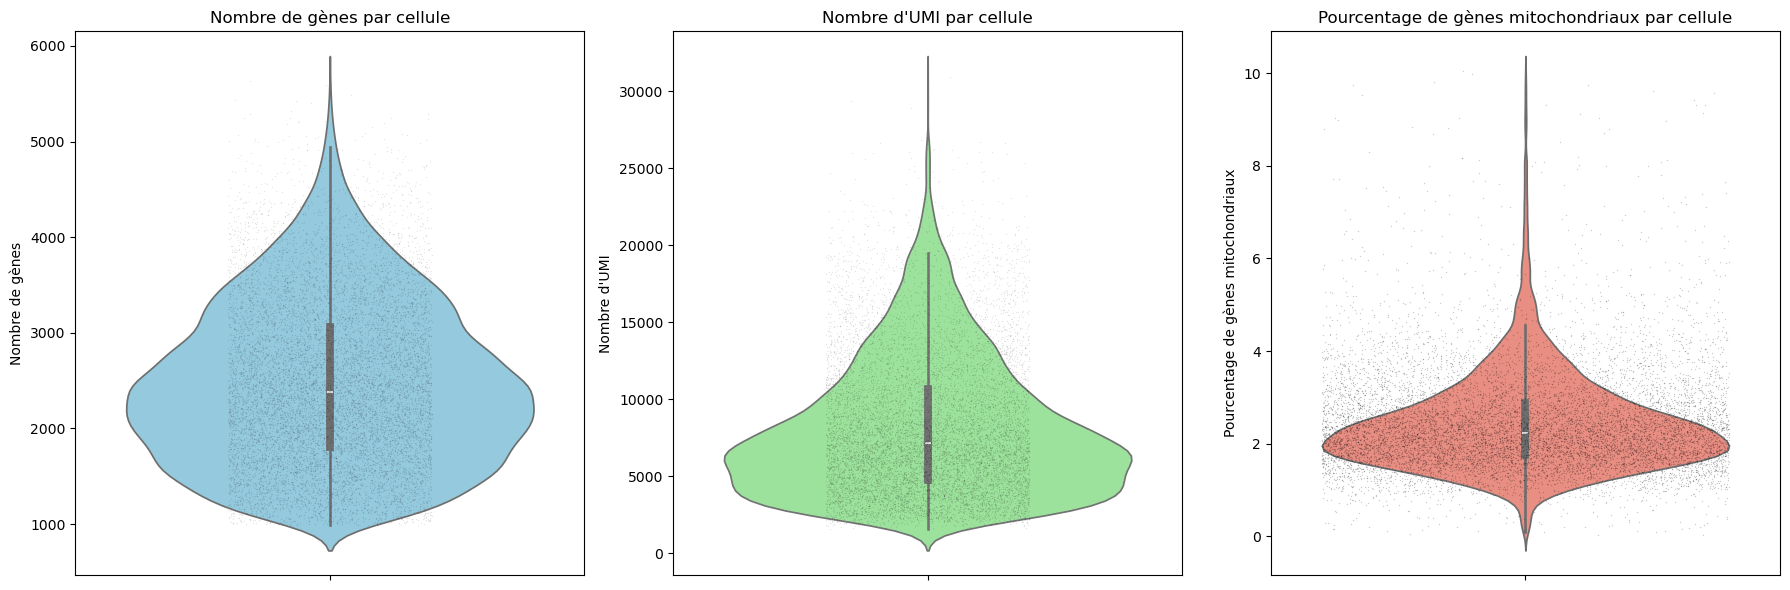


Traitement du tissu : limb
Index(['h0_281', 'l0_1', 'l0_2', 'l0_3', 'l0_4', 'l0_5', 'l0_6', 'l0_7',
       'l0_8', 'l0_9',
       ...
       'l22_11921', 'l22_11922', 'l22_11925', 'l22_11927', 'l22_11934',
       'l22_11936', 'l22_11942', 'l22_11947', 'l22_11951', 'l22_11956'],
      dtype='object', length=33404)
             h0_281  l0_1  l0_2  l0_3  l0_4  l0_5  l0_6  l0_7  l0_8  l0_9  \
MIR1302-2HG       0     0     0     0     0     0     0     0     0     0   
FAM138A           0     0     0     0     0     0     0     0     0     0   
OR4F5             0     0     0     0     0     0     0     0     0     0   
AL627309.1        0     0     0     0     0     0     0     0     0     0   
AL627309.3        0     0     0     0     0     0     0     0     0     0   
...             ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   
AC233755.2        0     0     0     0     0     0     0     0     0     0   
AC233755.1        0     0     0     0     0     0     0     0     0 

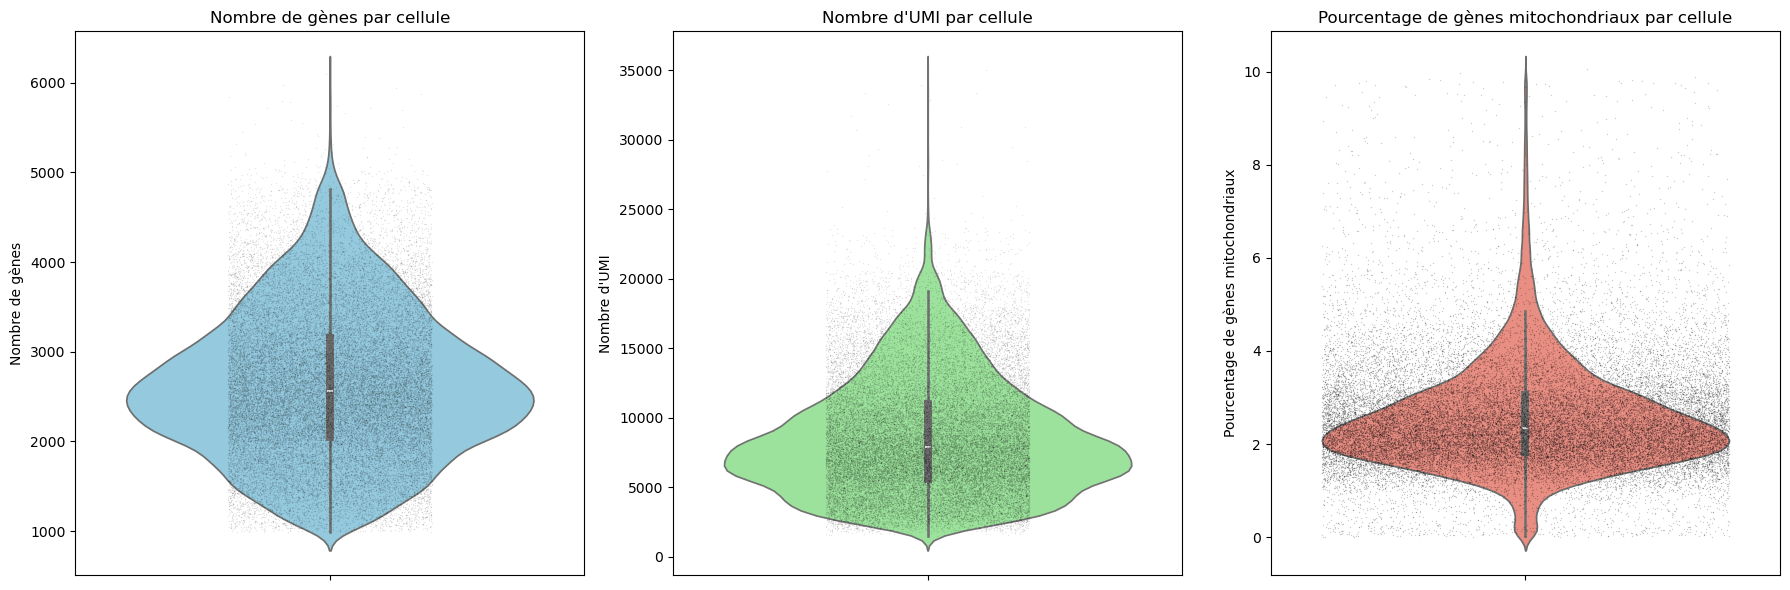


Traitement du tissu : miscellaneous
Index(['h0_80', 'h0_230', 'h0_271', 'h0_290', 'h0_357', 'h0_393', 'h0_401',
       'h0_402', 'h0_556', 'h0_650',
       ...
       'l21_23941', 'l21_23942', 'l21_23954', 'l21_23984', 'l22_269',
       'l22_1956', 'l22_2987', 'l22_7378', 'l22_8726', 'l22_9029'],
      dtype='object', length=4401)
             h0_80  h0_230  h0_271  h0_290  h0_357  h0_393  h0_401  h0_402  \
MIR1302-2HG      0       0       0       0       0       0       0       0   
FAM138A          0       0       0       0       0       0       0       0   
OR4F5            0       0       0       0       0       0       0       0   
AL627309.1       0       0       0       0       0       0       0       0   
AL627309.3       0       0       0       0       0       0       0       0   
...            ...     ...     ...     ...     ...     ...     ...     ...   
AC233755.2       0       0       0       0       0       0       0       0   
AC233755.1       0       0       0       0

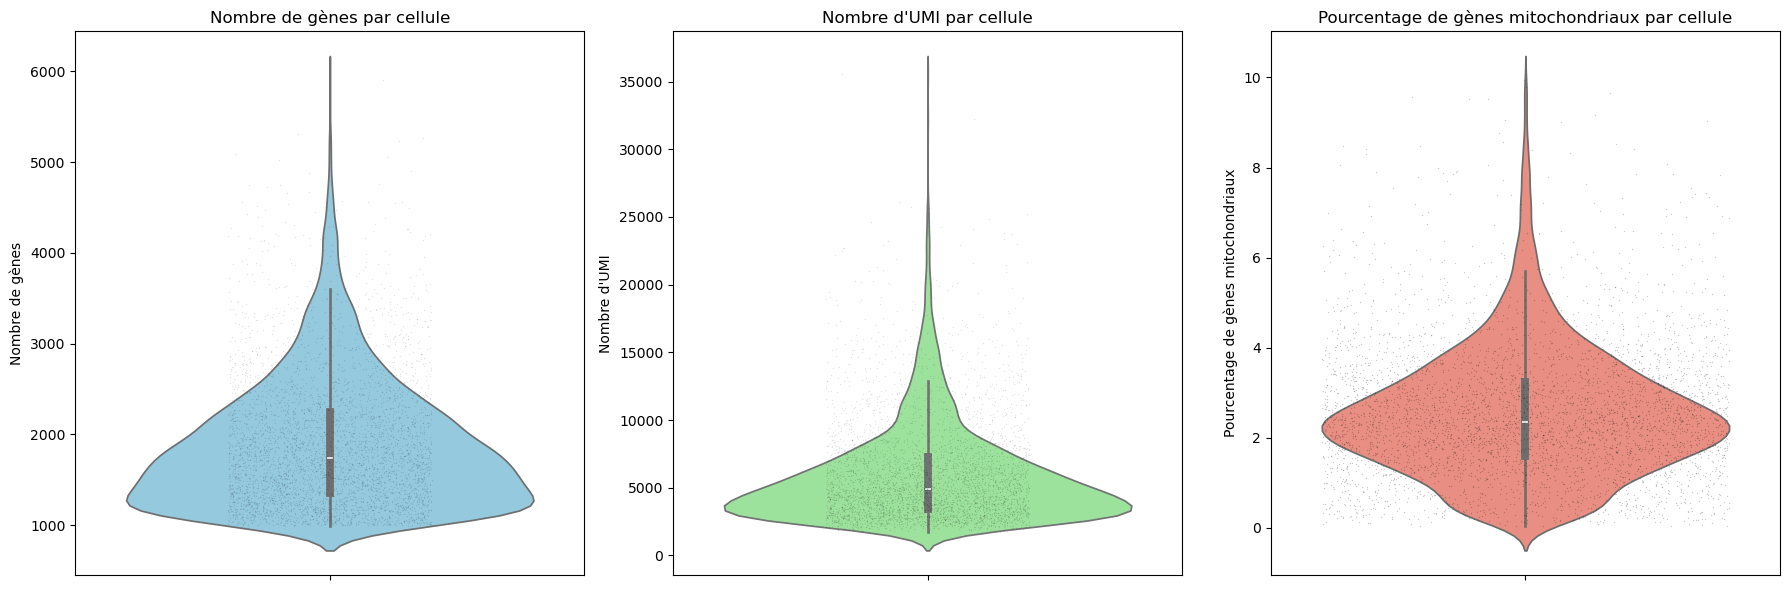


Traitement du tissu : neural progenitor
Index(['h0_1', 'h0_3', 'h0_4', 'h0_5', 'h0_7', 'h0_14', 'h0_16', 'h0_20',
       'h0_23', 'h0_24',
       ...
       'l21_13277', 'l21_13816', 'l21_16156', 'l21_16231', 'l21_17578',
       'l21_19666', 'l21_19942', 'l21_20122', 'l22_2280', 'l22_6587'],
      dtype='object', length=20897)
             h0_1  h0_3  h0_4  h0_5  h0_7  h0_14  h0_16  h0_20  h0_23  h0_24  \
MIR1302-2HG     0     0     0     0     0      0      0      0      0      0   
FAM138A         0     0     0     0     0      0      0      0      0      0   
OR4F5           0     0     0     0     0      0      0      0      0      0   
AL627309.1      0     0     0     0     0      0      0      0      0      0   
AL627309.3      0     0     0     0     0      0      0      0      0      0   
...           ...   ...   ...   ...   ...    ...    ...    ...    ...    ...   
AC233755.2      0     0     0     0     0      0      0      0      0      0   
AC233755.1      0     0     0 

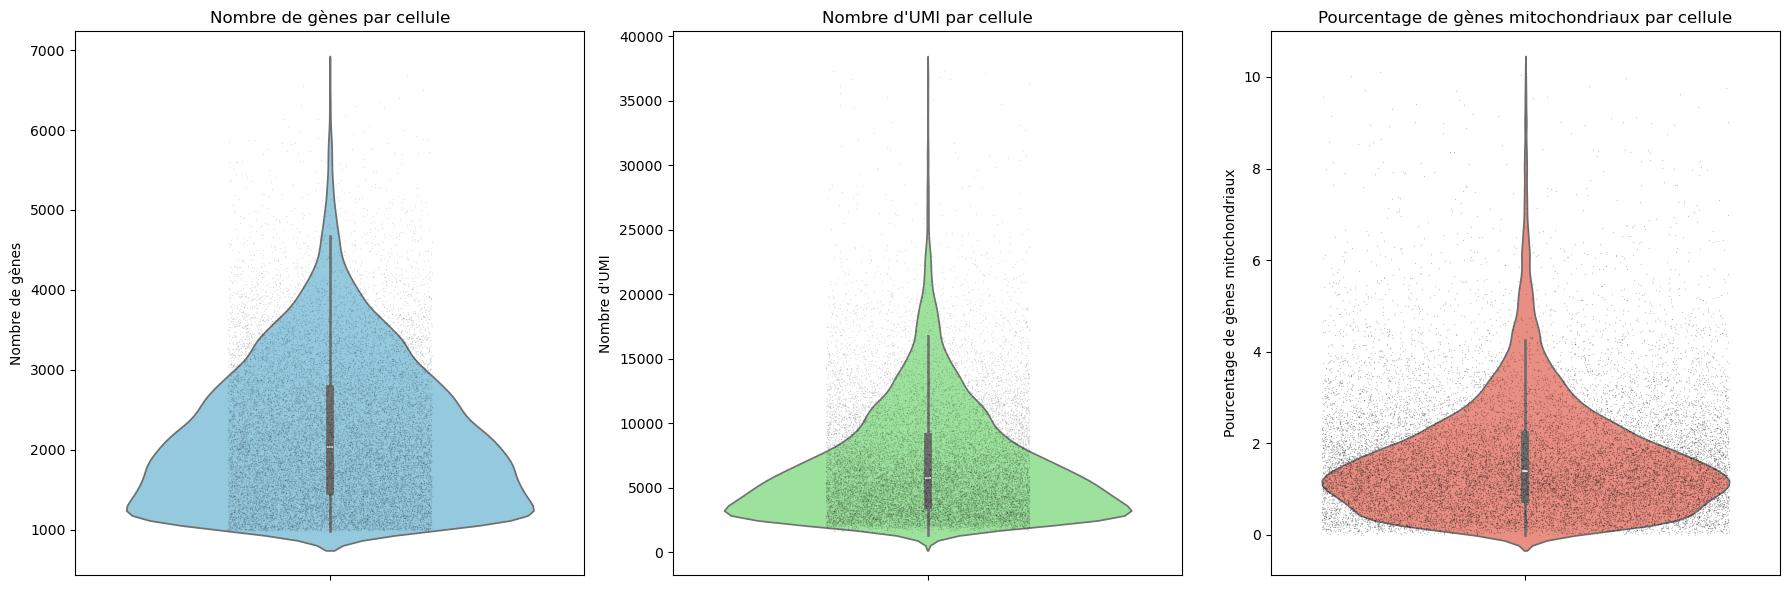


Traitement du tissu : neuron
Index(['h0_96', 'h0_324', 'h0_355', 'h0_362', 'h0_451', 'h0_600', 'h0_602',
       'h0_620', 'h0_626', 'h0_631',
       ...
       't22_23645', 't22_23649', 't22_23659', 't22_23682', 't22_23684',
       't22_23715', 't22_23727', 't22_23732', 't22_23780', 't22_23854'],
      dtype='object', length=5540)
             h0_96  h0_324  h0_355  h0_362  h0_451  h0_600  h0_602  h0_620  \
MIR1302-2HG      0       0       0       0       0       0       0       0   
FAM138A          0       0       0       0       0       0       0       0   
OR4F5            0       0       0       0       0       0       0       0   
AL627309.1       0       0       0       0       0       0       0       0   
AL627309.3       0       0       0       0       0       0       0       0   
...            ...     ...     ...     ...     ...     ...     ...     ...   
AC233755.2       0       0       0       0       0       0       0       0   
AC233755.1       0       0       0       0

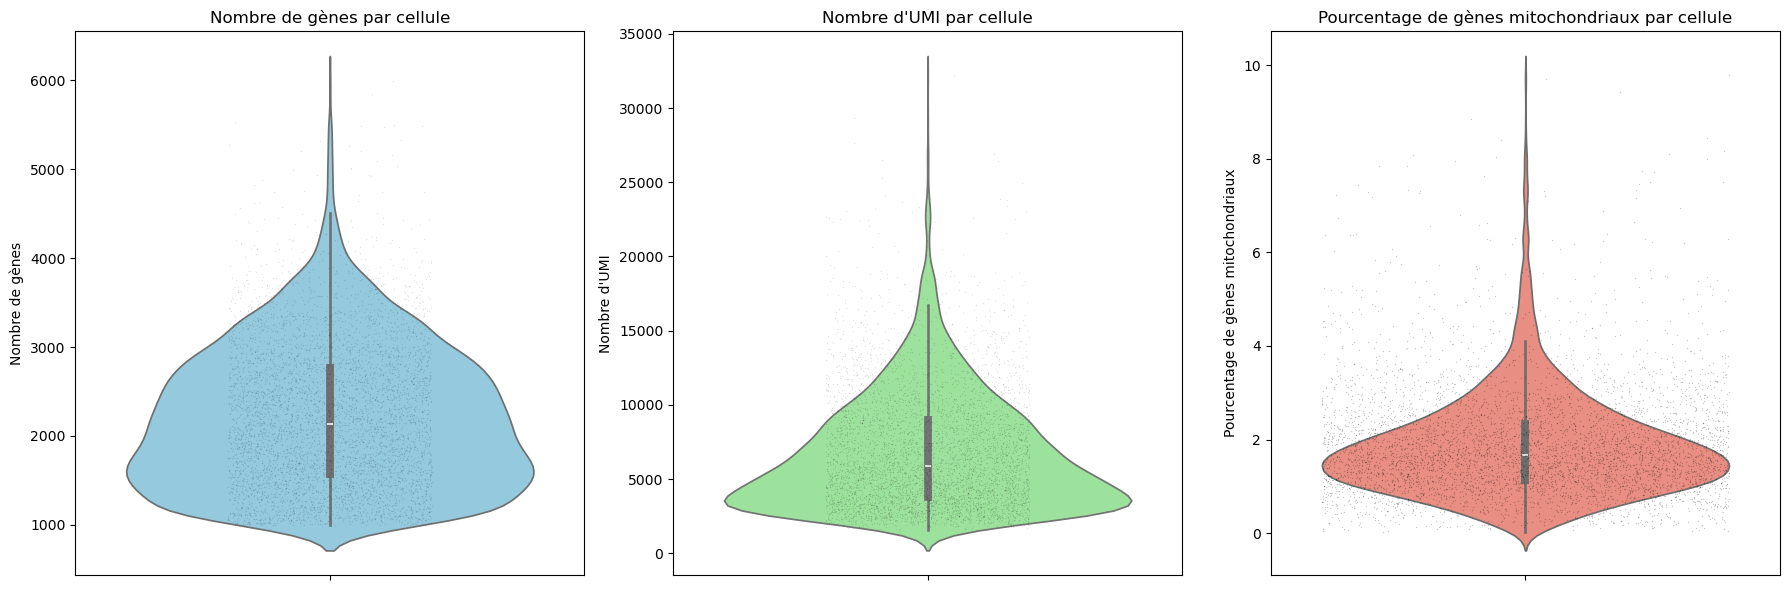


Traitement du tissu : schwann
Index(['h0_44', 'h0_68', 'h0_76', 'h0_180', 'h0_322', 'h0_775', 'h0_854',
       'h0_908', 'h0_936', 'h0_1094',
       ...
       'l21_16809', 'l21_19342', 'l21_19715', 'l21_21731', 'l21_21853',
       'l22_1052', 'l22_4744', 'l22_8949', 'l22_8971', 'l22_9134'],
      dtype='object', length=2788)
             h0_44  h0_68  h0_76  h0_180  h0_322  h0_775  h0_854  h0_908  \
MIR1302-2HG      0      0      0       0       0       0       0       0   
FAM138A          0      0      0       0       0       0       0       0   
OR4F5            0      0      0       0       0       0       0       0   
AL627309.1       0      0      0       0       0       0       0       0   
AL627309.3       0      0      0       0       0       0       0       0   
...            ...    ...    ...     ...     ...     ...     ...     ...   
AC233755.2       0      0      0       0       0       0       0       0   
AC233755.1       0      0      0       0       0       0       

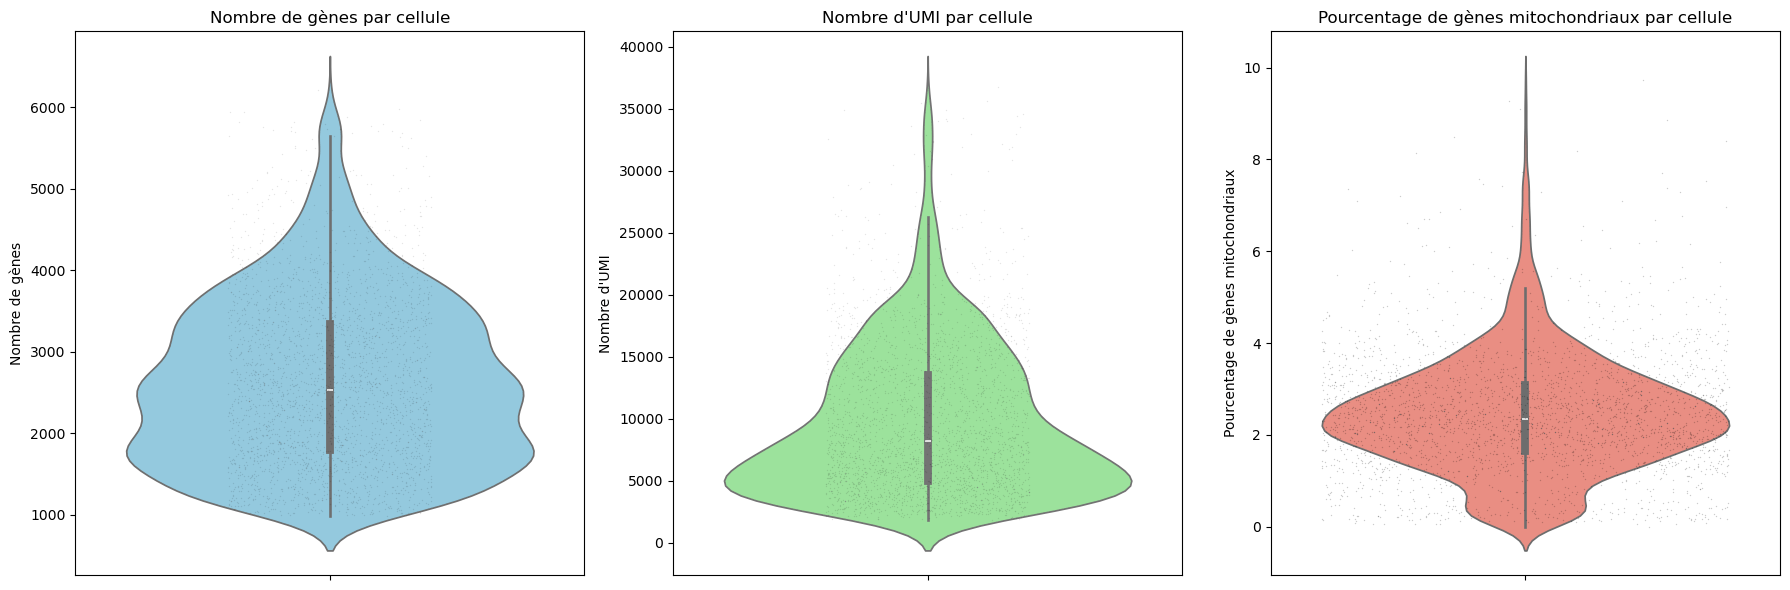


Traitement du tissu : sensory neuron
Index(['h0_49', 'h0_71', 'h0_79', 'h0_161', 'h0_205', 'h0_212', 'h0_542',
       'h0_653', 'h0_790', 'h0_809',
       ...
       't22_22677', 't22_22776', 't22_22782', 't22_23000', 't22_23314',
       't22_23476', 't22_23512', 't22_23574', 'l21_3882', 'l21_7992'],
      dtype='object', length=1166)
             h0_49  h0_71  h0_79  h0_161  h0_205  h0_212  h0_542  h0_653  \
MIR1302-2HG      0      0      0       0       0       0       0       0   
FAM138A          0      0      0       0       0       0       0       0   
OR4F5            0      0      0       0       0       0       0       0   
AL627309.1       0      0      0       0       0       0       0       0   
AL627309.3       0      0      0       0       0       0       0       0   
...            ...    ...    ...     ...     ...     ...     ...     ...   
AC233755.2       0      0      0       0       0       0       0       0   
AC233755.1       0      0      0       0       0      

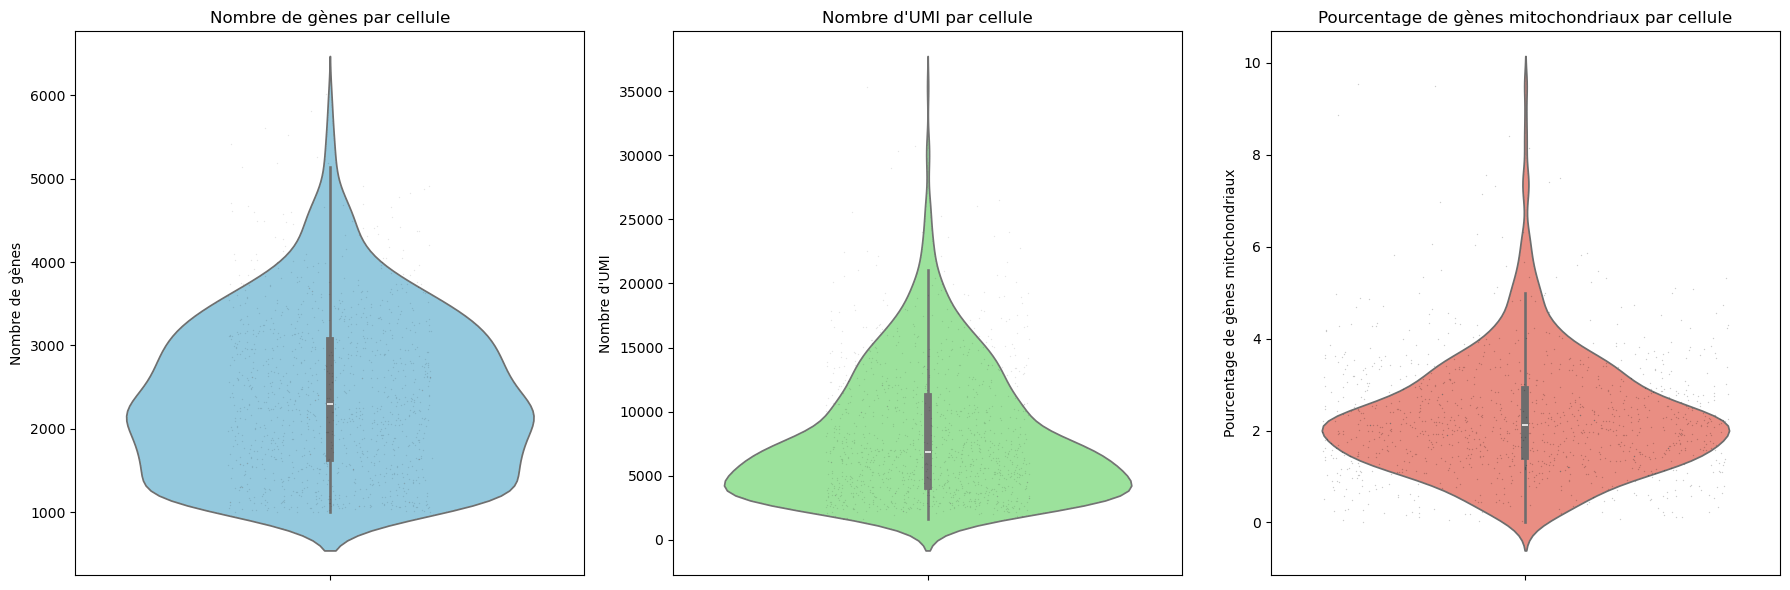


Traitement du tissu : somatic LPM
Index(['h0_794', 'h0_1857', 'l0_130', 'l0_255', 'l0_259', 'l0_345', 'l0_589',
       'l0_676', 'l0_822', 'l0_973',
       ...
       'l22_10296', 'l22_10450', 'l22_10524', 'l22_10908', 'l22_10949',
       'l22_11077', 'l22_11392', 'l22_11431', 'l22_11591', 'l22_11619'],
      dtype='object', length=9109)
             h0_794  h0_1857  l0_130  l0_255  l0_259  l0_345  l0_589  l0_676  \
MIR1302-2HG       0        0       0       0       0       0       0       0   
FAM138A           0        0       0       0       0       0       0       0   
OR4F5             0        0       0       0       0       0       0       0   
AL627309.1        0        0       0       0       0       0       0       0   
AL627309.3        0        0       0       0       0       0       0       0   
...             ...      ...     ...     ...     ...     ...     ...     ...   
AC233755.2        0        0       0       0       0       0       0       0   
AC233755.1        0

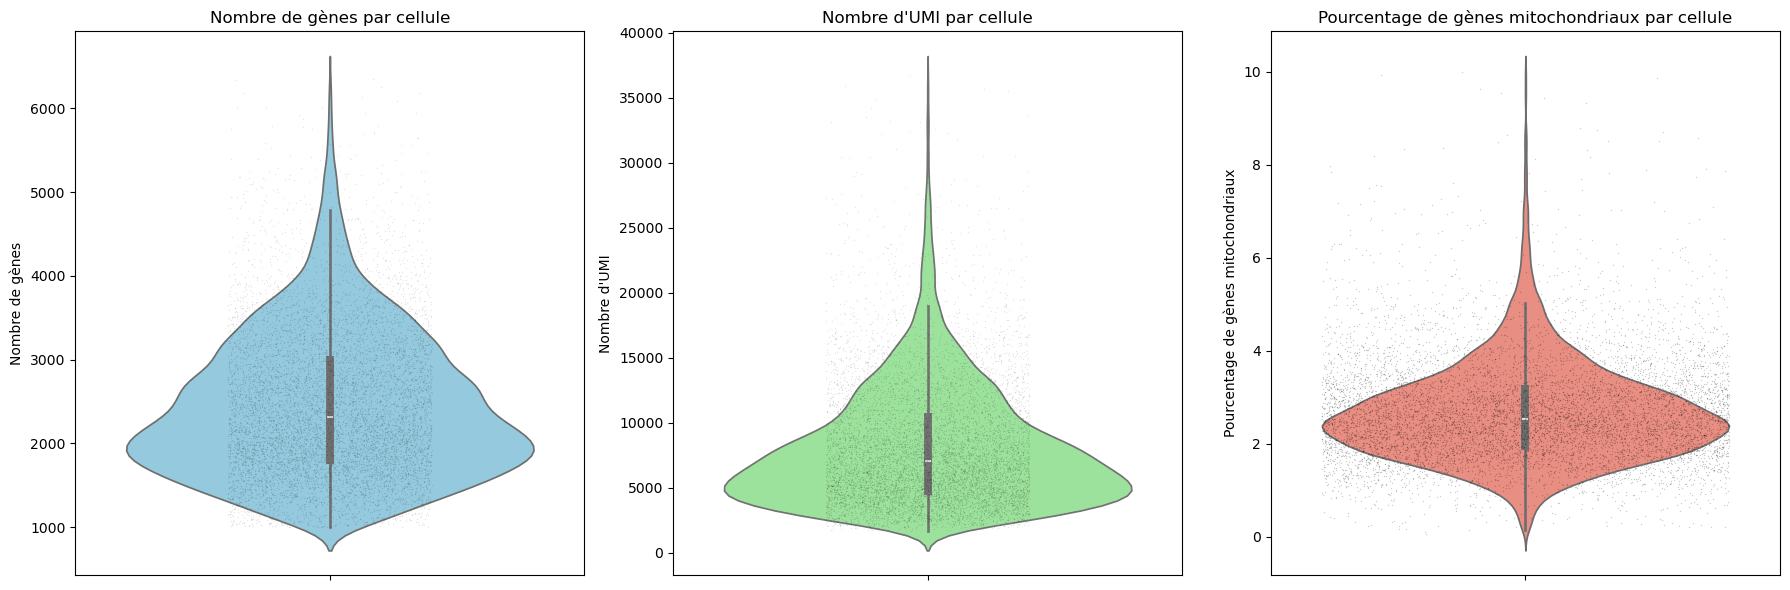


Traitement du tissu : somite
Index(['h0_40', 'h0_364', 'h0_370', 'h0_434', 'h0_464', 'h0_467', 'h0_474',
       'h0_618', 'h0_799', 'h0_932',
       ...
       'l22_11426', 'l22_11433', 'l22_11503', 'l22_11625', 'l22_11718',
       'l22_11720', 'l22_11726', 'l22_11791', 'l22_11904', 'l22_11933'],
      dtype='object', length=32188)
             h0_40  h0_364  h0_370  h0_434  h0_464  h0_467  h0_474  h0_618  \
MIR1302-2HG      0       0       0       0       0       0       0       0   
FAM138A          0       0       0       0       0       0       0       0   
OR4F5            0       0       0       0       0       0       0       0   
AL627309.1       0       0       0       0       0       0       0       0   
AL627309.3       0       0       0       0       0       0       0       0   
...            ...     ...     ...     ...     ...     ...     ...     ...   
AC233755.2       0       0       0       0       0       0       0       0   
AC233755.1       0       0       0       

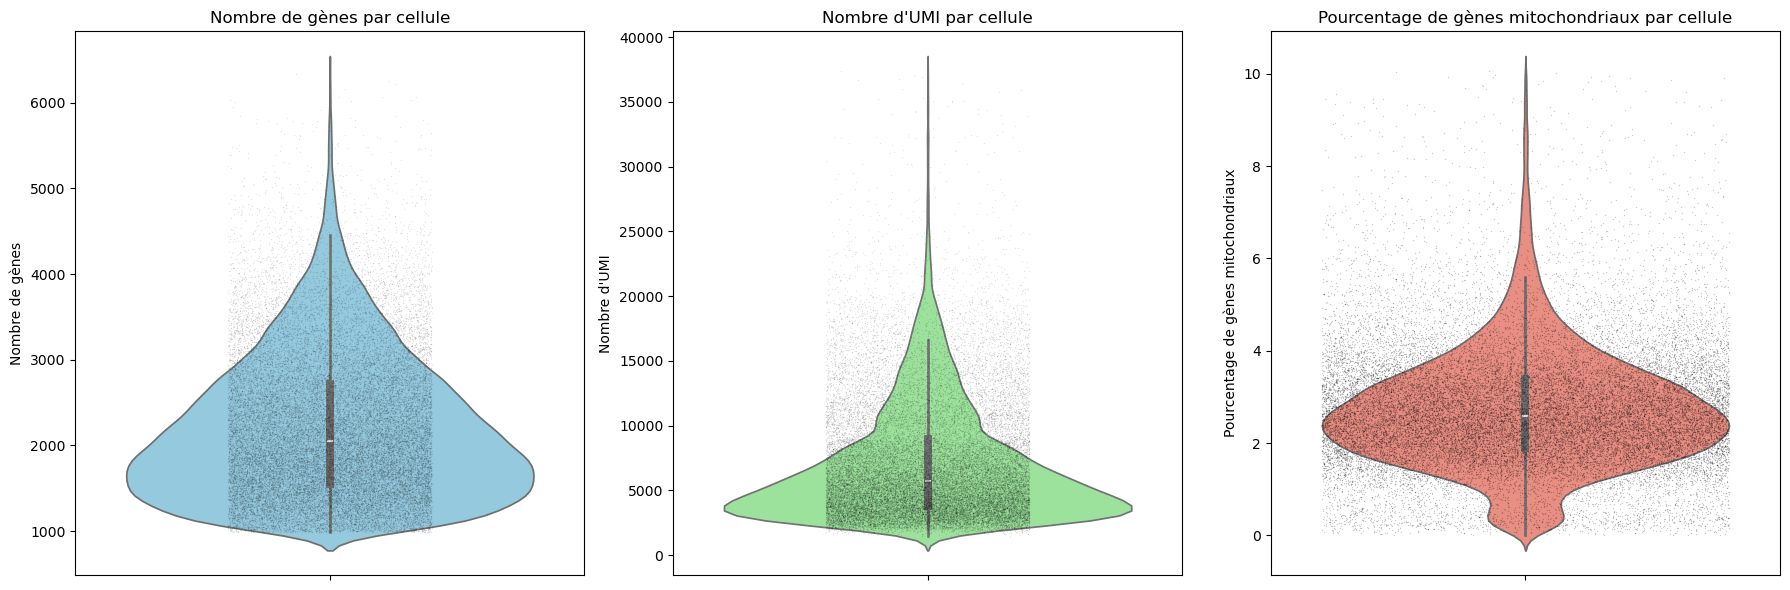


Traitement du tissu : splanchnic LPM
Index(['h0_52', 'h0_156', 'h0_190', 'h0_227', 'h0_257', 'h0_273', 'h0_310',
       'h0_318', 'h0_372', 'h0_414',
       ...
       'l21_23427', 'l21_23624', 'l21_23930', 'l22_3207', 'l22_3212',
       'l22_4063', 'l22_4164', 'l22_10203', 'l22_11037', 'l22_11311'],
      dtype='object', length=14454)
             h0_52  h0_156  h0_190  h0_227  h0_257  h0_273  h0_310  h0_318  \
MIR1302-2HG      0       0       0       0       0       0       0       0   
FAM138A          0       0       0       0       0       0       0       0   
OR4F5            0       0       0       0       0       0       0       0   
AL627309.1       0       0       0       0       0       0       0       0   
AL627309.3       0       0       0       0       0       0       0       0   
...            ...     ...     ...     ...     ...     ...     ...     ...   
AC233755.2       0       0       0       0       0       0       0       0   
AC233755.1       0       0       0   

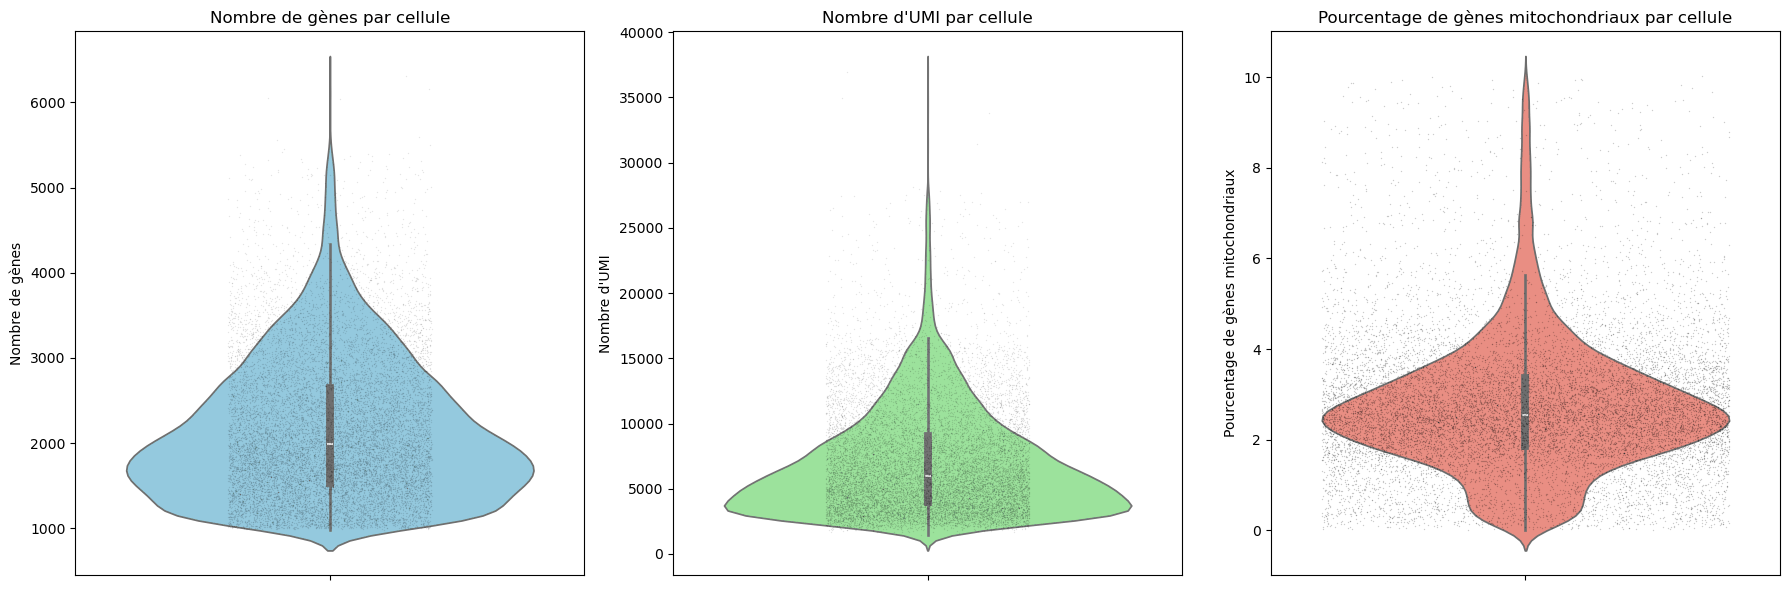

In [21]:
df_tissus = pd.Series(data= tissus, index=cells, name="Tissu")

for tissu  in tissus_unique:
    print(f"\nTraitement du tissu : {tissu}")
    
    # Récupérer les cellules correspondant à ce tissu
    cellules_du_tissu = df_tissus[df_tissus == tissu].index
    print (cellules_du_tissu)
    # Sous-ensemble du DataFrame d'expression pour ces cellules 
    df_expr = pd.DataFrame()
    for cellule in cellules_du_tissu:
        if cellule in df3_tissu.columns:  # Vérifie que la cellule existe bien dans le DataFrame source
            df_expr[cellule] = df3_tissu[cellule]
    print (df_expr)
    # Appliquer la fonction de contrôle qualité
    QC_violin(df_expr, genes=df3_tissu.index)
    
    

##### Nettoyage 

In [24]:
df3_tissus_filtered = filter_cells(df3_tissu, genes, min_gene = 200, max_gene = 2000, max_mito = 10)

Nombre de cellules avant filtrage : 185140
Nombre de cellules après filtrage : 65063


In [25]:
df_tissus_filtered = df_tissus.loc[df_tissus.index.intersection(df3_tissus_filtered.columns)]


In [26]:
print(df_tissus_filtered)

h0_48        neural progenitor
h0_125       neural progenitor
h0_229       neural progenitor
h0_271           miscellaneous
h0_372          splanchnic LPM
                   ...        
tv7_20857                blood
tv7_20881                blood
tv7_21017                blood
tv7_21064                blood
tv7_21472                blood
Name: Tissu, Length: 65063, dtype: object


#### Controle qualite apres filtrage 


Traitement du tissu : IM
Index(['t9_1683', 'h5_933', 'h5_2193', 'h5_4583', 't5_273', 't5_5927',
       't5_5970', 't5_11816', 't5_12934', 't5_13061',
       ...
       't22_20229', 't22_21781', 't22_21980', 't22_22378', 'l21_1540',
       'l21_2062', 'l21_15001', 'l21_16012', 'l21_17256', 'l21_23127'],
      dtype='object', length=266)
             t9_1683  h5_933  h5_2193  h5_4583  t5_273  t5_5927  t5_5970  \
MIR1302-2HG        0       0        0        0       0        0        0   
FAM138A            0       0        0        0       0        0        0   
OR4F5              0       0        0        0       0        0        0   
AL627309.1         0       0        0        0       0        0        0   
AL627309.3         0       0        0        0       0        0        0   
...              ...     ...      ...      ...     ...      ...      ...   
AC233755.2         0       0        0        0       0        0        0   
AC233755.1         0       0        0        0       

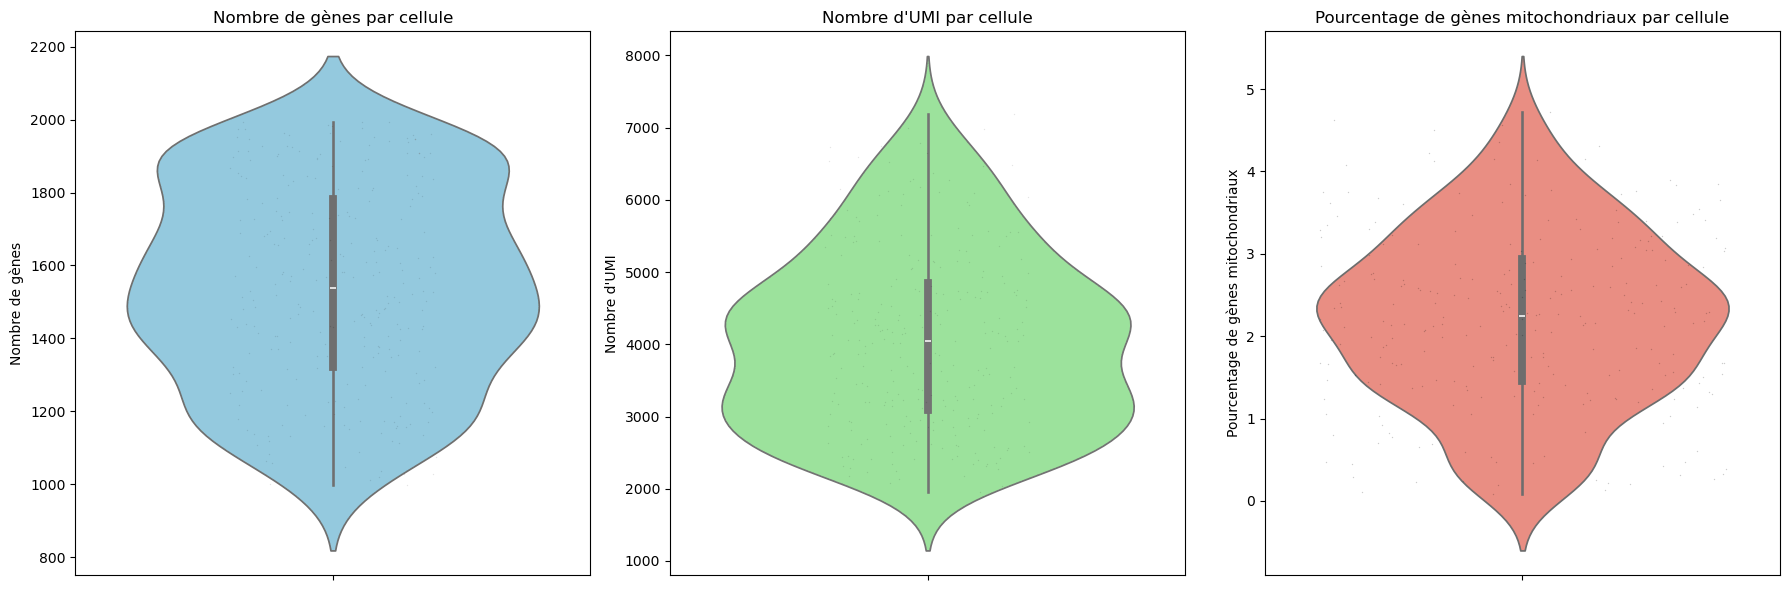


Traitement du tissu : PGC
Index([], dtype='object')
Aucune cellule pour le tissu PGC, on saute.

Traitement du tissu : blood
Index(['h0_4266', 'l0_114', 'l0_8176', 'l0_8577', 'l0_8591', 'h9a_3366',
       'h9b_2482', 'h9b_3880', 't9_1031', 't9_1650',
       ...
       'tv7_20525', 'tv7_20549', 'tv7_20644', 'tv7_20742', 'tv7_20824',
       'tv7_20857', 'tv7_20881', 'tv7_21017', 'tv7_21064', 'tv7_21472'],
      dtype='object', length=2137)
             h0_4266  l0_114  l0_8176  l0_8577  l0_8591  h9a_3366  h9b_2482  \
MIR1302-2HG        0       0        0        0        0         0         0   
FAM138A            0       0        0        0        0         0         0   
OR4F5              0       0        0        0        0         0         0   
AL627309.1         0       0        0        0        0         0         0   
AL627309.3         0       0        0        0        0         0         0   
...              ...     ...      ...      ...      ...       ...       ...   
AC23

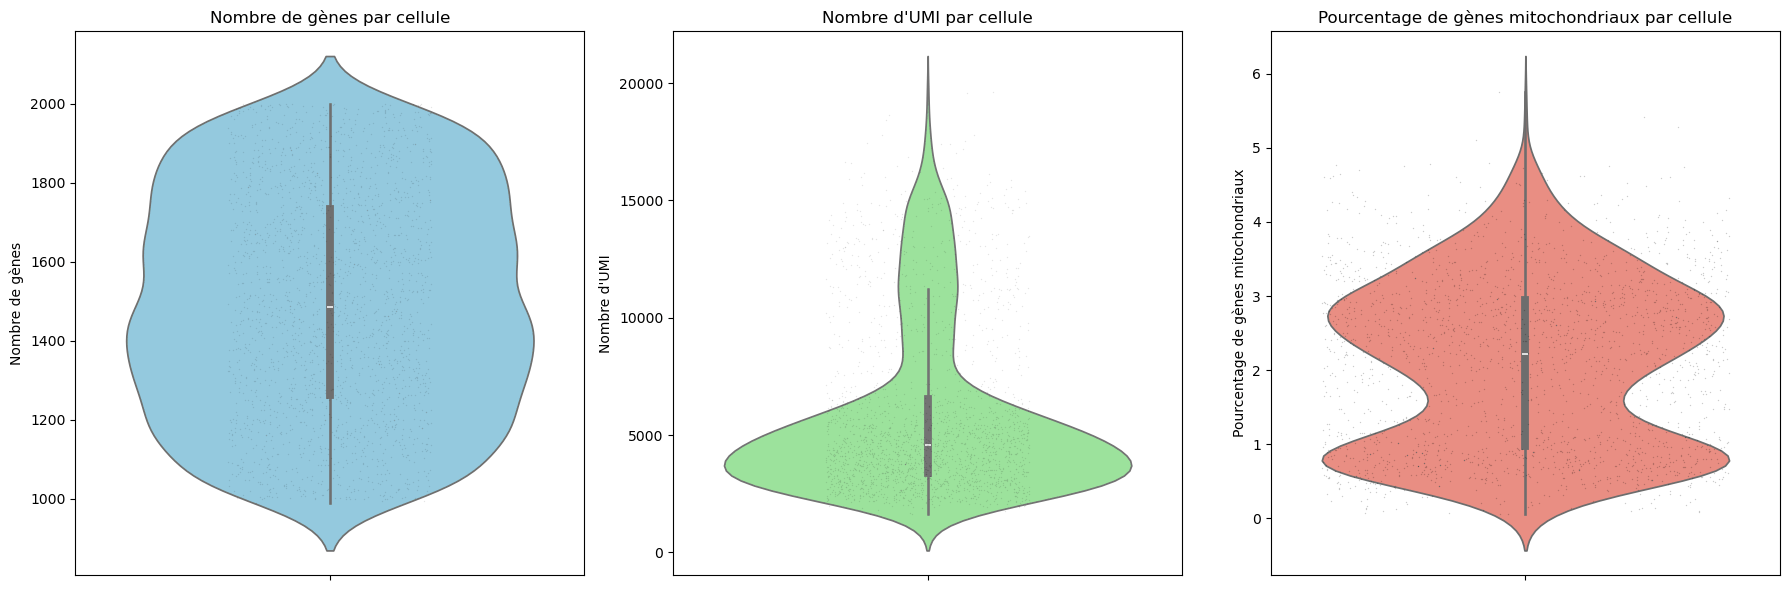


Traitement du tissu : craniofacial
Index(['h0_407', 'h0_1073', 'h0_3985', 'h0_4515', 'h9a_95', 'h9a_292',
       'h9a_469', 'h9a_694', 'h9a_835', 'h9a_1497',
       ...
       'l22_682', 'l22_1600', 'l22_4339', 'l22_5519', 'l22_7792', 'l22_7807',
       'l22_8863', 'l22_9805', 'l22_11086', 'l22_11139'],
      dtype='object', length=6241)
             h0_407  h0_1073  h0_3985  h0_4515  h9a_95  h9a_292  h9a_469  \
MIR1302-2HG       0        0        0        0       0        0        0   
FAM138A           0        0        0        0       0        0        0   
OR4F5             0        0        0        0       0        0        0   
AL627309.1        0        0        0        0       0        0        0   
AL627309.3        0        0        0        0       0        0        0   
...             ...      ...      ...      ...     ...      ...      ...   
AC233755.2        0        0        0        0       0        0        0   
AC233755.1        0        0        0        0     

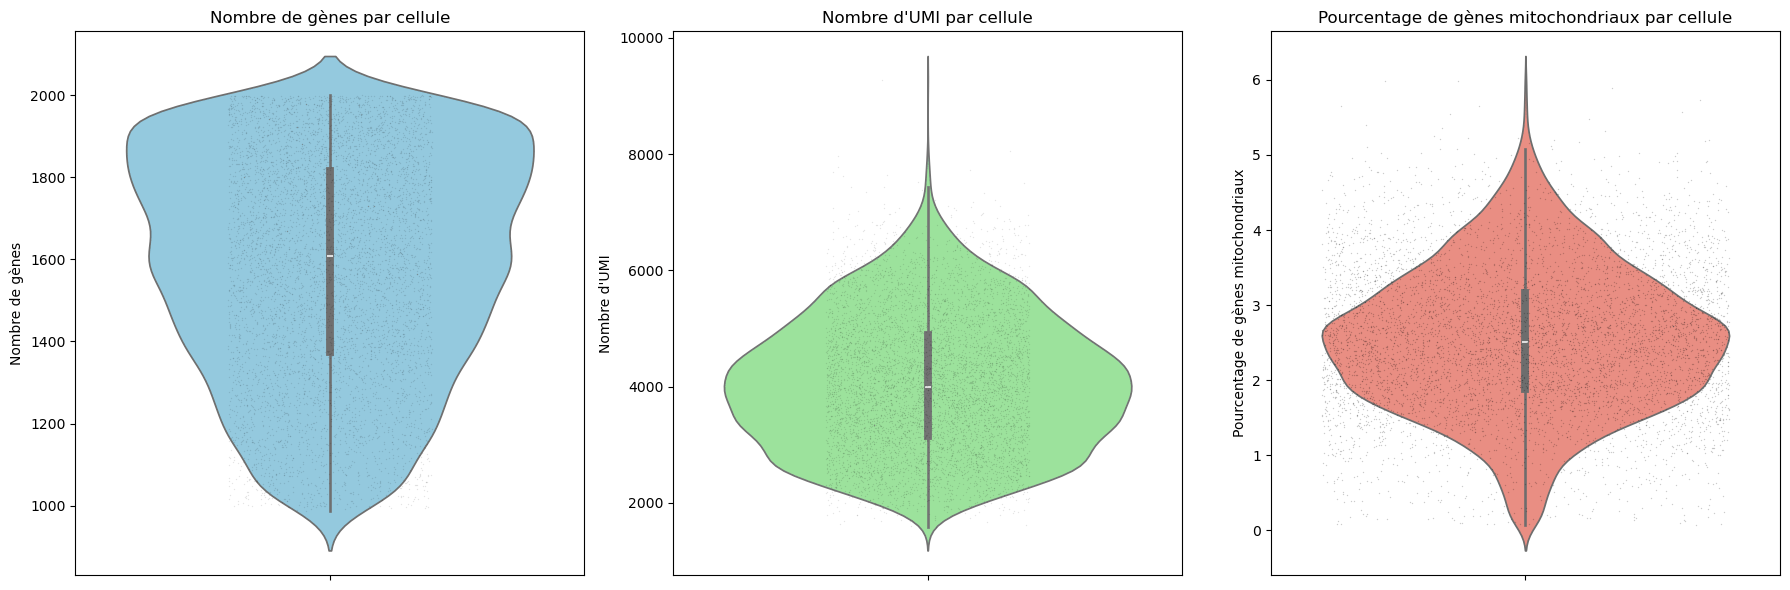


Traitement du tissu : endoderm
Index(['v0_461', 'v0_586', 'v0_634', 'v0_707', 'v0_709', 'v0_1272', 'v0_1524',
       'v0_1597', 'v0_2061', 'v0_2426',
       ...
       'l22_3200', 'l22_3289', 'l22_5572', 'l22_5663', 'l22_7302', 'l22_9568',
       'l22_10624', 'l22_10762', 'l22_11261', 'l22_11458'],
      dtype='object', length=3097)
             v0_461  v0_586  v0_634  v0_707  v0_709  v0_1272  v0_1524  \
MIR1302-2HG       0       0       0       0       0        0        0   
FAM138A           0       0       0       0       0        0        0   
OR4F5             0       0       0       0       0        0        0   
AL627309.1        0       0       0       0       0        0        0   
AL627309.3        0       0       0       0       0        0        0   
...             ...     ...     ...     ...     ...      ...      ...   
AC233755.2        0       0       0       0       0        0        0   
AC233755.1        0       0       0       0       0        0        0   
AC24027

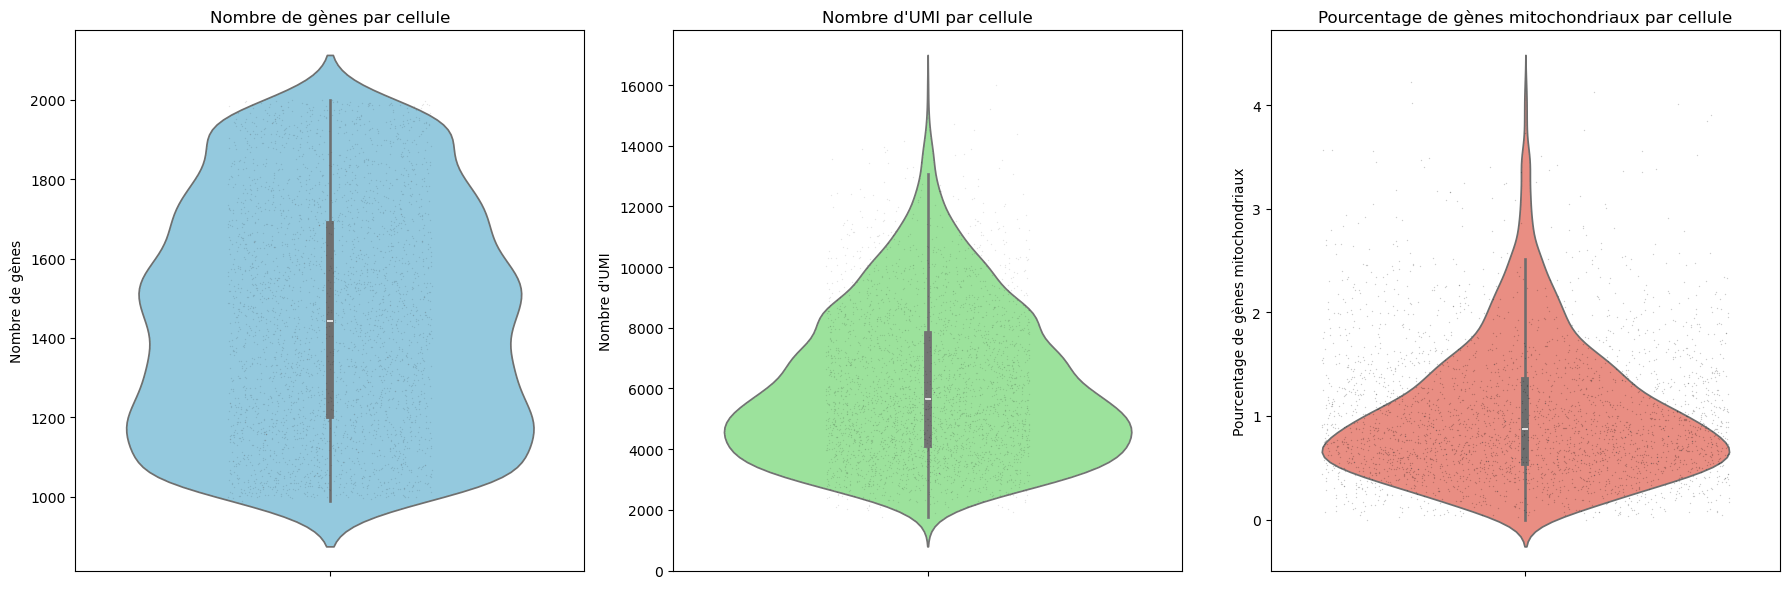


Traitement du tissu : endothelium
Index(['l0_2824', 'l0_5173', 'l0_5217', 'l0_7677', 'l0_11750', 'h9a_926',
       'h9a_964', 'h9a_1337', 'h9a_2191', 'h9a_2791',
       ...
       'l22_5360', 'l22_5580', 'l22_6189', 'l22_7331', 'l22_7680', 'l22_9154',
       'l22_9569', 'l22_9960', 'l22_10351', 'l22_10531'],
      dtype='object', length=2343)
             l0_2824  l0_5173  l0_5217  l0_7677  l0_11750  h9a_926  h9a_964  \
MIR1302-2HG        0        0        0        0         0        0        0   
FAM138A            0        0        0        0         0        0        0   
OR4F5              0        0        0        0         0        0        0   
AL627309.1         0        0        0        0         0        0        0   
AL627309.3         0        0        0        0         0        0        0   
...              ...      ...      ...      ...       ...      ...      ...   
AC233755.2         0        0        0        0         0        0        0   
AC233755.1         0  

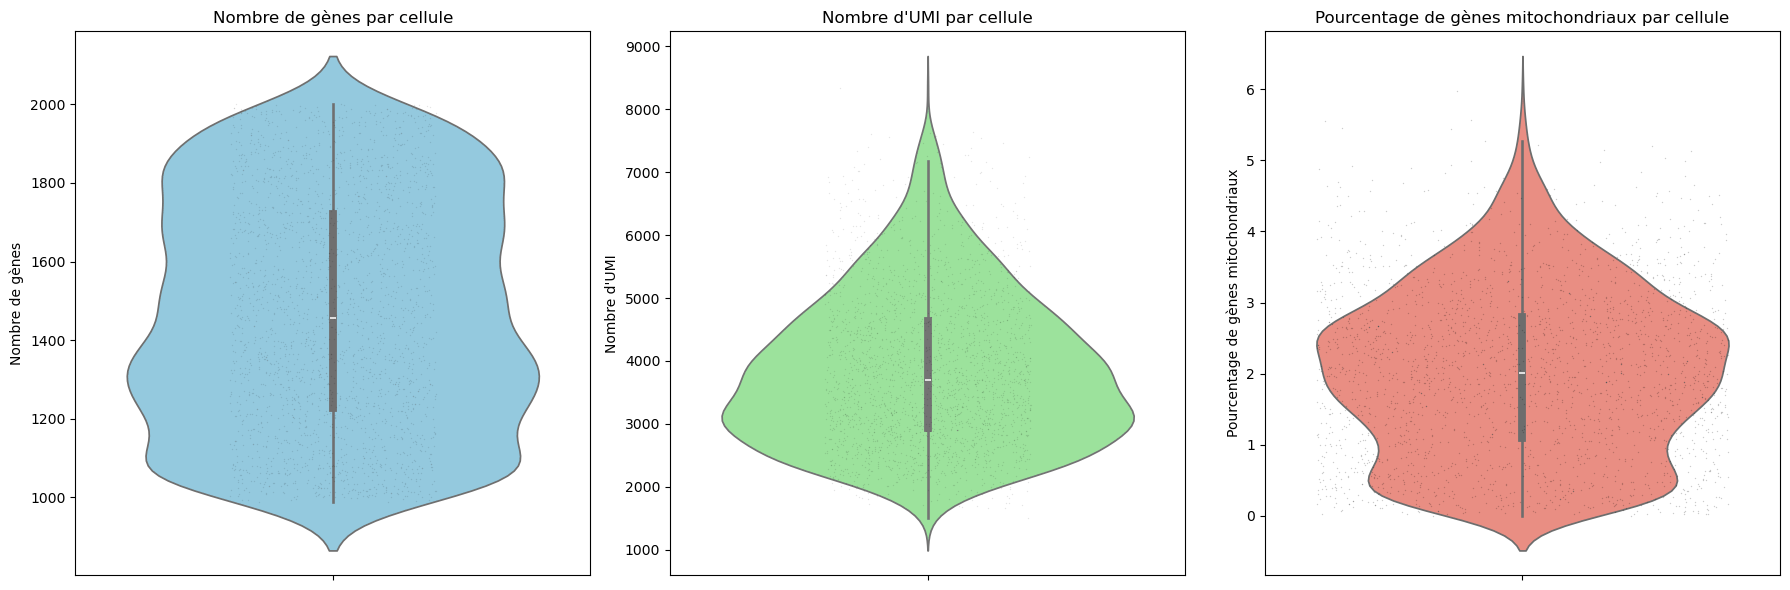


Traitement du tissu : epidermis
Index(['h0_1165', 'h0_2759', 'h0_4260', 'h0_4600', 'h0_4820', 'l0_1158',
       'l0_1431', 'l0_1896', 'l0_3106', 'l0_3350',
       ...
       'l22_10969', 'l22_11012', 'l22_11102', 'l22_11324', 'l22_11406',
       'l22_11529', 'l22_11581', 'l22_11602', 'l22_11642', 'l22_11747'],
      dtype='object', length=1078)
             h0_1165  h0_2759  h0_4260  h0_4600  h0_4820  l0_1158  l0_1431  \
MIR1302-2HG        0        0        0        0        0        0        0   
FAM138A            0        0        0        0        0        0        0   
OR4F5              0        0        0        0        0        0        0   
AL627309.1         0        0        0        0        0        0        0   
AL627309.3         0        0        0        0        0        0        0   
...              ...      ...      ...      ...      ...      ...      ...   
AC233755.2         0        0        0        0        0        0        0   
AC233755.1         0        

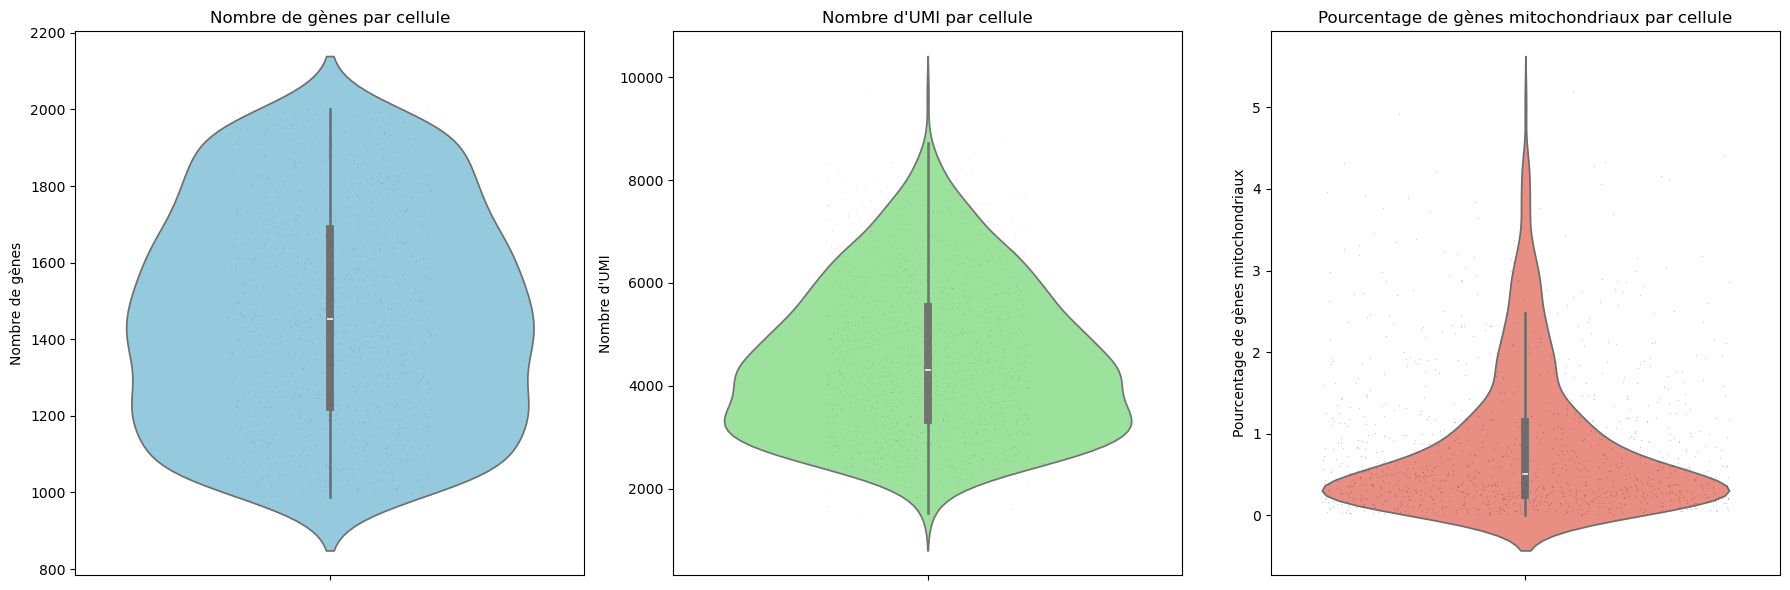


Traitement du tissu : epithelium
Index(['h0_1119', 'h0_1353', 'h0_2955', 'h0_3629', 'h0_3775', 'h0_4863',
       'h0_4919', 'h9a_877', 'h9a_1395', 'h9a_1449',
       ...
       'l21_21955', 'l21_21958', 'l21_22324', 'l21_22563', 'l21_23377',
       'l21_23645', 'l21_23899', 'l21_23902', 'l22_1502', 'l22_3695'],
      dtype='object', length=1094)
             h0_1119  h0_1353  h0_2955  h0_3629  h0_3775  h0_4863  h0_4919  \
MIR1302-2HG        0        0        0        0        0        0        0   
FAM138A            0        0        0        0        0        0        0   
OR4F5              0        0        0        0        0        0        0   
AL627309.1         0        0        0        0        0        0        0   
AL627309.3         0        0        0        0        0        0        0   
...              ...      ...      ...      ...      ...      ...      ...   
AC233755.2         0        0        0        0        0        0        0   
AC233755.1         0       

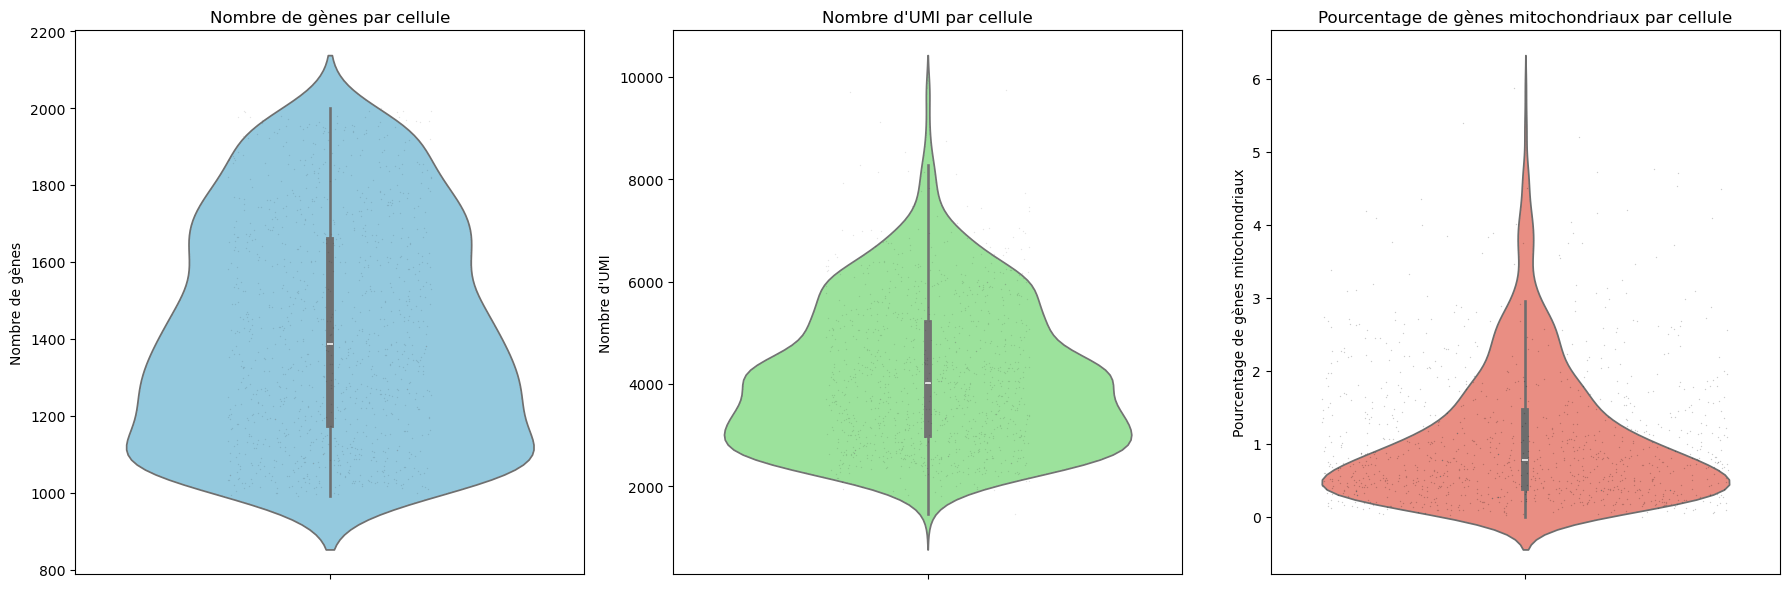


Traitement du tissu : fibroblast
Index(['h0_652', 'l0_1947', 'h9a_641', 'h9b_106', 'h9b_239', 'h9b_2044',
       'h9b_2355', 'h9b_2384', 'h9b_2584', 'h9b_4370',
       ...
       'l21_22597', 'l21_22638', 'l21_22705', 'l21_22979', 'l21_23303',
       'l21_23470', 'l21_23676', 'l22_1550', 'l22_4461', 'l22_8345'],
      dtype='object', length=2056)
             h0_652  l0_1947  h9a_641  h9b_106  h9b_239  h9b_2044  h9b_2355  \
MIR1302-2HG       0        0        0        0        0         0         0   
FAM138A           0        0        0        0        0         0         0   
OR4F5             0        0        0        0        0         0         0   
AL627309.1        0        0        0        0        0         0         0   
AL627309.3        0        0        0        0        0         0         0   
...             ...      ...      ...      ...      ...       ...       ...   
AC233755.2        0        0        0        0        0         0         0   
AC233755.1        

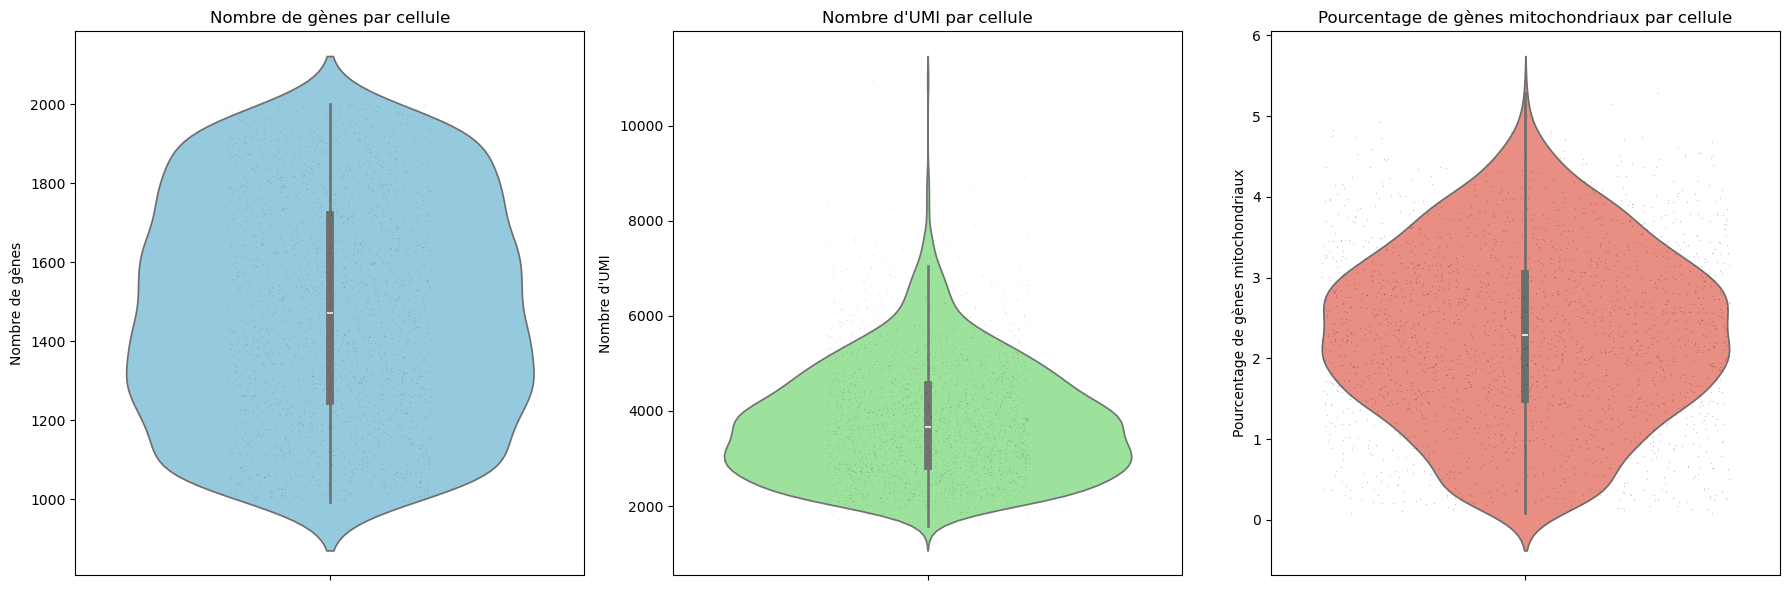


Traitement du tissu : head mesoderm
Index(['h0_499', 'h0_1603', 'h0_2184', 'h0_2653', 'h0_2737', 'h0_3478',
       'h0_4475', 'h0_4601', 'l0_8718', 'h9a_21',
       ...
       'l22_1794', 'l22_1948', 'l22_4745', 'l22_5759', 'l22_7661', 'l22_8802',
       'l22_8946', 'l22_9127', 'l22_10049', 'l22_10748'],
      dtype='object', length=3404)
             h0_499  h0_1603  h0_2184  h0_2653  h0_2737  h0_3478  h0_4475  \
MIR1302-2HG       0        0        0        0        0        0        0   
FAM138A           0        0        0        0        0        0        0   
OR4F5             0        0        0        0        0        0        0   
AL627309.1        0        0        0        0        0        0        0   
AL627309.3        0        0        0        0        0        0        0   
...             ...      ...      ...      ...      ...      ...      ...   
AC233755.2        0        0        0        0        0        0        0   
AC233755.1        0        0        0     

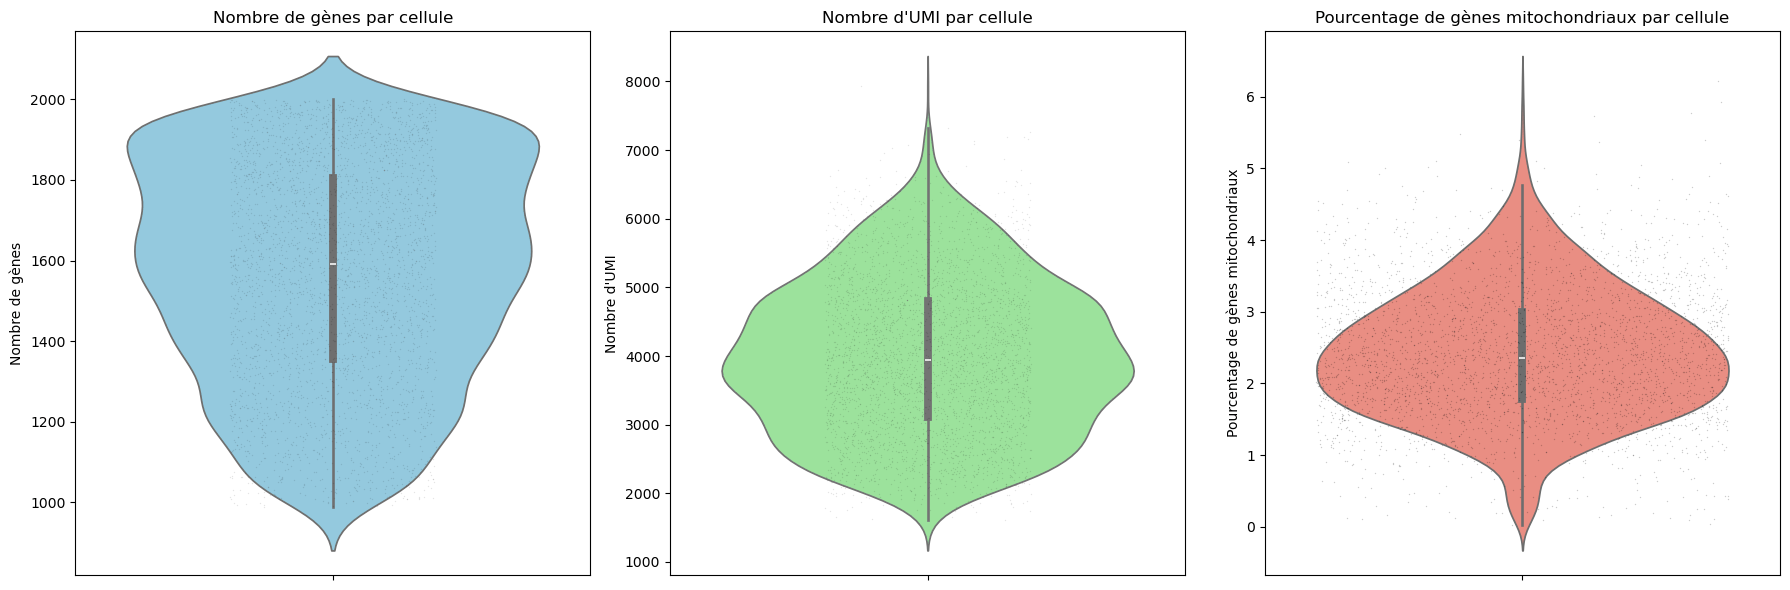


Traitement du tissu : limb
Index(['l0_8', 'l0_85', 'l0_99', 'l0_126', 'l0_175', 'l0_194', 'l0_741',
       'l0_844', 'l0_997', 'l0_1273',
       ...
       'l22_11595', 'l22_11653', 'l22_11655', 'l22_11682', 'l22_11704',
       'l22_11752', 'l22_11756', 'l22_11786', 'l22_11800', 'l22_11866'],
      dtype='object', length=6441)
             l0_8  l0_85  l0_99  l0_126  l0_175  l0_194  l0_741  l0_844  \
MIR1302-2HG     0      0      0       0       0       0       0       0   
FAM138A         0      0      0       0       0       0       0       0   
OR4F5           0      0      0       0       0       0       0       0   
AL627309.1      0      0      0       0       0       0       0       0   
AL627309.3      0      0      0       0       0       0       0       0   
...           ...    ...    ...     ...     ...     ...     ...     ...   
AC233755.2      0      0      0       0       0       0       0       0   
AC233755.1      0      0      0       0       0       0       0       

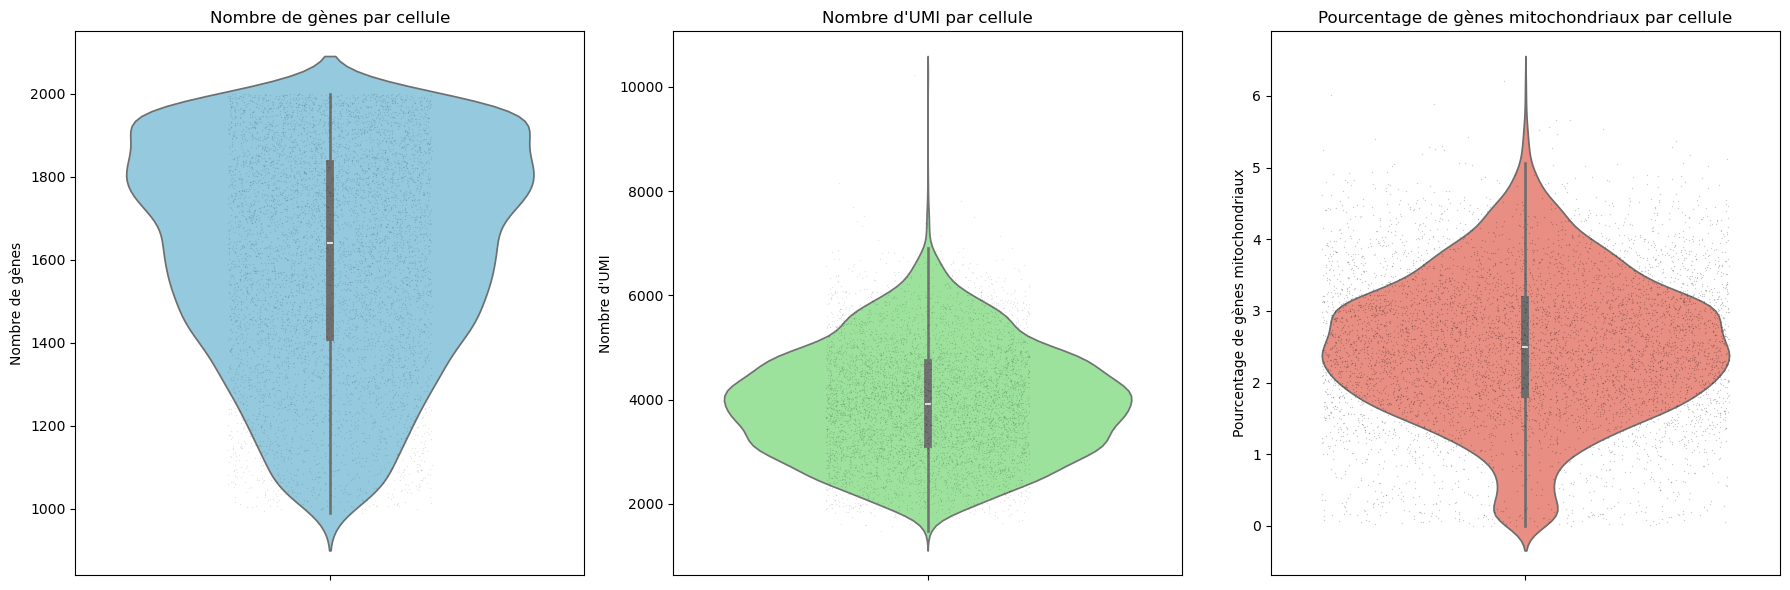


Traitement du tissu : miscellaneous
Index(['h0_271', 'h0_937', 'h0_2487', 'h0_3457', 'l0_4147', 'v0_356',
       'h9a_1022', 'h9a_2290', 'h9a_2525', 'h9a_2599',
       ...
       'l21_23722', 'l21_23853', 'l21_23870', 'l21_23941', 'l21_23942',
       'l21_23954', 'l21_23984', 'l22_7378', 'l22_8726', 'l22_9029'],
      dtype='object', length=2353)
             h0_271  h0_937  h0_2487  h0_3457  l0_4147  v0_356  h9a_1022  \
MIR1302-2HG       0       0        0        0        0       0         0   
FAM138A           0       0        0        0        0       0         0   
OR4F5             0       0        0        0        0       0         0   
AL627309.1        0       0        0        0        0       0         0   
AL627309.3        0       0        0        0        0       0         0   
...             ...     ...      ...      ...      ...     ...       ...   
AC233755.2        0       0        0        0        0       0         0   
AC233755.1        0       0        0      

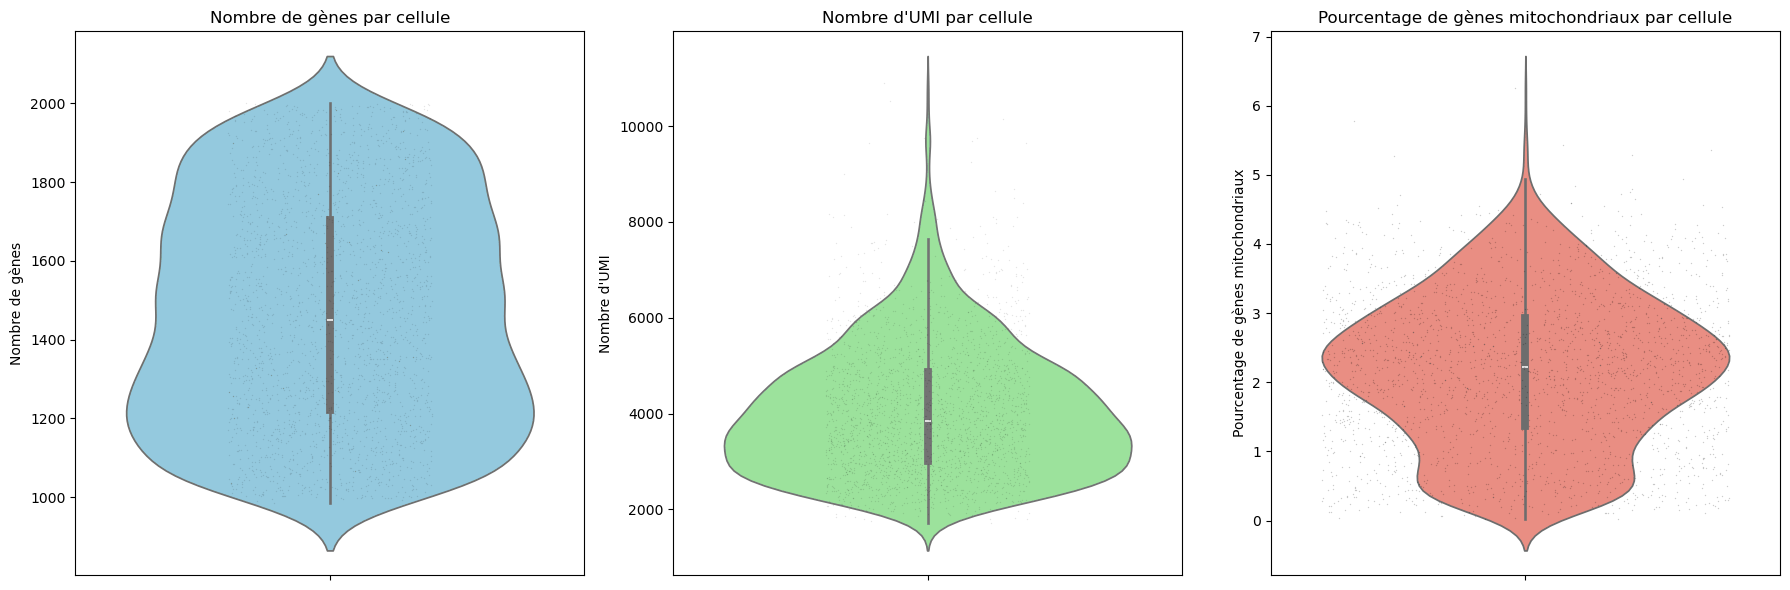


Traitement du tissu : neural progenitor
Index(['h0_48', 'h0_125', 'h0_229', 'h0_480', 'h0_514', 'h0_654', 'h0_721',
       'h0_732', 'h0_900', 'h0_901',
       ...
       'l21_6022', 'l21_10906', 'l21_13277', 'l21_16156', 'l21_16231',
       'l21_17578', 'l21_19942', 'l21_20122', 'l22_2280', 'l22_6587'],
      dtype='object', length=9477)
             h0_48  h0_125  h0_229  h0_480  h0_514  h0_654  h0_721  h0_732  \
MIR1302-2HG      0       0       0       0       0       0       0       0   
FAM138A          0       0       0       0       0       0       0       0   
OR4F5            0       0       0       0       0       0       0       0   
AL627309.1       0       0       0       0       0       0       0       0   
AL627309.3       0       0       0       0       0       0       0       0   
...            ...     ...     ...     ...     ...     ...     ...     ...   
AC233755.2       0       0       0       0       0       0       0       0   
AC233755.1       0       0       0

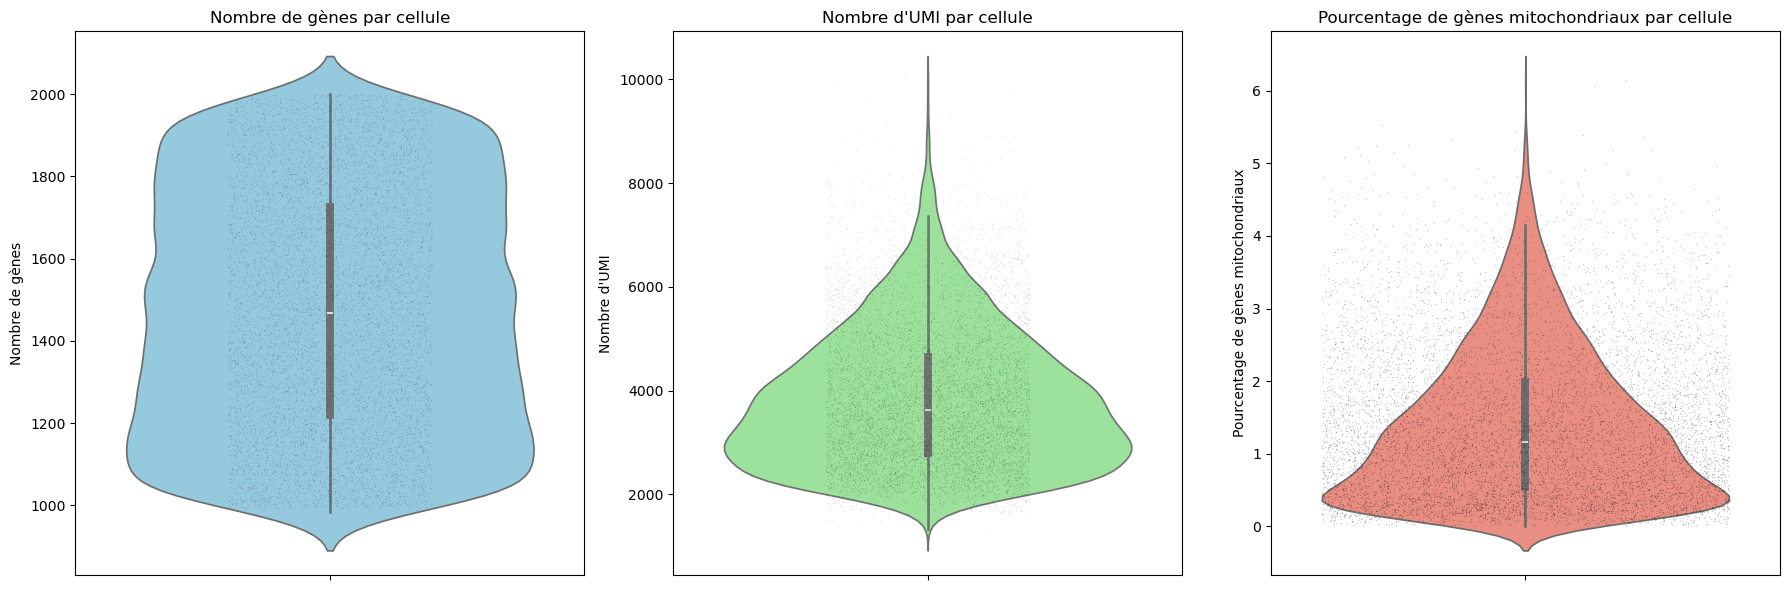


Traitement du tissu : neuron
Index(['h9a_39', 'h9a_362', 'h9a_452', 'h9a_587', 'h9a_837', 'h9a_937',
       'h9a_953', 'h9a_1211', 'h9a_1351', 'h9a_1368',
       ...
       't22_23645', 't22_23649', 't22_23659', 't22_23682', 't22_23684',
       't22_23715', 't22_23727', 't22_23732', 't22_23780', 't22_23854'],
      dtype='object', length=2312)
             h9a_39  h9a_362  h9a_452  h9a_587  h9a_837  h9a_937  h9a_953  \
MIR1302-2HG       0        0        0        0        0        0        0   
FAM138A           0        0        0        0        0        0        0   
OR4F5             0        0        0        0        0        0        0   
AL627309.1        0        0        0        0        0        0        0   
AL627309.3        0        0        0        0        0        0        0   
...             ...      ...      ...      ...      ...      ...      ...   
AC233755.2        0        0        0        0        0        0        0   
AC233755.1        0        0        0

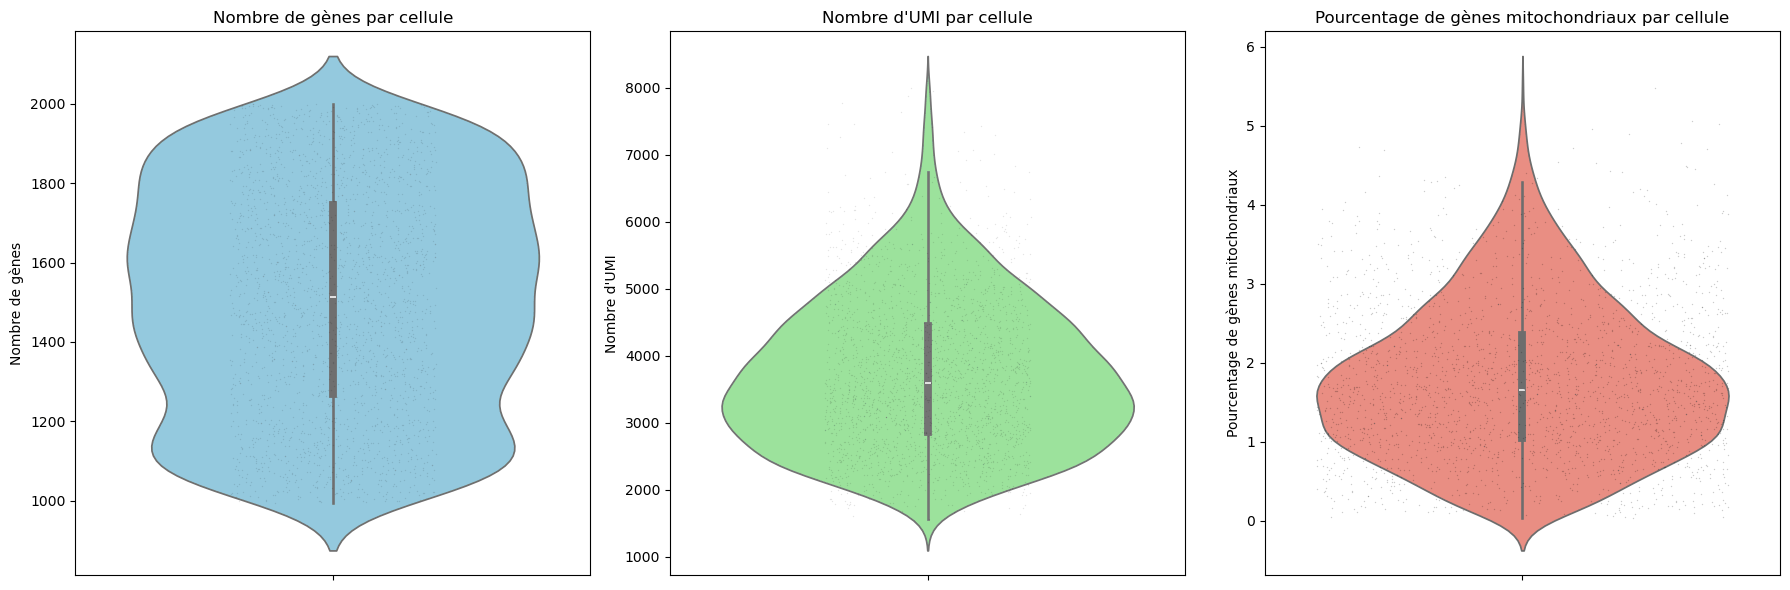


Traitement du tissu : schwann
Index(['h0_1702', 'h9a_790', 'h9a_2551', 'h9a_4129', 'h9b_165', 'h9b_2981',
       'h9b_3311', 'l9_904', 't9_373', 't9_382',
       ...
       'l21_10138', 'l21_10359', 'l21_11270', 'l21_16492', 'l21_16784',
       'l21_19342', 'l21_19715', 'l21_21853', 'l22_8971', 'l22_9134'],
      dtype='object', length=779)
             h0_1702  h9a_790  h9a_2551  h9a_4129  h9b_165  h9b_2981  \
MIR1302-2HG        0        0         0         0        0         0   
FAM138A            0        0         0         0        0         0   
OR4F5              0        0         0         0        0         0   
AL627309.1         0        0         0         0        0         0   
AL627309.3         0        0         0         0        0         0   
...              ...      ...       ...       ...      ...       ...   
AC233755.2         0        0         0         0        0         0   
AC233755.1         0        0         0         0        0         0   
AC240274

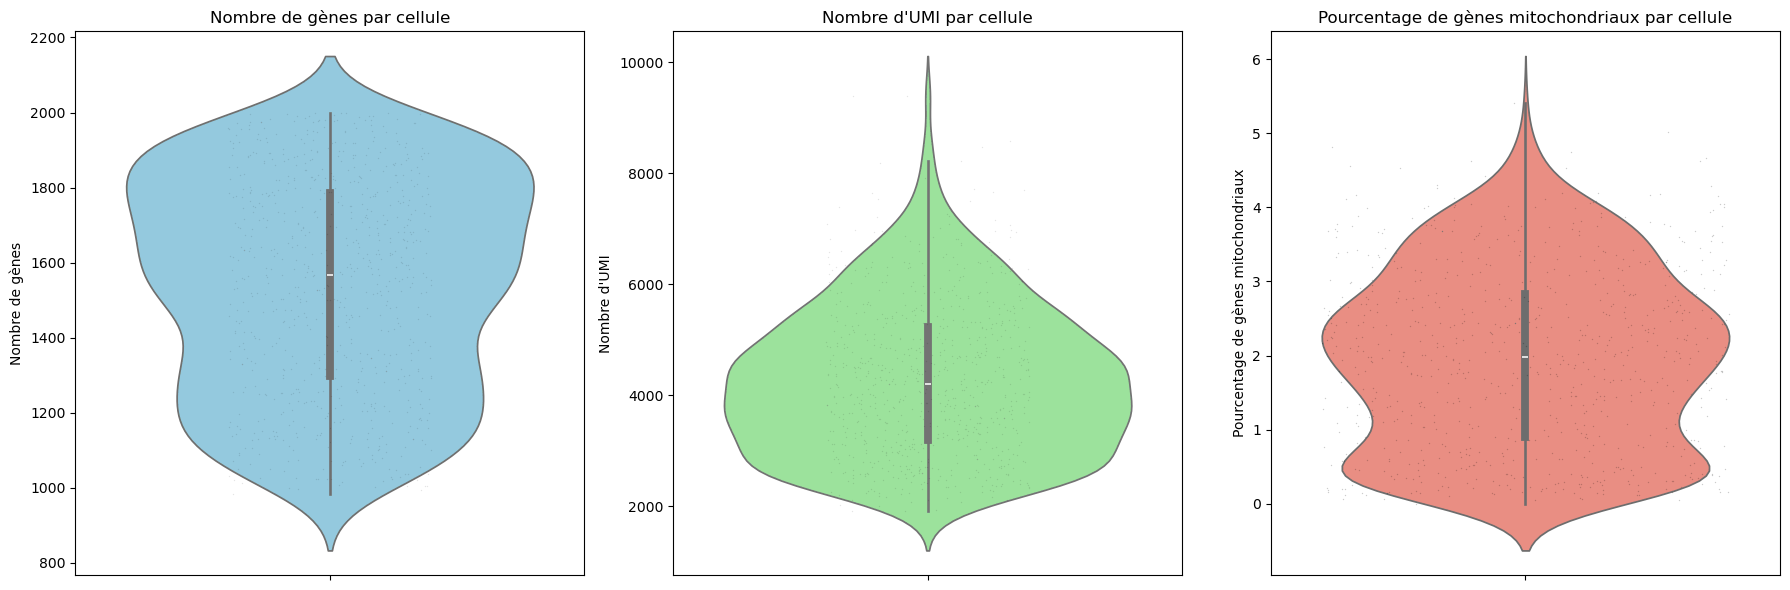


Traitement du tissu : sensory neuron
Index(['h0_4343', 'h9a_2125', 'h9b_176', 'h9b_435', 'h9b_560', 'h9b_750',
       'h9b_934', 'h9b_979', 'h9b_1908', 'h9b_2448',
       ...
       't22_21612', 't22_21676', 't22_21792', 't22_21829', 't22_22218',
       't22_22776', 't22_22782', 't22_23000', 't22_23314', 't22_23512'],
      dtype='object', length=377)
             h0_4343  h9a_2125  h9b_176  h9b_435  h9b_560  h9b_750  h9b_934  \
MIR1302-2HG        0         0        0        0        0        0        0   
FAM138A            0         0        0        0        0        0        0   
OR4F5              0         0        0        0        0        0        0   
AL627309.1         0         0        0        0        0        0        0   
AL627309.3         0         0        0        0        0        0        0   
...              ...       ...      ...      ...      ...      ...      ...   
AC233755.2         0         0        0        0        0        0        0   
AC233755.1   

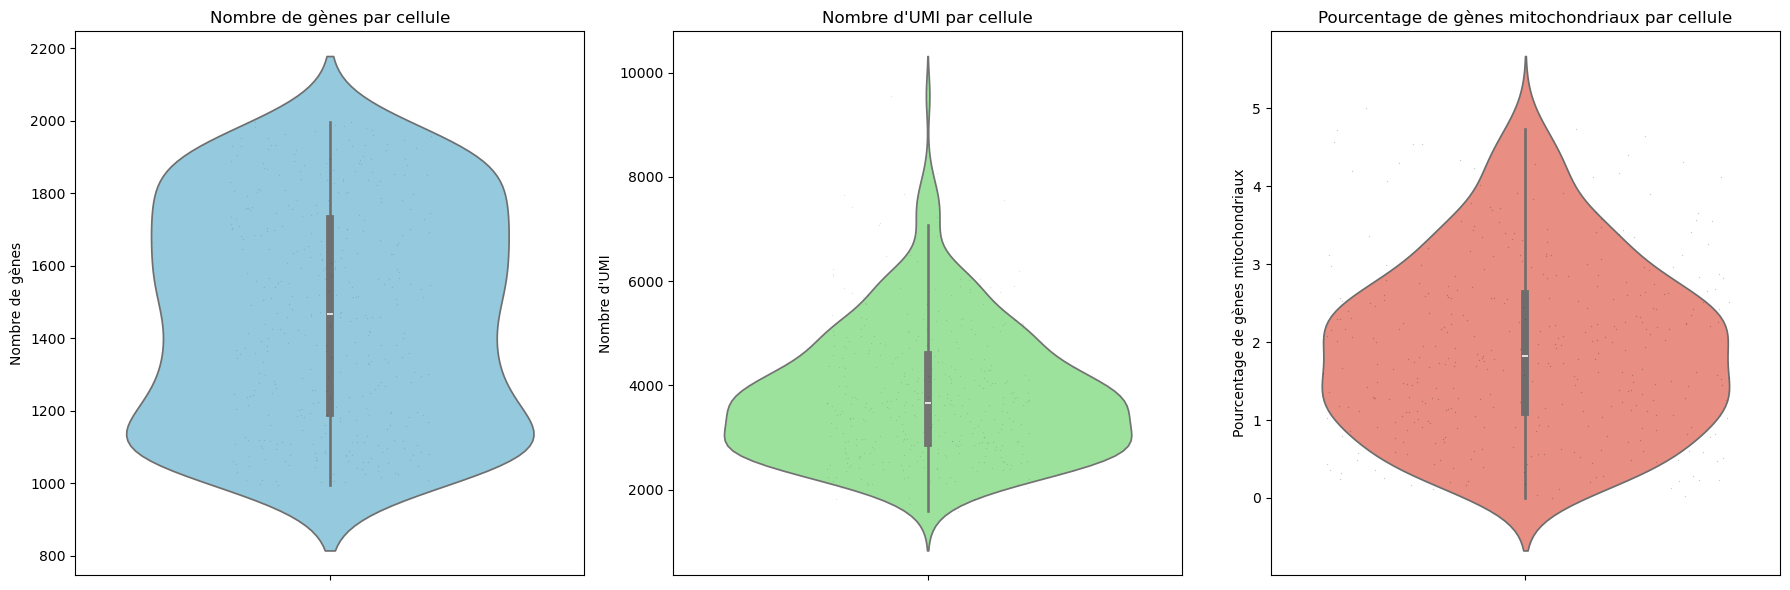


Traitement du tissu : somatic LPM
Index(['l0_6475', 'l0_10005', 'l0_10656', 'l0_10737', 'l0_14970', 'l0_15323',
       'h9b_535', 'l9_88', 't9_90', 't9_1150',
       ...
       'l22_103', 'l22_583', 'l22_1285', 'l22_4847', 'l22_5691', 'l22_7773',
       'l22_9528', 'l22_9548', 'l22_9877', 'l22_10524'],
      dtype='object', length=2681)
             l0_6475  l0_10005  l0_10656  l0_10737  l0_14970  l0_15323  \
MIR1302-2HG        0         0         0         0         0         0   
FAM138A            0         0         0         0         0         0   
OR4F5              0         0         0         0         0         0   
AL627309.1         0         0         0         0         0         0   
AL627309.3         0         0         0         0         0         0   
...              ...       ...       ...       ...       ...       ...   
AC233755.2         0         0         0         0         0         0   
AC233755.1         0         0         0         0         0        

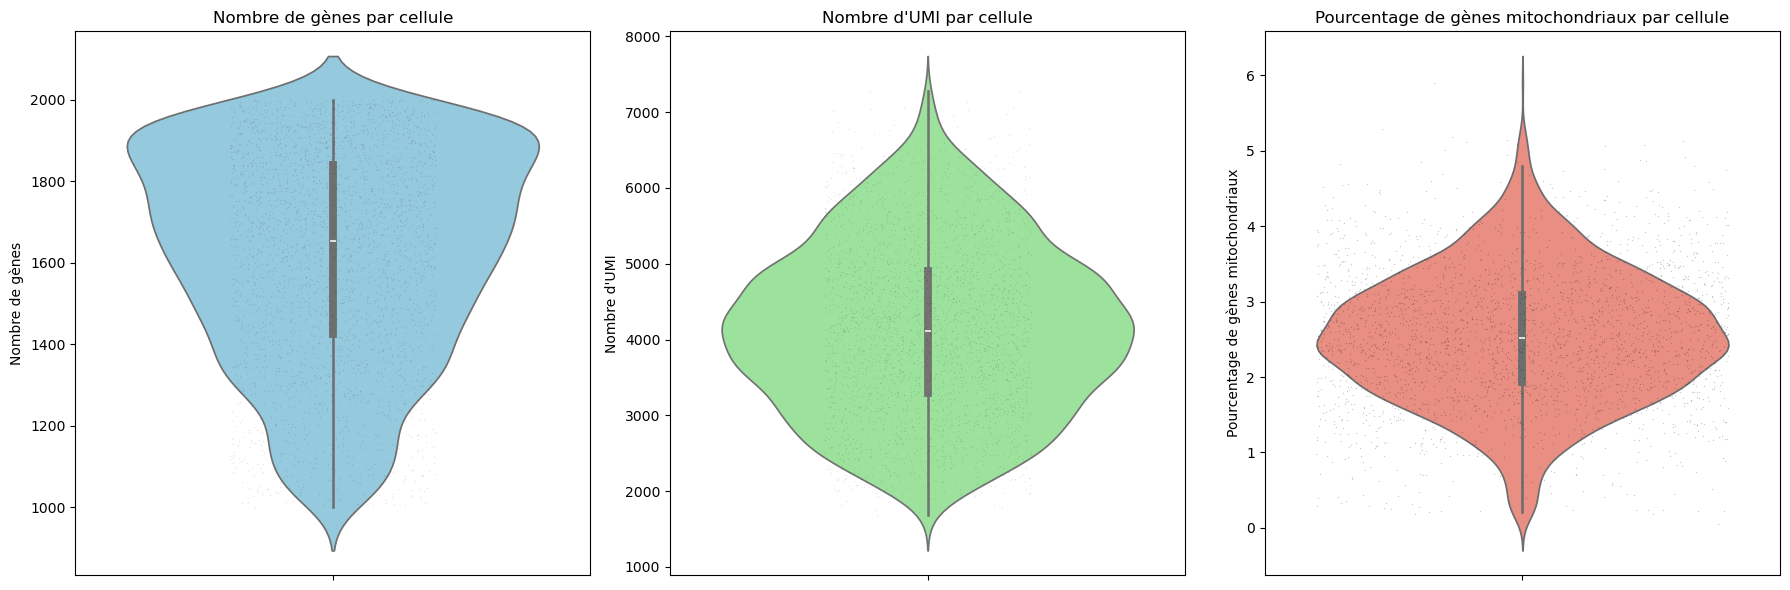


Traitement du tissu : somite
Index(['h0_1878', 'h0_2669', 'l0_360', 'l0_426', 'l0_457', 'l0_1897',
       'l0_2353', 'l0_3068', 'l0_4124', 'l0_4188',
       ...
       'l22_9580', 'l22_9666', 'l22_9923', 'l22_10027', 'l22_10156',
       'l22_11118', 'l22_11200', 'l22_11248', 'l22_11423', 'l22_11503'],
      dtype='object', length=13051)
             h0_1878  h0_2669  l0_360  l0_426  l0_457  l0_1897  l0_2353  \
MIR1302-2HG        0        0       0       0       0        0        0   
FAM138A            0        0       0       0       0        0        0   
OR4F5              0        0       0       0       0        0        0   
AL627309.1         0        0       0       0       0        0        0   
AL627309.3         0        0       0       0       0        0        0   
...              ...      ...     ...     ...     ...      ...      ...   
AC233755.2         0        0       0       0       0        0        0   
AC233755.1         0        0       0       0       0       

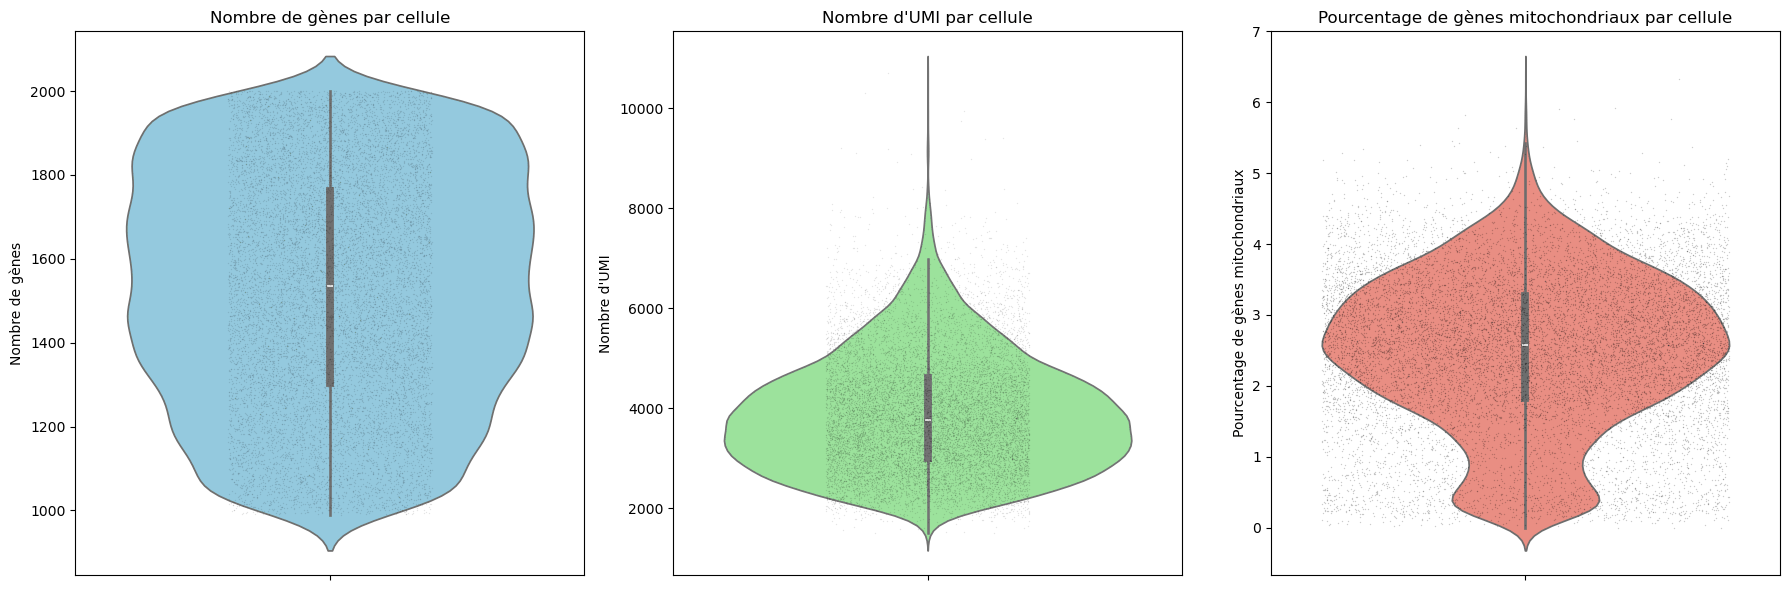


Traitement du tissu : splanchnic LPM
Index(['h0_372', 'v0_1719', 'v0_4270', 'v0_4863', 'h9a_2147', 'h9a_2316',
       'h9a_3643', 'h9a_4037', 'h9b_948', 'h9b_2029',
       ...
       'l21_21003', 'l21_21438', 'l21_21757', 'l21_21810', 'l21_22769',
       'l21_22868', 'l21_23427', 'l22_3207', 'l22_10203', 'l22_11311'],
      dtype='object', length=5876)
             h0_372  v0_1719  v0_4270  v0_4863  h9a_2147  h9a_2316  h9a_3643  \
MIR1302-2HG       0        0        0        0         0         0         0   
FAM138A           0        0        0        0         0         0         0   
OR4F5             0        0        0        0         0         0         0   
AL627309.1        0        0        0        0         0         0         0   
AL627309.3        0        0        0        0         0         0         0   
...             ...      ...      ...      ...       ...       ...       ...   
AC233755.2        0        0        0        0         0         0         0   
AC23

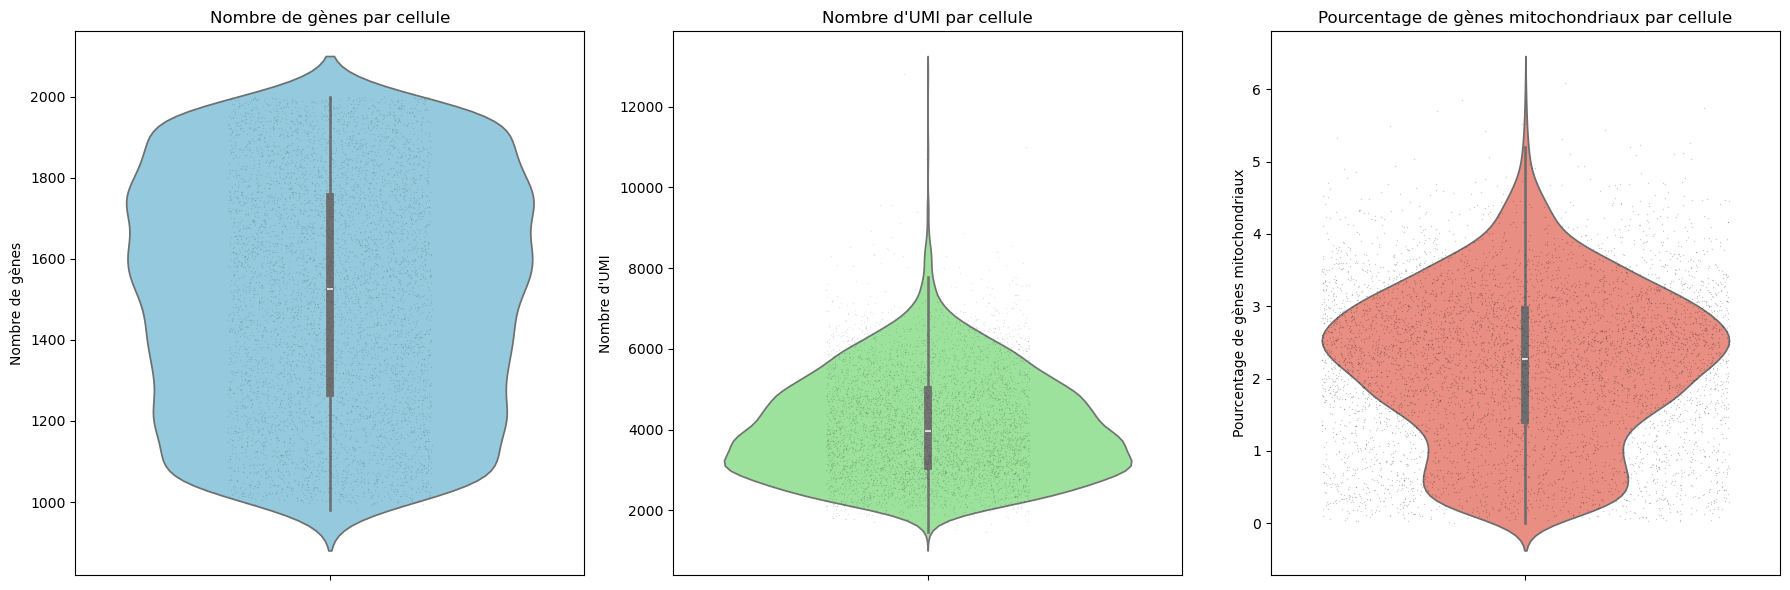

In [28]:
for tissu in tissus_unique:
    print(f"\nTraitement du tissu : {tissu}")
    
    # Récupérer les cellules correspondant à ce tissu
    cellules_du_tissu = df_tissus_filtered[df_tissus_filtered == tissu].index
    print(cellules_du_tissu)
    
    # Sous-ensemble du DataFrame d'expression pour ces cellules 
    df_expr = pd.DataFrame()
    for cellule in cellules_du_tissu:
        if cellule in df3_tissus_filtered.columns:  # Vérifie que la cellule existe bien dans df3_tissus_filtered
            df_expr[cellule] = df3_tissus_filtered[cellule]
    
    # Vérifier si df_expr est vide après avoir ajouté toutes les cellules
    if df_expr.shape[1] == 0:
        print(f"Aucune cellule pour le tissu {tissu}, on saute.")
        continue  # Passe à l'itération suivante pour ce tissu
    
    print(df_expr)
    
    # Appliquer la fonction de contrôle qualité
    QC_violin(df_expr, genes=df3_tissus_filtered.index)


#### Normalisation 

In [30]:
df3_tissus_normalized = normalize(df3_tissus_filtered)

#### ACP

In [41]:
pca_result3_tissu =  apply_PCA(df3_tissus_normalized, n_components=20)

On applique la log transformation...
Log transformation complète.
Début de l'ACP
PCA complète, dimension = (65063, 20)


#### UMAP 

In [44]:
print( pca_result3_tissu.shape)

(65063, 20)


In [51]:
umap3_tissu = apply_umap(pca_result3_tissu, n_neighbors=15, min_dist=0.4)


UMAP done: (65063, 2)


### On represente la UMAP avec les cellules colorés en fonction des tissus 

In [53]:
df_tissu_filt = pd.DataFrame(df_tissus_filtered,columns = ['Tissu']) 
umap3_tissu = pd.DataFrame(umap3_tissu, columns=['UMAP1', 'UMAP2'])
print (df_tissu_filt.shape)
print (df_tissu_filt.head())
print (umap3_tissu.head())

umap3_tissu.index = df_tissus_filtered.index

# Vérifier si l'index a été correctement assigné
print(umap3_tissu.head())
print(umap3_tissu.shape)

(65063, 1)
                    Tissu
h0_48   neural progenitor
h0_125  neural progenitor
h0_229  neural progenitor
h0_271      miscellaneous
h0_372     splanchnic LPM
       UMAP1     UMAP2
0  10.727701  6.397434
1   9.479974  6.199726
2   8.658034  4.889030
3   9.819472  6.429537
4   8.985170  5.312925
            UMAP1     UMAP2
h0_48   10.727701  6.397434
h0_125   9.479974  6.199726
h0_229   8.658034  4.889030
h0_271   9.819472  6.429537
h0_372   8.985170  5.312925
(65063, 2)


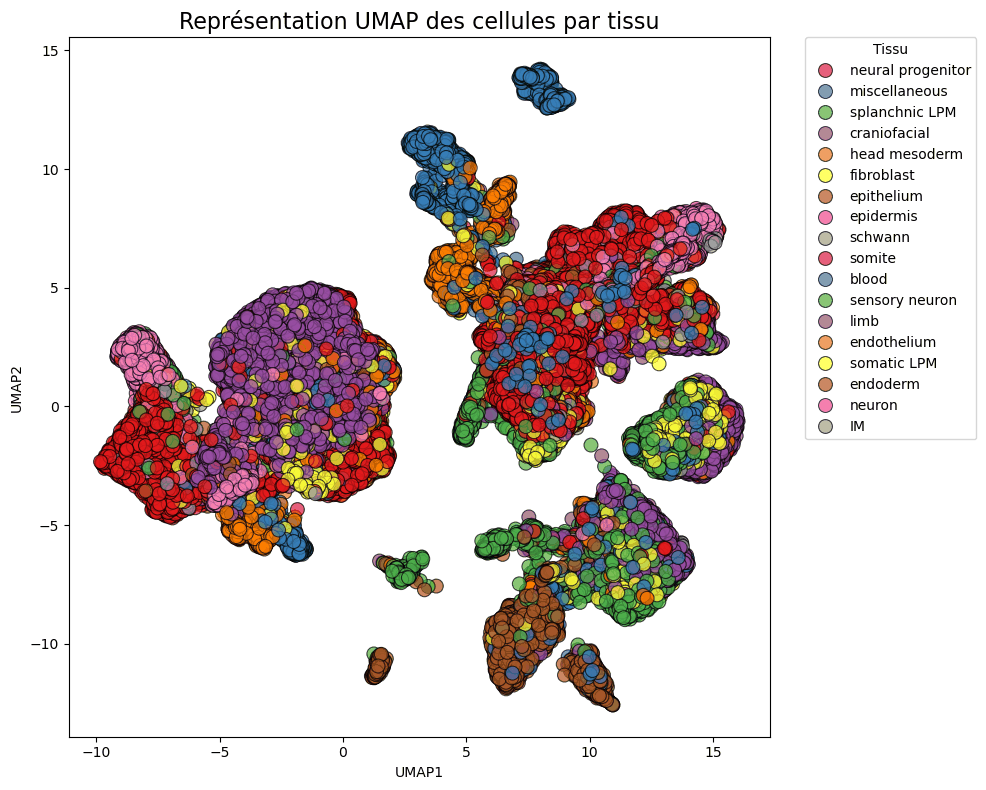

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Supposons que df_umap contient les résultats UMAP avec les coordonnées pour chaque cellule
# et df_tissus contient le tissu de chaque cellule avec l'index correspondant
umap3_tissu = pd.DataFrame(umap3_tissu, columns=['UMAP1', 'UMAP2'])
# Ajouter l'information sur les tissus à df_umap
umap3_tissu['tissu'] = umap3_tissu.index.map(df_tissu_filt['Tissu'])  # Assure-toi que l'index de df_umap correspond aux cellules dans df_tissus

# Visualisation de l'UMAP avec un codage couleur selon le tissu
plt.figure(figsize=(10, 8))
sns.scatterplot(data=umap3_tissu, x='UMAP1', y='UMAP2', hue='tissu', palette='Set1', s=100, edgecolor='black', alpha=0.7)

# Personnaliser la légende et le titre
plt.title("Représentation UMAP des cellules par tissu", fontsize=16)
plt.legend(title='Tissu', loc='best', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')

# Afficher
plt.tight_layout()
plt.show()
# points trop gros et code couleur a modifie 

#### Première visualisation des Violins plots

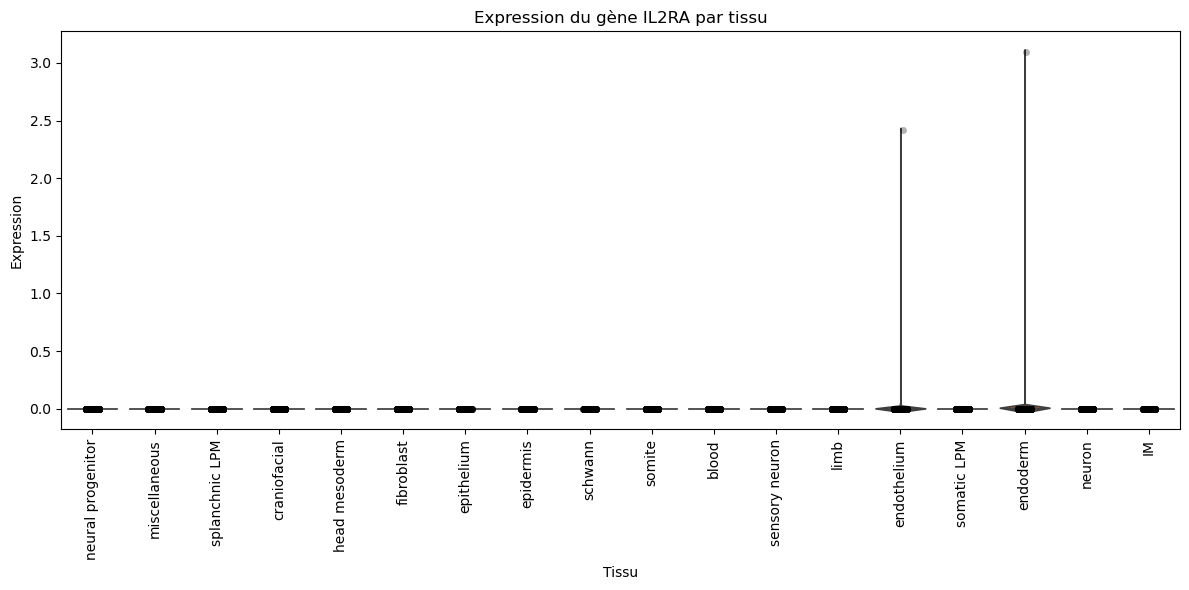

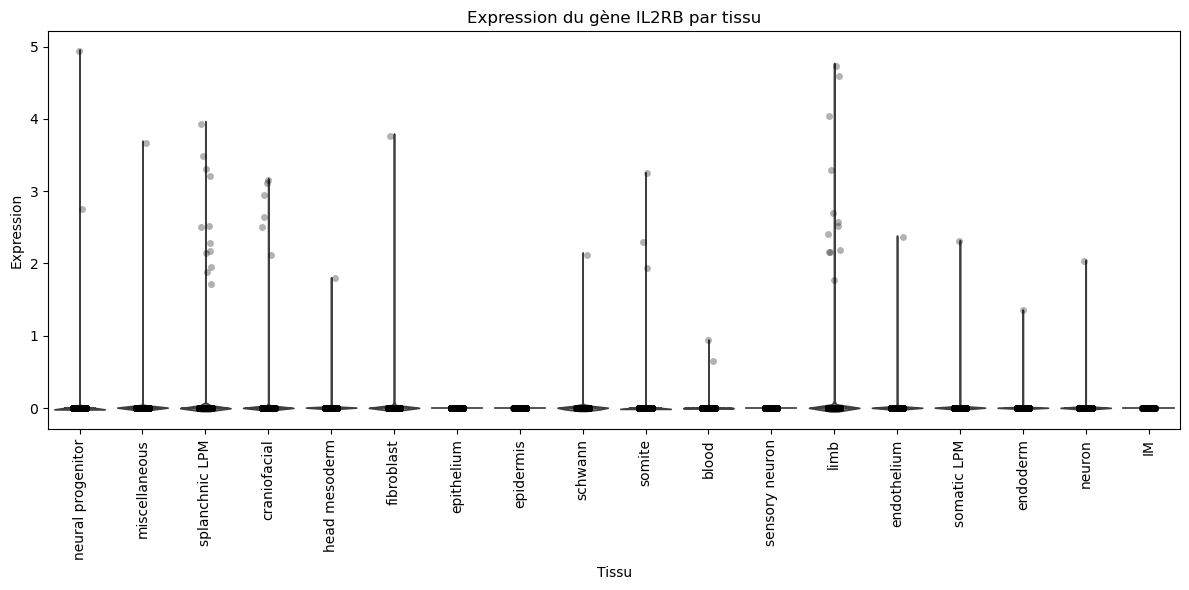

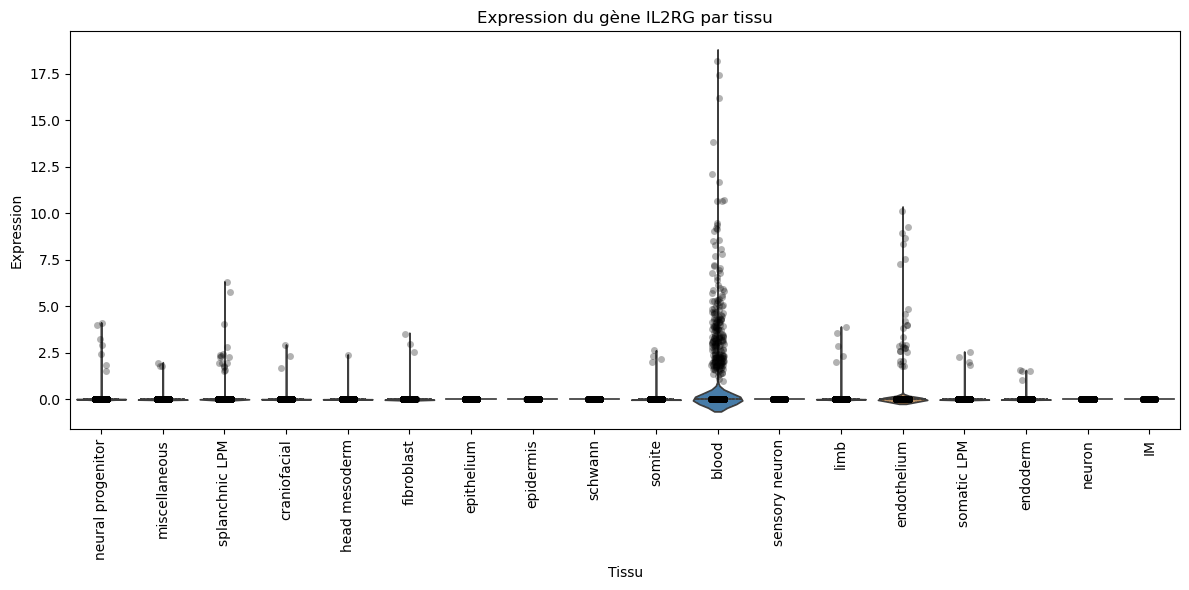

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Liste des gènes d'intérêt
genes_of_interest = ['IL2RA', 'IL2RB', 'IL2RG']

# Boucle pour chaque gène
for gene in genes_of_interest:
    plt.figure(figsize=(12, 6))
    
    try:
        # Extraire l'expression du gène
        gene_expression = df3_tissus_normalized.loc[gene]

        # Créer un DataFrame fusionné
        gene_expression_df = pd.DataFrame({
            'Expression': gene_expression,
            'Tissu': df_tissus_filtered
        })

        # Tracer le violin plot
        sns.violinplot(data=gene_expression_df, x='Tissu', y='Expression', palette='Set1', inner="quart")

        # Ajouter un stripplot par-dessus (pour visualiser les points)
        sns.stripplot(data=gene_expression_df, x='Tissu', y='Expression', color='black', alpha=0.3, jitter=True)

        # Ajouter un titre
        plt.title(f"Expression du gène {gene} par tissu")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

    except KeyError:
        print(f"Le gène {gene} n'a pas été trouvé dans les données.")



### On effectue les tests statistiques 

### T-test 

In [69]:
p_values_df_t_test = t_test_gene_expression_with_pvalues(df3_tissus_normalized, df_tissus_filtered, genes_of_interest)
print(p_values_df_t_test)

Gène                  IL2RA         IL2RB         IL2RG
Cluster                                                
IM                 0.160450  2.250903e-10  3.051396e-45
blood              0.160450  6.652729e-02  5.920496e-34
craniofacial       0.160450  4.239971e-01  2.680324e-32
endoderm           0.336993  5.998747e-03  3.432907e-24
endothelium        0.341684  4.206122e-01  1.345199e-03
epidermis          0.160450  2.250734e-10  3.045524e-45
epithelium         0.160450  2.250731e-10  3.045407e-45
fibroblast         0.160450  9.988156e-01  5.340222e-06
head mesoderm      0.160450  2.429736e-02  2.841479e-32
limb               0.160450  1.635883e-02  4.955481e-22
miscellaneous      0.160450  8.600878e-01  1.937051e-16
neural progenitor  0.160450  7.949795e-02  2.079866e-26
neuron             0.160450  2.893173e-01  3.036332e-45
schwann            0.160450  7.424839e-01  3.047702e-45
sensory neuron     0.160450  2.250880e-10  3.050601e-45
somatic LPM        0.160450  2.676438e-01  3.555

### Mann-Whitney

In [72]:
p_values_df_mann_whitney = mann_whitney_gene_expression(df3_tissus_normalized, df_tissus_filtered, genes_of_interest)
print(p_values_df_mann_whitney)

Gène                  IL2RA     IL2RB         IL2RG
Cluster                                            
IM                 0.927937  0.667259  2.733413e-01
blood              0.794434  0.663126  0.000000e+00
craniofacial       0.645073  0.393762  6.642957e-07
endoderm           0.002657  0.423570  6.468288e-03
endothelium        0.000429  0.619425  3.182217e-08
epidermis          0.854422  0.383758  2.647745e-02
epithelium         0.853339  0.380192  2.536330e-02
fibroblast         0.798410  0.719385  3.744668e-02
head mesoderm      0.739709  0.364227  1.743370e-04
limb               0.639256  0.000165  2.814153e-06
miscellaneous      0.784173  0.616561  1.774804e-02
neural progenitor  0.559279  0.054233  3.761615e-09
neuron             0.786084  0.629194  1.031856e-03
schwann            0.876363  0.527502  5.982964e-02
sensory neuron     0.914137  0.608467  1.918252e-01
somatic LPM        0.769425  0.521544  1.805276e-02
somite             0.478704  0.024812  1.482932e-15
splanchnic L

## Visualisation des violin plots avec étoiles 

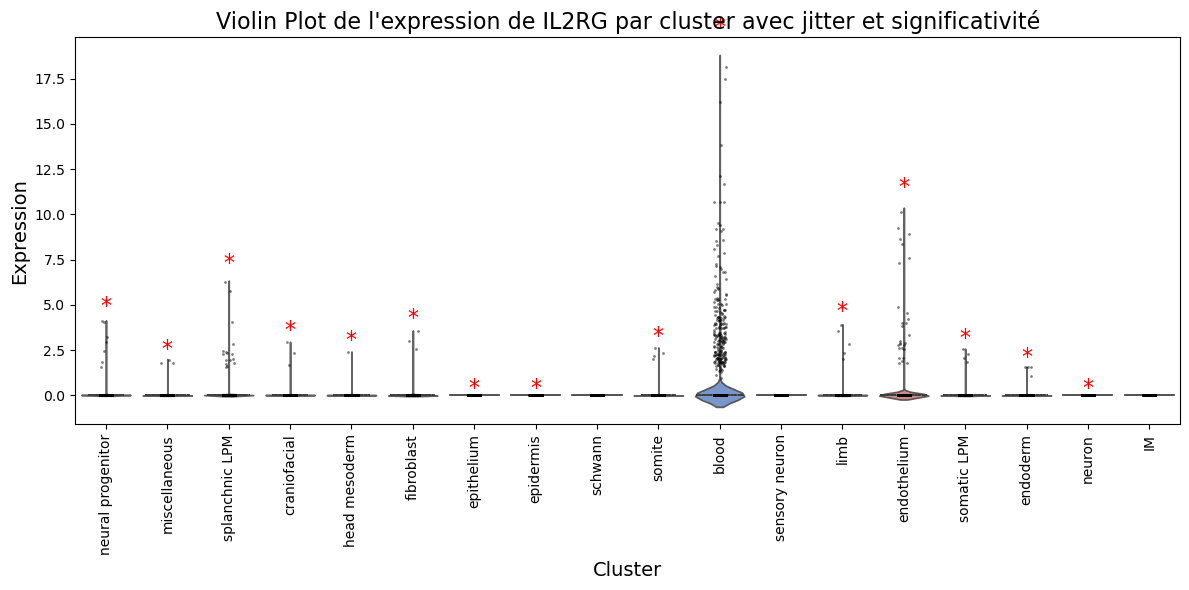

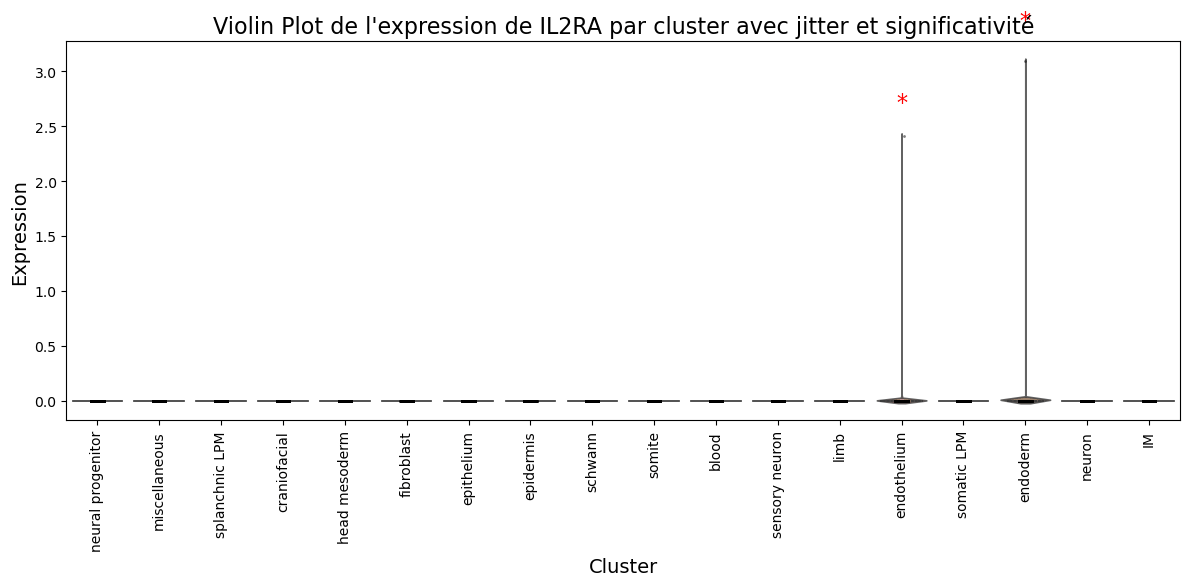

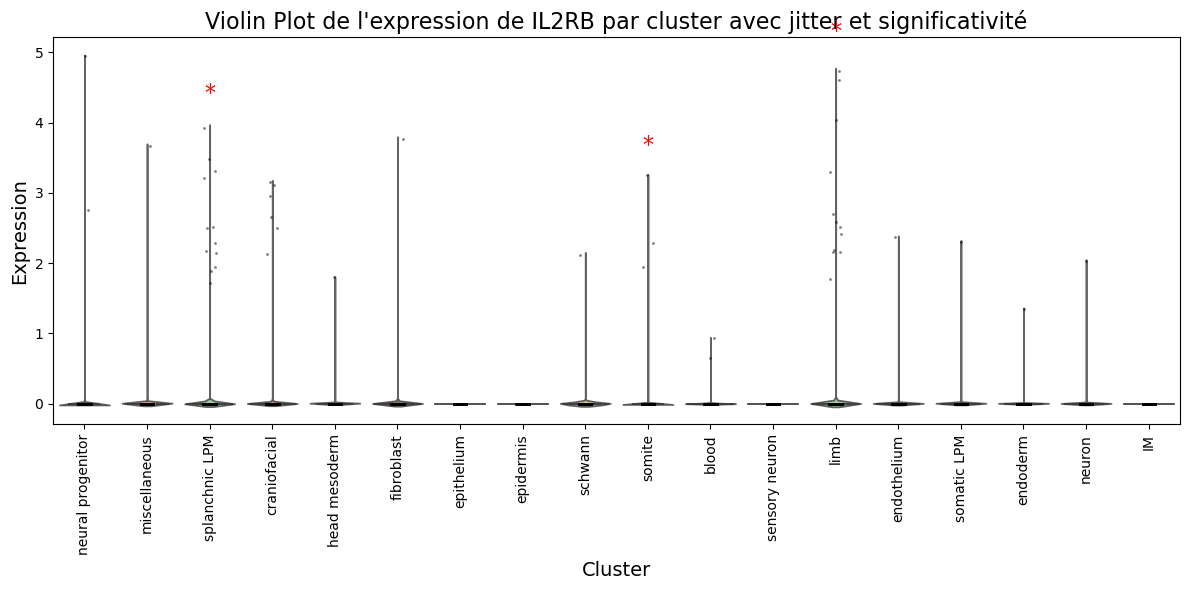

In [82]:
plot_violin_with_significance(df3_tissus_normalized, genes_of_interest, df_tissus_filtered, p_values_df_mann_whitney, threshold=0.05)